# Explore Classification Results

Interactive notebook for inspecting and comparing classifier training runs.
Mirrors `05.plot_classifier_results.py` but designed for cell-by-cell exploration with immediate plot feedback.

**Sections**
1. Setup & configuration
2. Single-run analysis (summary, training curves, metric distributions, confusion matrix)
3. Classification results tables (per-run LaTeX tables, marginal statistics)
4. Comparative ROC curves across multiple runs
5. Grouped accuracy bar chart
6. Stacking results
7. Confusion matrices — beam_crop comparison
8. Learning curve
9. Noise robustness sweep

## 1. Setup
Run this cell first. It imports all libraries, adds the project `src/` to the path, loads project utilities, and sets the output directory for saved figures.

In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import os, re, pickle, itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import sys
sys.path.insert(0, '/users/mbredber/p2_DCRECLASS/src')

from dcreclass.utils.calc_tools import (
    recalculate_metrics_with_correct_positive_class, round_to_1
)
from dcreclass.utils.plotting import (
    plot_training_history, plot_avg_std_confusion_matrix
)
import glob as _glob
import json as _json
import warnings as _warnings_md
from matplotlib.patches import Patch as _Patch
import matplotlib.lines as _mlines
import seaborn as _sns
from sklearn.metrics import confusion_matrix as _confusion_matrix
from matplotlib.colors import LinearSegmentedColormap as _LSC
from dcreclass.data import get_classes as _get_classes
import re as _re11
import seaborn as _sns11
from sklearn.metrics import confusion_matrix as _cm11
from matplotlib.colors import LinearSegmentedColormap as _LSC11
from matplotlib.lines import Line2D as _Line2D11
from matplotlib.ticker import FixedLocator as _FL11
from dcreclass.data import get_classes as _get_classes11
import warnings as _warnings
import dataclasses
import io
import re
import contextlib
from typing import Optional, List, Tuple
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory
import matplotlib.colors as _mcolors
import re as _re
import io as _io, contextlib as _ctx
from collections import defaultdict as _dd

plt.rcParams.update({'font.size': 9})

OUTPUT_DIR = '/users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Imports OK')
print('Output dir:', OUTPUT_DIR)

Imports OK
Output dir: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs


### Data structures and loaders
`RunConfig` and `LegacyRunConfig` are the two dataclasses that identify a training run.
`load_run` loads all pkl result files that match a given config.

In [2]:
@dataclass
class RunConfig:
    """All parameters that identify one training run.
    Defaults match script 04.
    """
    classifier:      str   = 'ImageCNN'
    version:         str   = 'RAW'          # e.g. RAW, T25kpc, T50kpc, T100kpc
    crop_mode:       str   = 'beam_crop'    # beam_crop | beam_crop_no_sub | fov_crop | cheat_crop | pixel_crop
    blur_method:     str   = 'circular'     # circular | circular_no_sub | cheat
    lr:              float = 5e-5
    reg:             float = 1e-1
    label_smoothing: float = 0.1
    percentile_lo:   int   = 30
    percentile_hi:   int   = 99
    noise_level:     float = 0.0
    folds:           List[int] = field(default_factory=lambda: [0])
    num_experiments: int   = 2
    galaxy_classes:  List[int] = field(default_factory=lambda: [50, 51])
    crop_size:       Tuple[int, int] = (512, 512)
    downsample_size: Tuple[int, int] = (128, 128)
    global_norm_mode: str  = 'percentile'
    adjust_positive_class: bool = True
    data_run_dir:    str   = '/users/mbredber/p2_DCRECLASS/outputs/scratch'
    # When multiple old-format files match, use this index to pick one (0 = first/alphabetically first)
    preferred_old_idx: int = 0

    @property
    def metrics_dir(self) -> str:
        sub = (f"{self.classifier}_{self.crop_mode}_{self.blur_method}_"
               f"{self.lr}_{self.reg}_{self.percentile_lo}_"
               f"{self.percentile_hi}_{self.label_smoothing}")
        return os.path.join(self.data_run_dir, 'data', 'metrics', sub)

    @property
    def old_metrics_dir(self) -> str:
        return os.path.join(self.data_run_dir, 'data', 'metrics', 'old')

    @property
    def dataset_sizes(self) -> Dict[int, List[int]]:
        if self.galaxy_classes == [50, 51]:
            return {fold: [3000] for fold in range(10)}
        if self.galaxy_classes == [52, 53]:
            return {fold: [2, 16, 168] for fold in range(10)}
        raise ValueError(f'No dataset_sizes defined for galaxy_classes={self.galaxy_classes}')

    def base_key(self, fold: int, subset_size: int) -> str:
        """Canonical key — mirrors script 04's _base() (includes _nl token)."""
        return (f"{self.classifier}_ver{self.version}_cm{self.crop_mode}"
                f"_lr{self.lr}_reg{self.reg}_ls{self.label_smoothing}"
                f"_lo{self.percentile_lo}_hi{self.percentile_hi}"
                f"_nl{self.noise_level}"
                f"_f{fold}_ss{round_to_1(subset_size)}")

    def _base_key_no_nl(self, fold: int, subset_size: int) -> str:
        """Pre-noise-level key format — matches pkl files generated before _nl was added."""
        return (f"{self.classifier}_ver{self.version}_cm{self.crop_mode}"
                f"_lr{self.lr}_reg{self.reg}_ls{self.label_smoothing}"
                f"_lo{self.percentile_lo}_hi{self.percentile_hi}"
                f"_f{fold}_ss{round_to_1(subset_size)}")

    def pkl_path(self, fold: int, subset_size: int, experiment: int) -> str:
        return os.path.join(
            self.metrics_dir,
            f"{self.base_key(fold, subset_size)}_e{experiment}.pkl"
        )

    def _pkl_path_no_nl(self, fold: int, subset_size: int, experiment: int) -> str:
        return os.path.join(
            self.metrics_dir,
            f"{self._base_key_no_nl(fold, subset_size)}_e{experiment}.pkl"
        )

    def find_old_pkls(self, fold: int, experiment: int) -> List[str]:
        """Glob old-format pkl files.
        Old data constraints:
        - blur_method must be 'circular' (cheat and tapering never ran)
        - non-RAW versions always used beam_crop (crop_mode overridden in glob)
        - version: BlurXkpc → RTXkpc (also try RAW+RTXkpc prefix variant)
        - suffix: RT files omit norm_mode token; RAW files include it
        """
        if self.blur_method != 'circular':
                return []

        # Old non-RAW runs only exist for beam_crop
        if self.version != 'RAW' and self.crop_mode != 'beam_crop':
            return []

        old_version         = re.sub(r'^Blur(\d+kpc)$', r'RT\1',     self.version)
        old_version_prefixed = re.sub(r'^Blur(\d+kpc)$', r'RAW+RT\1', self.version)

        # Non-RAW old files always used beam_crop regardless of self.crop_mode
        # RAW files used whatever crop_mode is set (already handled by existing logic)
        cs = f'cs{self.crop_size[0]}x{self.crop_size[1]}'
        ds = f'ds{self.downsample_size[0]}x{self.downsample_size[1]}'

        matches = []
        for ver in [old_version, old_version_prefixed]:
            base = (f"CNN_*"
                    f"_reg{self.reg}"
                    f"_lo{self.percentile_lo}"
                    f"_hi{self.percentile_hi}"
                    f"_{cs}_{ds}"
                    f"_ver{ver}"
                    f"_f{fold}"
                    f"_ss*"
                    f"_e{experiment}")
            for suffix in [f"_{self.global_norm_mode}_metrics_data.pkl", "_metrics_data.pkl"]:
                matches.extend(_glob.glob(os.path.join(self.old_metrics_dir, base + suffix)))

        return sorted(set(matches))

    def find_pkl(self, fold: int, subset_size: int, experiment: int,
                 verbose: bool = True) -> Optional[str]:
        """Return the path of the pkl to load.

        Priority:
        1. New-format path with _nl token  (metrics_dir / base_key_e{exp}.pkl)
        2. New-format path without _nl token — backward compat for files generated
           before noise-level support was added (noise_level=0.0 runs only)
        3. Old-format path (old_metrics_dir / *) — wildcard on lr, reg, subset_size.
           If multiple files match, the one at index `preferred_old_idx` is used.
        4. None — caller should treat as missing.
        """
        # 1. current format (with _nl)
        new_path = self.pkl_path(fold, subset_size, experiment)
        if os.path.exists(new_path):
            return new_path

        # 2. pre-nl format (backward compat)
        no_nl_path = self._pkl_path_no_nl(fold, subset_size, experiment)
        if os.path.exists(no_nl_path):
            return no_nl_path

        # 3. legacy old-format files
        old_matches = self.find_old_pkls(fold, experiment)
        if not old_matches:
            return None

        idx = self.preferred_old_idx % len(old_matches)
        chosen = old_matches[idx]
        if verbose:
            if len(old_matches) > 1:
                print(f'  [old fallback fold={fold},exp={experiment}] '
                      f'Using (preferred_old_idx={self.preferred_old_idx}): {os.path.basename(chosen)}')
                print(f'  [old fallback fold={fold},exp={experiment}] '
                      f'Other matches — change preferred_old_idx to select:')
                for i, p in enumerate(old_matches):
                    marker = ' ◀ selected' if i == idx else f'  (set preferred_old_idx={i})'
                    print(f'    [{i}] {os.path.basename(p)}{marker}')
            else:
                print(f'  [old fallback fold={fold},exp={experiment}] {os.path.basename(chosen)}')
        return chosen

print('RunConfig defined')

RunConfig defined


In [3]:
@dataclass
class LegacyRunConfig:
    """Subset of RunConfig fields needed to read legacy metrics from old-format pkl files.
    _draw_bars calls dataclasses.replace(cfg, version=..., blur_method=...)
    then load_run(cfg).  This class intercepts that call and reads from
    legacy_metrics.json instead of pkl files.
    """
    classifier:    str            # 'CNN' | 'DualCSN' | 'DualSSN'
    section:       str            # 'percentile' | 'stacking'
    legacy_path:   str = '/users/mbredber/p2_DCRECLASS/outputs/scratch/data/PSZ2/legacy_results/legacy_metrics.json'

    # Fields written by dataclasses.replace() inside _draw_bars:
    version:       str = 'RAW'
    blur_method:   str = 'circular'

    # Fields read by _draw_bars when building key k:
    lr:            float = 5e-5
    reg:           float = 0.1
    folds:         List[int] = field(default_factory=lambda: [0, 1])
    num_experiments: int = 1
    dataset_sizes: dict = field(default_factory=lambda: {0: [3000], 1: [3000]})

print('LegacyRunConfig defined')

LegacyRunConfig defined


In [4]:
_LEGACY_VERSION_MAP = {
    'beam_cropping': {
        'RAW':        'RAW',
        'Blur25kpc':  'RT25kpc',  'Blur50kpc':  'RT50kpc',  'Blur100kpc': 'RT100kpc',
        'T25kpc':     'T25kpc',   'T50kpc':     'T50kpc',   'T100kpc':    'T100kpc',
        'T50kpcSUB':  'T50kpcSUB', 'T100kpcSUB': 'T100kpcSUB',
    },
    'pixel_cropping': {
        'RAW':        'RAW',
    },
    'stacking': {
        'Blur25kpc':  'Raw+RT25kpc',  'Blur50kpc':  'Raw+RT50kpc',
        'Blur100kpc': 'Raw+RT100kpc', 'RAW':        'All',
    },
}

def _load_legacy_run(cfg: LegacyRunConfig) -> dict:
    with open(cfg.legacy_path) as f:
        legacy = _json.load(f)

    legacy_version = _LEGACY_VERSION_MAP[cfg.section].get(cfg.version)
    if legacy_version is None:
        print(f'  [legacy miss] {cfg.classifier}/{cfg.section}/{cfg.version} — not in map')
        return {'_cluster': {'errors': [], 'distances': [], 'std_devs': []},
                '_cfg': cfg, '_old_keys': set()}

    entry = legacy.get(cfg.section, {}).get(cfg.classifier, {}).get(legacy_version)
    if entry is None:
        print(f'  [legacy miss] {cfg.classifier}/{cfg.section}/{legacy_version}')
        return {'_cluster': {'errors': [], 'distances': [], 'std_devs': []},
                '_cfg': cfg, '_old_keys': set()}

    # Encode mean±std as two synthetic fold values so _draw_bars computes
    # the correct mean and std: std([µ−σ, µ+σ]) == σ (exact, ddof=0).
    tot = {}
    metric_map = {'accuracy': 'accuracy', 'precision': 'precision',
                  'recall': 'recall', 'f1': 'f1_score'}
    for fold, sign in [(0, -1.0), (1, +1.0)]:
        k = f'{cfg.dataset_sizes[fold][0]}_{fold}_0_{cfg.lr}_{cfg.reg}'
        for json_key, metric_key in metric_map.items():
            mean, std = entry[json_key]
            tot[f'{metric_key}_{k}'] = [mean + sign * std]
        tot[f'auc_{k}'] = [float('nan')]

    tot['_cluster'] = {'errors': [], 'distances': [], 'std_devs': []}
    tot['_cfg']      = cfg
    tot['_old_keys'] = set()
    print(f'Loaded 2 pkl files, failed/missing 0.')
    return tot

print('_load_legacy_run() defined')

_load_legacy_run() defined


In [5]:
def load_run(cfg, verbose: bool = True) -> dict:
    """Load all pkl files for a RunConfig.

    Tries the new-format path first; falls back to old-format files in the
    'old/' subdirectory (wildcard on lr, reg, subset_size).  When the old
    format is used the dict key for labels/probs may differ from the new
    base_key, so the loader falls back to inspecting available keys in the file.

    Returns a flat metrics dict plus special keys:
        '_cluster' : cluster-level diagnostics
        '_cfg'     : the RunConfig used
        '_old_keys': set of metric key suffixes (subset_fold_exp_lr_reg) whose
                     data came from old_metrics_dir.
                     to draw those bars hollow.
    """
    if isinstance(cfg, LegacyRunConfig):
        return _load_legacy_run(cfg)
    tot = {}
    cluster = {'errors': [], 'distances': [], 'std_devs': []}
    loaded, failed = 0, 0

    # Keys (k = f'{subset}_{fold}_{exp}_{lr}_{reg}') loaded from old_metrics_dir
    old_keys: set = set()

    _cluster_map = {
        'cluster_error':    'errors',
        'cluster_distance': 'distances',
        'cluster_std_dev':  'std_devs',
    }

    # Auto-discover subset sizes from metrics_dir so dataset_sizes need not be exact.
    # Filter by version so RAW ss3000 files don't pollute T25kpc (etc.) discovery.
    import glob as _g_ss, re as _re_ss
    _disc_ss = set()
    _ver_pat = re.compile(r'_ver' + re.escape(cfg.version) + r'_')
    for _f in _g_ss.glob(os.path.join(cfg.metrics_dir, '*.pkl')):
        _bn = os.path.basename(_f)
        if not _ver_pat.search(_bn):
            continue
        _m = _re_ss.search(r'_ss(\d+(?:\.\d+)?)', _bn)
        if _m: _disc_ss.add(int(round_to_1(float(_m.group(1)))))
    _sizes = {f: sorted(set(cfg.dataset_sizes.get(f, [])) | _disc_ss)
              for f in cfg.folds}

    _loaded_paths: set = set()
    for experiment, fold in itertools.product(range(cfg.num_experiments), cfg.folds):
        for subset_size in _sizes[fold]:
            path = cfg.find_pkl(fold, subset_size, experiment, verbose=verbose)

            if path is None:
                if verbose:
                    print(f'  [miss] no file found for fold={fold}, subset={subset_size}, exp={experiment}')
                failed += 1
                continue
            if path in _loaded_paths:
                continue
            _loaded_paths.add(path)

            # Detect whether find_pkl() fell back to old_metrics_dir.
            # os.path.abspath normalises both sides before comparing.
            is_old = os.path.dirname(os.path.abspath(path)) == \
                     os.path.abspath(cfg.old_metrics_dir)

            try:
                with open(path, 'rb') as fh:
                    data = pickle.load(fh)
            except FileNotFoundError:
                if verbose:
                    print(f'  [miss] {os.path.basename(path)}')
                failed += 1
                continue
            except Exception as exc:
                if verbose:
                    print(f'  [err ] {os.path.basename(path)}: {exc}')
                failed += 1
                continue

            for src_key, dst_list in _cluster_map.items():
                val = data.get(src_key)
                if val is not None:
                    cluster[dst_list].append(val)

            # Resolve the dict key used to look up labels/probs.
            new_base = cfg.base_key(fold, subset_size)
            if new_base in data.get('all_true_labels', {}):
                base = new_base
            else:
                available = list(data.get('all_true_labels', {}).keys())
                if not available:
                    if verbose:
                        print(f'  [warn] {os.path.basename(path)}: all_true_labels is empty')
                    failed += 1
                    continue
                base = available[0]
                if verbose and path != cfg.pkl_path(fold, subset_size, experiment):
                    print(f'  [old key] using key {base!r}')

            y_true  = data['all_true_labels'].get(base, [])
            y_pred  = data['all_pred_labels'].get(base, [])
            y_probs = data['all_pred_probs'].get(base, [])

            if not y_true or not y_pred:
                failed += 1
                continue

            if cfg.adjust_positive_class:
                acc, prec, rec, f1 = recalculate_metrics_with_correct_positive_class(
                    y_true, y_pred, pos_label=0
                )
            else:
                m = data['metrics']
                acc  = m.get('accuracy',  [0.0])[0]
                prec = m.get('precision', [0.0])[0]
                rec  = m.get('recall',    [0.0])[0]
                f1   = m.get('f1_score',  [0.0])[0]

            auc_val = float('nan')
            if y_probs:
                try:
                    p = np.asarray(y_probs)
                    scores = p[:, 1] if p.ndim == 2 and p.shape[1] > 1 else p.ravel()
                    if np.unique(np.asarray(y_true)).size >= 2:
                        fpr_, tpr_, _ = roc_curve(y_true, scores)
                        auc_val = auc(fpr_, tpr_)
                except Exception:
                    pass

            k = f'{subset_size}_{fold}_{experiment}_{cfg.lr}_{cfg.reg}'

            # Register this key as old so the plotter can style it differently
            if is_old:
                old_keys.add(k)

            for metric, val in [('accuracy', acc), ('precision', prec),
                                 ('recall', rec), ('f1_score', f1), ('auc', auc_val)]:
                tot.setdefault(f'{metric}_{k}', []).append(val)

            for store_key, obj in [
                ('all_true_labels', data['all_true_labels']),
                ('all_pred_labels', data['all_pred_labels']),
                ('all_pred_probs',  data['all_pred_probs']),
                ('history',         data.get('history', {})),
                ('training_times',  data.get('training_times', {})),
            ]:
                tot.setdefault(f'{store_key}_{k}', []).append(obj)

            loaded += 1

    if verbose:
        print(f'Loaded {loaded} pkl files, failed/missing {failed}.')
    tot['_cluster'] = cluster
    tot['_cfg']     = cfg
    tot['_old_keys'] = old_keys   # set of k-suffixes from old_metrics_dir
    return tot


print('load_run() defined')

load_run() defined


## 2. Single-run analysis
Inspect one run in detail. Edit the `RunConfig` in the first cell below to point at the run you want, then execute cells in order:
1. **Load** — `load_run` reads all matching pkl files
2. **Summary** — prints mean ± std for each metric
3. **Training history** — loss / accuracy curves for one fold
4. **Per-metric distributions** — histograms across all folds × experiments
5. **Combined accuracy / recall** — overlaid histogram for both metrics
6. **Average confusion matrix** — for the configured run
7. **11-panel confusion matrix grid** — compares versions / crop modes / classifiers around the global best (DualSSN · T25kpc · beam\_crop)

In [6]:
# ── Edit this cell to point at the run you want to inspect ───────────────────
cfg = RunConfig(
    classifier      = 'DualSSN',
    version         = 'T25kpc',
    crop_mode       = 'beam_crop',
    blur_method     = 'circular',
    lr              = 5e-5,
    reg             = 1e-1,
    folds           = list(range(10)),
    num_experiments = 3,
    noise_level     = 0
)

print('metrics_dir :', cfg.metrics_dir)
print('example pkl :', cfg.pkl_path(0, 3000, 0))
print('exists      :', os.path.exists(cfg.pkl_path(0, 3000, 0)))

metrics_dir : /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/DualSSN_beam_crop_circular_5e-05_0.1_30_99_0.1
example pkl : /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/DualSSN_beam_crop_circular_5e-05_0.1_30_99_0.1/DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_nl0_f0_ss3000_e0.pkl
exists      : False


In [7]:
metrics = load_run(cfg)

# Aggregate scalar metrics for the largest subset size across folds / experiments
metrics_last = defaultdict(list)
for fold in cfg.folds:
    subset = max(cfg.dataset_sizes[fold])
    for exp in range(cfg.num_experiments):
        k = f'{subset}_{fold}_{exp}_{cfg.lr}_{cfg.reg}'
        for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
            vals = metrics.get(f'{metric}_{k}', [])
            metrics_last[metric].extend(vals)

  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f0_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f1_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f2_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f3_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f4_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f5_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f6_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f7_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f8_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f9_ss3000'
  [old key] using key 'DualSSN_verT25kpc_cmbeam_cr

In [8]:
print('=' * 55)
print('OVERALL PERFORMANCE SUMMARY')
print('=' * 55)
for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
    vals = np.array(metrics_last.get(metric, []), dtype=float)
    vals = vals[np.isfinite(vals)]
    label = 'AUC' if metric == 'auc' else metric.capitalize()
    if vals.size:
        print(f'  {label:12s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}  (n={vals.size})')
    else:
        print(f'  {label:12s}: no data')
print('=' * 55)

OVERALL PERFORMANCE SUMMARY
  Accuracy    : 0.8581 ± 0.0425  (n=30)
  Precision   : 0.8419 ± 0.0742  (n=30)
  Recall      : 0.8655 ± 0.0842  (n=30)
  F1_score    : 0.8483 ± 0.0457  (n=30)
  AUC         : 0.9337 ± 0.0400  (n=30)


### Training history
Loss and accuracy curves for fold 0, experiment 0 of the configured run.

In [9]:
# Training history for fold 0, experiment 0
_fold, _exp = cfg.folds[0], 0
_subset = max(cfg.dataset_sizes[_fold])
_k = f'{_subset}_{_fold}_{_exp}_{cfg.lr}_{cfg.reg}'
_hist_list = metrics.get(f'history_{_k}', [])

if not _hist_list or not isinstance(_hist_list[0], dict):
    print('No history data found for fold 0 / experiment 0.')
else:
    _hist = _hist_list[0]
    # Try the current base key first; fall back to scanning actual history keys
    # (needed when the pkl predates the _nl noise-level token in base_key)
    _base = cfg.base_key(_fold, _subset)
    if f'{_base}_{_exp}_train_loss' not in _hist:
        _suffix = f'_{_exp}_train_loss'
        _matches = [k[:-len(_suffix)] for k in _hist if k.endswith(_suffix)]
        if _matches:
            _base = _matches[0]
        else:
            print(f'No train_loss keys found in history. Available keys: {list(_hist)[:8]}')
            _base = None
    if _base is not None:
        plot_training_history(_hist, _base, _exp, save_dir=OUTPUT_DIR)

Saved training history plot to /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/DualSSN_verT25kpc_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f0_ss3000_exp0_training_curves.pdf


### Per-metric distributions
One histogram per metric (Accuracy, Precision, Recall, F1, AUC) across all 10 folds × 3 experiments, with mean, median and 68% interval marked. Each plot is saved to `OUTPUT_DIR`.

  Accuracy    : 0.8581 ± 0.0425  (n=30)


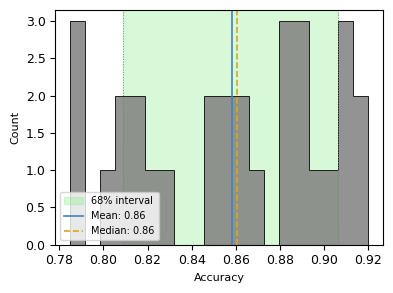

  Precision   : 0.8419 ± 0.0742  (n=30)


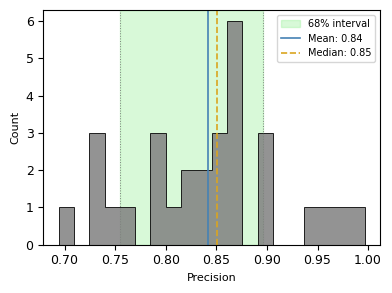

  Recall      : 0.8655 ± 0.0842  (n=30)


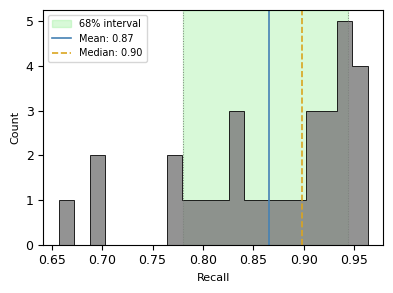

  F1 score    : 0.8483 ± 0.0457  (n=30)


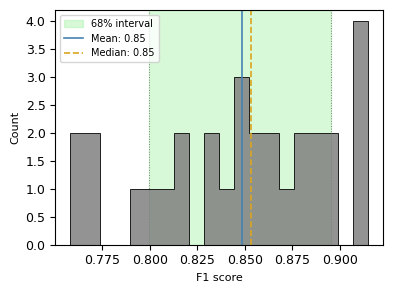

  AUC         : 0.9337 ± 0.0400  (n=30)


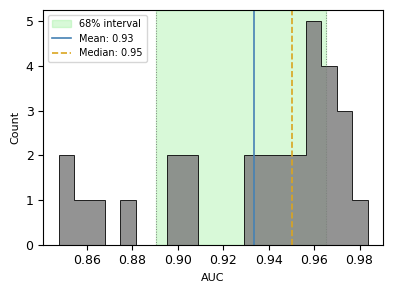

Saved:
  /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/metric_dist_accuracy_DualSSN_T25kpc_beam_crop.pdf
  /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/metric_dist_precision_DualSSN_T25kpc_beam_crop.pdf
  /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/metric_dist_recall_DualSSN_T25kpc_beam_crop.pdf
  /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/metric_dist_f1_score_DualSSN_T25kpc_beam_crop.pdf
  /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/metric_dist_auc_DualSSN_T25kpc_beam_crop.pdf


In [10]:
# Metric distributions across all folds & experiments (one figure per metric)
# Always uses all 10 folds × 3 experiments, regardless of the cfg above.

_full_cfg = RunConfig(
    classifier      = cfg.classifier,
    version         = cfg.version,
    crop_mode       = cfg.crop_mode,
    blur_method     = cfg.blur_method,
    lr              = cfg.lr,
    reg             = cfg.reg,
    label_smoothing = cfg.label_smoothing,
    percentile_lo   = cfg.percentile_lo,
    percentile_hi   = cfg.percentile_hi,
    noise_level     = cfg.noise_level,
    folds           = list(range(10)),
    num_experiments = 3,
)
with _warnings_md.catch_warnings():
    _warnings_md.simplefilter('ignore')
    _full_metrics = load_run(_full_cfg, verbose=False)

# Auto-discover subset sizes per fold (same logic as _collect_metrics)
_acc_key_pat = re.compile(r'^accuracy_(\d+)_(\d+)_\d+_')
_fold_to_subsets = defaultdict(set)
for _k in _full_metrics:
    _km = _acc_key_pat.match(_k)
    if _km:
        _fold_to_subsets[int(_km.group(2))].add(int(_km.group(1)))

_old_keys_md = _full_metrics.get('_old_keys', set())

# Collect all values across the 10 folds × 3 experiments
_all_vals = defaultdict(list)
for _fold in _full_cfg.folds:
    _available = _fold_to_subsets.get(_fold, set()) | set(_full_cfg.dataset_sizes.get(_fold, []))
    if not _available:
        continue
    _subset = max(_available)
    for _exp in range(_full_cfg.num_experiments):
        _k = f'{_subset}_{_fold}_{_exp}_{_full_cfg.lr}_{_full_cfg.reg}'
        if _k in _old_keys_md:
            continue
        for _met in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
            _all_vals[_met].extend(_full_metrics.get(f'{_met}_{_k}', []))

_METRIC_LABELS = {
    'accuracy':  'Accuracy',
    'precision': 'Precision',
    'recall':    'Recall',
    'f1_score':  'F1 score',
    'auc':       'AUC',
}

_saved = []
for _met, _label in _METRIC_LABELS.items():
    _vals = np.array(_all_vals.get(_met, []), dtype=float)
    _vals = _vals[np.isfinite(_vals)]

    fig, ax = plt.subplots(figsize=(4.0, 3.0))

    if _vals.size == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    else:
        _p16, _p50, _p84 = np.percentile(_vals, [16, 50, 84])
        _mean = _vals.mean()

        _vmin, _vmax = float(_vals.min()), float(_vals.max())
        if _vmin == _vmax:
            _eps = max(1e-6, abs(_vmin) * 1e-3)
            _vmin, _vmax = _vmin - _eps, _vmax + _eps
        _edges = np.linspace(_vmin, _vmax, 21)

        ax.hist(_vals, bins=_edges, histtype='stepfilled',
                color='gray', edgecolor='black', linewidth=0.7, alpha=0.85)
        ax.axvspan(_p16, _p84, color='lightgreen', alpha=0.35, zorder=0, label='68% interval')
        ax.axvline(_mean, color='steelblue', linewidth=1.2, label=f'Mean: {_mean:.2f}')
        ax.axvline(_p50, color='goldenrod', linewidth=1.2, linestyle='--', label=f'Median: {_p50:.2f}')
        ax.axvline(_p16, color='grey', linewidth=0.7, linestyle=':')
        ax.axvline(_p84, color='grey', linewidth=0.7, linestyle=':')
        ax.set_xlabel(_label, fontsize=8)
        ax.set_ylabel('Count', fontsize=8)
        ax.legend(fontsize=7, framealpha=0.8)
        print(f'  {_label:12s}: {_mean:.4f} \u00b1 {_vals.std():.4f}  (n={_vals.size})')

    plt.tight_layout()
    _fname = os.path.join(
        OUTPUT_DIR,
        f'metric_dist_{_met}_{cfg.classifier}_{cfg.version}_{cfg.crop_mode}.pdf',
    )
    plt.savefig(_fname, bbox_inches='tight')
    plt.show()
    plt.close()
    _saved.append(_fname)

print('Saved:')
for _f in _saved:
    print(' ', _f)

### Combined accuracy / recall distribution
Overlaid histogram of Accuracy and Recall on the same axes, with median and mean lines per metric.

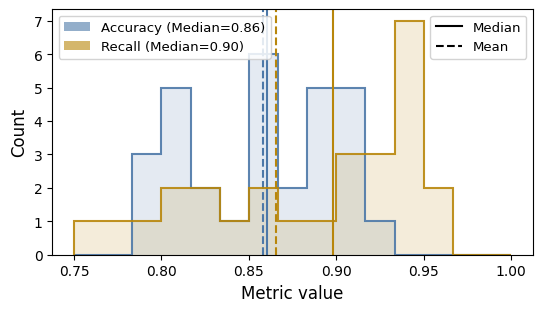

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/metric_dist_combined_DualSSN_T25kpc_beam_crop.pdf


In [11]:
# Combined Accuracy / Recall distribution — one histogram, colour = metric
_COMBO_METRICS = [
    ('accuracy', 'Accuracy', '#4c78a8'),
    ('recall',   'Recall',   '#b8860b'),
]

_fig, _ax = plt.subplots(figsize=(5.5, 3.2))

_SHARED_EDGES = np.linspace(0.75, 1.0, 16)

_medians = {}
for _met, _label, _col in _COMBO_METRICS:
    _vals = np.array(_all_vals.get(_met, []), dtype=float)
    _vals = _vals[np.isfinite(_vals)]
    if _vals.size == 0:
        continue

    _med  = float(np.median(_vals))
    _mean = float(_vals.mean())
    _medians[_met] = _med

    # Step outline
    _ax.hist(_vals, bins=_SHARED_EDGES,
             histtype='step',
             color=_col, linewidth=1.5, alpha=0.9)
    # Subtle fill
    _ax.hist(_vals, bins=_SHARED_EDGES,
             histtype='stepfilled',
             color=_col, linewidth=0, alpha=0.15)

    # Median — solid, Mean — dashed
    _ax.axvline(_med,  color=_col, linewidth=1.5, linestyle='-')
    _ax.axvline(_mean, color=_col, linewidth=1.5, linestyle='--')

_ax.set_xlabel('Metric value', fontsize=12)
_ax.set_ylabel('Count', fontsize=12)
_ax.tick_params(axis='both', labelsize=10)

_leg1 = _ax.legend(
    handles=[
        _Patch(facecolor=col, alpha=0.6,
               label=f'{lbl} (Median={_medians.get(met, float("nan")):.2f})')
        for met, lbl, col in _COMBO_METRICS
    ],
    fontsize=9.5, framealpha=0.85,
    loc='upper left',
)

_leg2 = _ax.legend(
    handles=[
        _mlines.Line2D([], [], color='k', linewidth=1.5, linestyle='-',  label='Median'),
        _mlines.Line2D([], [], color='k', linewidth=1.5, linestyle='--', label='Mean'),
    ],
    fontsize=9.5, framealpha=0.85,
    loc='upper right',
)
_ax.add_artist(_leg1)

_fig.tight_layout()

_fname = os.path.join(
    OUTPUT_DIR,
    f'metric_dist_combined_{cfg.classifier}_{cfg.version}_{cfg.crop_mode}.pdf',
)
plt.savefig(_fname, bbox_inches='tight')
plt.show()
plt.close()
print('Saved:', _fname)

### Average confusion matrix (single run)
Confusion matrix averaged over all folds × experiments for the run defined in the config cell above.

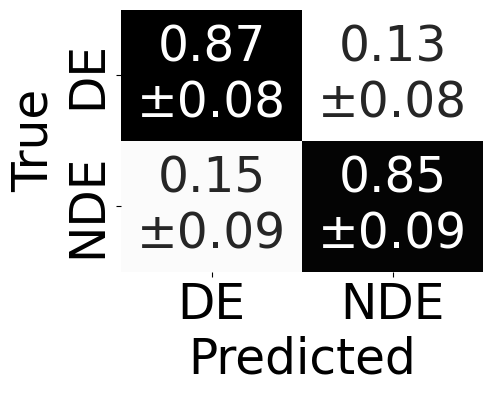

Averaged 30 confusion matrices.
Acc: 0.858 ± 0.043 (n=30)
DualSSN · T25kpc · beam_crop


In [12]:
# Average confusion matrix (inline display)

_cms = []
for _fold in cfg.folds:
    _subset = max(cfg.dataset_sizes[_fold])
    for _exp in range(cfg.num_experiments):
        _k = f'{_subset}_{_fold}_{_exp}_{cfg.lr}_{cfg.reg}'
        _tl_list = metrics.get(f'all_true_labels_{_k}', [])
        _pl_list = metrics.get(f'all_pred_labels_{_k}', [])
        if not _tl_list or not _pl_list:
            continue
        _tl_dict = _tl_list[0] if isinstance(_tl_list, list) else _tl_list
        _pl_dict = _pl_list[0] if isinstance(_pl_list, list) else _pl_list
        _key = next(iter(_tl_dict), None)
        if _key is None:
            continue
        _yt = _tl_dict[_key]
        _yp = _pl_dict.get(_key, [])
        if not _yt or not _yp:
            continue
        _cm = _confusion_matrix(_yt, _yp, normalize='true',
                                labels=list(range(len(cfg.galaxy_classes))))
        if _cm.shape[0] == len(cfg.galaxy_classes):
            _cms.append(_cm)

if not _cms:
    print('No confusion matrices found — check that metrics loaded correctly.')
else:
    _cms_arr = np.array(_cms)
    _avg_cm  = _cms_arr.mean(axis=0)
    _std_cm  = _cms_arr.std(axis=0)

    _ann = np.empty(_avg_cm.shape, dtype=object)
    for _i in range(_avg_cm.shape[0]):
        for _j in range(_avg_cm.shape[1]):
            _ann[_i, _j] = f'{_avg_cm[_i, _j]:.2f}\n±{_std_cm[_i, _j]:.2f}'

    _acc_vals = np.array(metrics_last.get('accuracy', []), dtype=float)
    _acc_vals = _acc_vals[np.isfinite(_acc_vals)]

    _desc = {c['tag']: c['description'] for c in _get_classes()}
    _labels = [_desc.get(t, str(t)) for t in cfg.galaxy_classes]

    _cmap = _LSC.from_list('wg', ['white', '#000000'])
    _fig, _ax = plt.subplots(figsize=(5, 4))
    _sns.heatmap(_avg_cm, annot=_ann, fmt='', cmap=_cmap,
                 xticklabels=_labels, yticklabels=_labels,
                 cbar=False, annot_kws={'size': 35}, ax=_ax)
    _ax.set_xlabel('Predicted', fontsize=35)
    _ax.set_ylabel('True', fontsize=35)
    _ax.tick_params(labelsize=35)
    _fig.tight_layout()
    plt.show()
    print(f'Averaged {len(_cms)} confusion matrices.')
    print(f'Acc: {_acc_vals.mean():.3f} ± {_acc_vals.std():.3f} (n={_acc_vals.size})\n'
          f'{cfg.classifier} · {cfg.version} · {cfg.crop_mode}')

### 4-panel confusion matrix — Reference, Beam crop
Average confusion matrix (10 folds × 3 experiments) for each classifier on Reference (RAW) images with beam crop. Classifier name is the panel title; y-axis label only on the leftmost panel.

Loading 4 confusion matrices...
  CNN ... Acc=0.670
  ScatterNet ... Acc=0.624
  DualCSN ... Acc=0.637
  DualSSN ... Acc=0.757


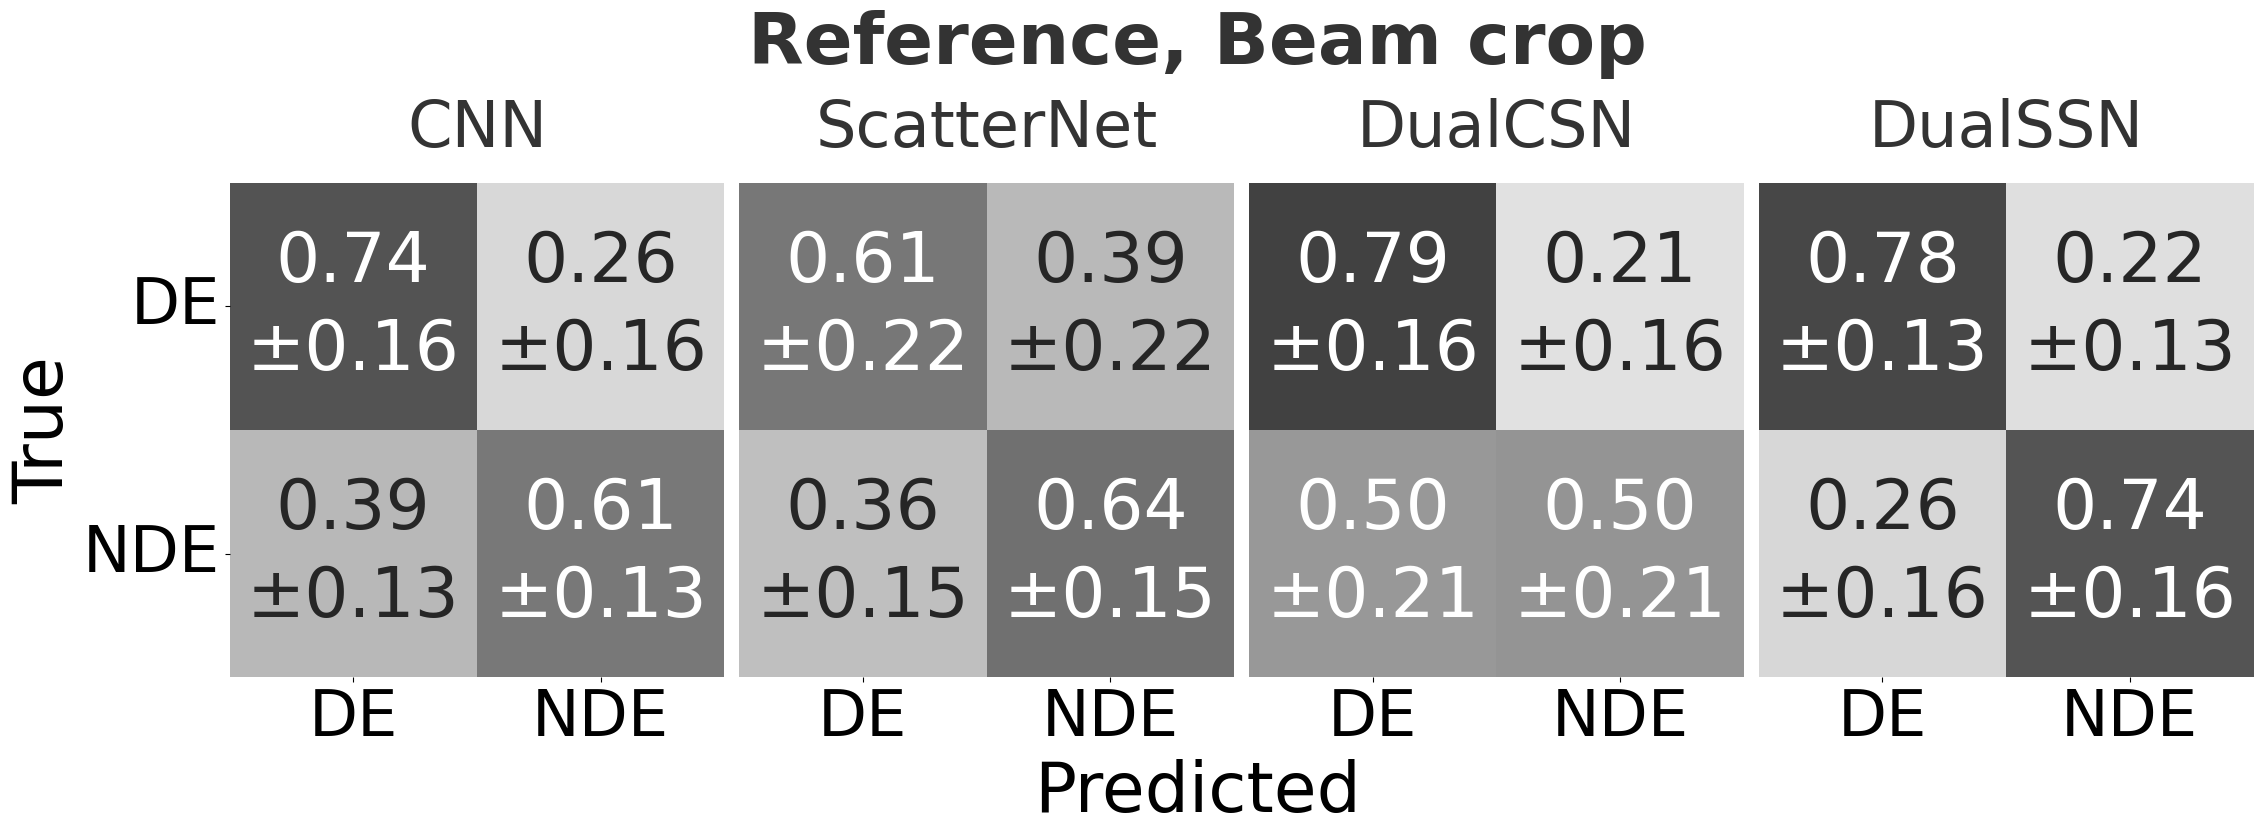

Saved → /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/confusion_matrices/cm_4panel_reference_beamcrop.pdf


In [13]:
# ── 4-panel confusion matrix: Reference, Beam crop ───────────────────────────
# One panel per classifier; version=RAW, crop_mode=beam_crop.

_ref4_panels = [
    ('CNN',        'ImageCNN'),
    ('ScatterNet', 'SimpleScatterNet'),
    ('DualCSN',    'DualCSN'),
    ('DualSSN',    'DualSSN'),
]
_ref4_labels  = ['DE', 'NDE']
_ref4_neutral = '0.2'
_ref4_cmap    = 'Greys'

# ── Load average CMs ──────────────────────────────────────────────────────────
def _load_avg_cm_ref4(clf_internal):
    _cfg = RunConfig(
        classifier=clf_internal, version='RAW', crop_mode='beam_crop',
        folds=list(range(10)), num_experiments=3,
    )
    import contextlib as _cl, io as _io_r
    with _cl.redirect_stdout(_io_r.StringIO()):
        _met = load_run(_cfg, verbose=False)
    _largest = max(sz for sizes in _cfg.dataset_sizes.values() for sz in sizes)
    _cms, _accs = [], []
    for _fold in _cfg.folds:
        _subset = max(_cfg.dataset_sizes[_fold])
        for _exp in range(_cfg.num_experiments):
            _k = f'{_subset}_{_fold}_{_exp}_{_cfg.lr}_{_cfg.reg}'
            _accs.extend(_met.get(f'accuracy_{_k}', []))
            _tl = _met.get(f'all_true_labels_{_k}', [])
            _pl = _met.get(f'all_pred_labels_{_k}', [])
            if not _tl or not _pl:
                continue
            _tl = _tl[0] if isinstance(_tl, list) else _tl
            _pl = _pl[0] if isinstance(_pl, list) else _pl
            _key = next(iter(_tl), None)
            if _key is None:
                continue
            _yt, _yp = _tl[_key], _pl.get(_key, [])
            if not _yt or not _yp:
                continue
            _cm = _confusion_matrix(_yt, _yp, normalize='true',
                                    labels=list(range(len(_cfg.galaxy_classes))))
            if _cm.shape[0] == len(_cfg.galaxy_classes):
                _cms.append(_cm)
    if not _cms:
        return None, None, float('nan'), float('nan')
    _arr = np.array(_cms)
    _av  = np.array([v for v in _accs if np.isfinite(v)])
    return (_arr.mean(0), _arr.std(0),
            _av.mean() if _av.size else float('nan'),
            _av.std()  if _av.size else float('nan'))

print('Loading 4 confusion matrices...')
_ref4_data = []
for _disp, _clf in _ref4_panels:
    print(f'  {_disp}', end=' ... ')
    _res = _load_avg_cm_ref4(_clf)
    _ref4_data.append(_res)
    print('N/A' if _res[0] is None else f'Acc={_res[2]:.3f}')

# ── Figure ────────────────────────────────────────────────────────────────────
_ref4_fig, _ref4_axes = plt.subplots(1, 4, figsize=(4 * 5.5, 12.0))
_ref4_fig.subplots_adjust(wspace=0.03, top=0.84, bottom=0.06,
                          left=0.06, right=0.98)

for _idx, (_ax, (_disp, _), (_avg, _std, _am, _as)) in enumerate(
        zip(_ref4_axes, _ref4_panels, _ref4_data)):

    if _avg is not None:
        _ann = np.empty(_avg.shape, dtype=object)
        for _i in range(_avg.shape[0]):
            for _j in range(_avg.shape[1]):
                _ann[_i, _j] = f'{_avg[_i, _j]:.2f}\n±{_std[_i, _j]:.2f}'
        _sns.heatmap(
            _avg, annot=_ann, fmt='', cmap=_ref4_cmap,
            xticklabels=_ref4_labels,
            yticklabels=_ref4_labels if _idx == 0 else False,
            annot_kws={'fontsize': 50, 'linespacing': 1.4},
            cbar=False, ax=_ax, vmin=0, vmax=1,
        )
    else:
        _ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                 transform=_ax.transAxes, fontsize=50)

    _ax.set_aspect('equal')

    for _sp in _ax.spines.values():
        _sp.set_edgecolor(_ref4_neutral)
        _sp.set_linewidth(2.5)

    # ── Classifier name as panel subtitle ─────────────────────────────────────
    _ax.annotate(
        _disp,
        xy=(0.5, 1.0), xycoords='axes fraction',
        xytext=(0, 16), textcoords='offset points',
        ha='center', va='bottom', fontsize=46, color=_ref4_neutral,
        annotation_clip=False,
    )

    _n = len(_ref4_labels)
    _ax.xaxis.set_major_locator(_FL11(np.arange(_n) + 0.5))
    _ax.set_xticklabels(_ref4_labels, fontsize=46, rotation=0)
    if _idx == 0:
        _ax.yaxis.set_major_locator(_FL11(np.arange(_n) + 0.5))
        _ax.set_yticklabels(_ref4_labels, fontsize=46, rotation=0)
        _ax.set_ylabel('True', fontsize=50)
    else:
        _ax.set_ylabel('')

_ref4_fig.supxlabel('Predicted', fontsize=50, y=0.12)
_ref4_fig.suptitle('Reference, Beam crop', fontsize=52, fontweight='bold',
                   color=_ref4_neutral, y=0.80)

_ref4_out = os.path.join(OUTPUT_DIR, 'confusion_matrices',
                         'cm_4panel_reference_beamcrop.pdf')
os.makedirs(os.path.dirname(_ref4_out), exist_ok=True)
_ref4_fig.savefig(_ref4_out, bbox_inches='tight')
plt.show()
print(f'Saved → {_ref4_out}')

### 11-panel confusion matrix grid
Fixed comparison grid (independent of the config cell above). Varies one dimension at a time around the global best configuration (DualSSN · T25kpc · beam\_crop):
- **Group A** (panels 0–3): vary image version, fixed DualSSN + beam\_crop
- **Group B** (panels 4–6): vary crop mode, fixed DualSSN + T25kpc
- **Group C** (panels 7–10): vary classifier, fixed T25kpc + beam\_crop

Loading 11 confusion matrices...
  DualSSN              / RAW      / beam_crop ... Acc=0.757
  DualSSN              / T25kpc   / beam_crop ... Acc=0.858
  DualSSN              / T50kpc   / beam_crop ... Acc=0.777
  DualSSN              / T100kpc  / beam_crop ... Acc=0.766
  DualSSN              / T25kpc   / beam_crop ... Acc=0.858
  DualSSN              / T25kpc   / fov_crop ... Acc=0.733
  DualSSN              / T25kpc   / pixel_crop ... Acc=0.675
  ImageCNN             / T25kpc   / beam_crop ... Acc=0.723
  SimpleScatterNet     / T25kpc   / beam_crop ... Acc=0.577
  DualCSN              / T25kpc   / beam_crop ... Acc=0.796
  DualSSN              / T25kpc   / beam_crop ... Acc=0.858
Done.



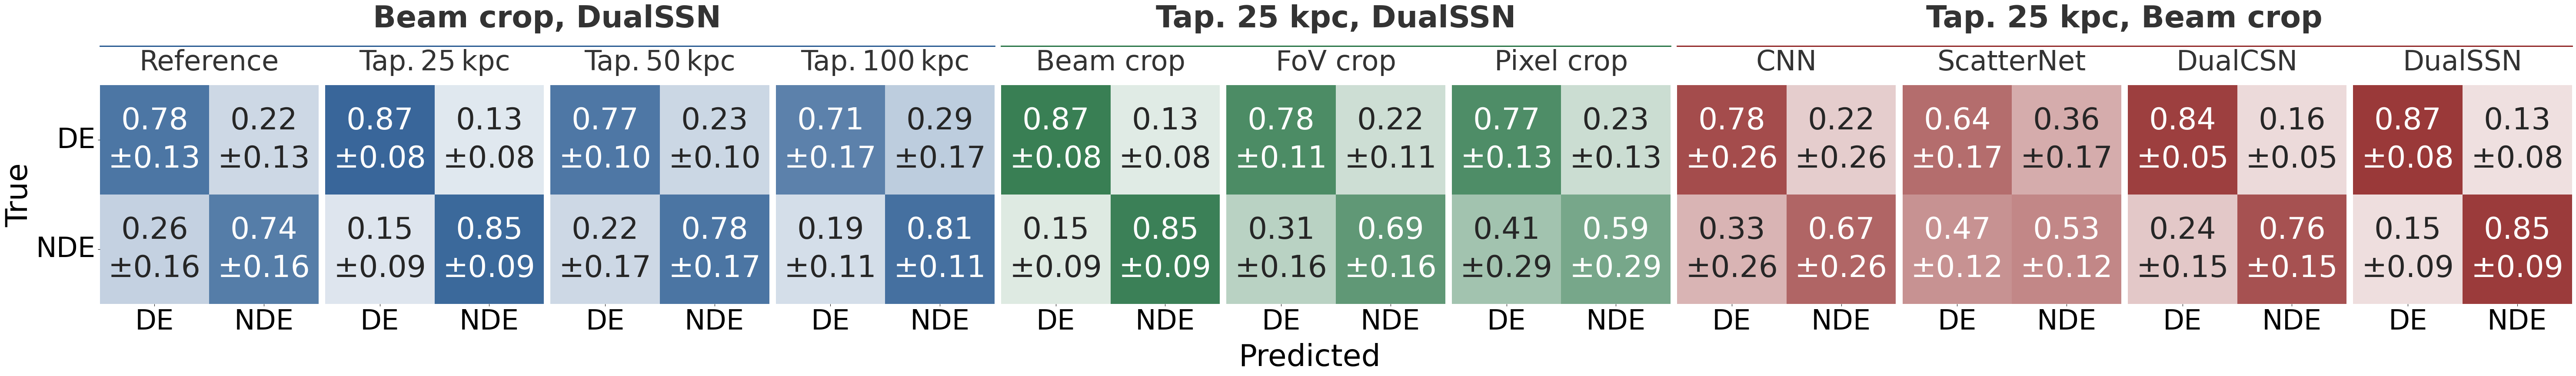

Saved → /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/confusion_matrices/cm_11panel_global_max.pdf


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11-panel confusion matrix comparison grid
# Varies one dimension at a time around the global best:
#   DualSSN · T25kpc · beam_crop
#
# Group A (panels 0–3):  vary version     (DualSSN,  beam_crop)
# Group B (panels 4–6):  vary crop mode   (DualSSN,  T25kpc)
# Group C (panels 7–10): vary classifier  (T25kpc,   beam_crop)
# ═══════════════════════════════════════════════════════════════════════════════


# ── Constants ─────────────────────────────────────────────────────────────────
_NEUTRAL11     = '0.2'   # single colour for all text and borders
_CLF_DISPLAY11 = {'ImageCNN': 'CNN', 'SimpleScatterNet': 'ScatterNet',
                  'DualCSN': 'DualCSN', 'DualSSN': 'DualSSN'}
_GLOBAL_MAX11  = ('DualSSN', 'T25kpc', 'beam_crop')
_SHORT_LABELS11 = ['DE', 'NDE']

def _vd11(v: str) -> str:
    """Version display: RAW→'Reference', T25kpc→'Tap. 25 kpc', etc."""
    N = '\u202f'  # narrow no-break space
    if v == 'RAW':
        return 'Reference'
    m = _re11.match(r'^(T|Blur)(\d+)kpc$', v)
    if m:
        pfx, sc = m.group(1), m.group(2)
        return f'Tap.{N}{sc}{N}kpc' if pfx == 'T' else f'Blur{N}{sc}{N}kpc'
    return v

# ── Panel definitions ─────────────────────────────────────────────────────────
_panels11 = [
    # Group A: vary version — fixed: DualSSN, beam_crop
    ('DualSSN', 'RAW',     'beam_crop'),
    ('DualSSN', 'T25kpc',  'beam_crop'),
    ('DualSSN', 'T50kpc',  'beam_crop'),
    ('DualSSN', 'T100kpc', 'beam_crop'),
    # Group B: vary crop mode — fixed: DualSSN, T25kpc
    ('DualSSN', 'T25kpc',  'beam_crop'),
    ('DualSSN', 'T25kpc',  'fov_crop'),
    ('DualSSN', 'T25kpc',  'pixel_crop'),
    # Group C: vary classifier — fixed: T25kpc, beam_crop
    ('ImageCNN',         'T25kpc', 'beam_crop'),
    ('SimpleScatterNet', 'T25kpc', 'beam_crop'),
    ('DualCSN',          'T25kpc', 'beam_crop'),
    ('DualSSN',          'T25kpc', 'beam_crop'),
]

_GROUPS11 = [
    ('Beam crop, DualSSN',        0,  3),
    ('Tap. 25 kpc, DualSSN',         4,  6),
    ('Tap. 25 kpc, Beam crop', 7, 10),
]

_cmaps11 = [
    _LSC11.from_list('wA', ['white', '#1a4f8a']),  # Group A: blue
    _LSC11.from_list('wB', ['white', '#1a6b3a']),  # Group B: green
    _LSC11.from_list('wC', ['white', '#8a1a1a']),  # Group C: red
]

# ── Per-panel subtitle: the varying dimension only ────────────────────────────
def _panel_label11(clf, ver, crop, group_idx):
    if group_idx == 0:
        return _vd11(ver)
    elif group_idx == 1:
        return {'beam_crop': 'Beam crop', 'fov_crop': 'FoV crop',
                'pixel_crop': 'Pixel crop'}[crop]
    else:
        return _CLF_DISPLAY11.get(clf, clf)

def _panel_group11(idx):
    for g, (_, i0, i1) in enumerate(_GROUPS11):
        if i0 <= idx <= i1:
            return g
    return 0

# ── Helper: average CM over all folds/experiments ─────────────────────────────
def _avg_cm11(clf, version, crop):
    """Return (avg_cm, std_cm, acc_mean, acc_std) or (None, None, nan, nan)."""
    cfg_ = RunConfig(
        classifier=clf, version=version, crop_mode=crop,
        folds=list(range(10)), num_experiments=3,
    )
    met_ = load_run(cfg_, verbose=False)
    largest_ = max(sz for sizes in cfg_.dataset_sizes.values() for sz in sizes)

    cms_, accs_ = [], []
    for fold_ in cfg_.folds:
        subset_ = max(cfg_.dataset_sizes[fold_])
        if subset_ != largest_:
            continue
        for exp_ in range(cfg_.num_experiments):
            k_ = f'{subset_}_{fold_}_{exp_}_{cfg_.lr}_{cfg_.reg}'
            accs_.extend(met_.get(f'accuracy_{k_}', []))

            tl_list_ = met_.get(f'all_true_labels_{k_}', [])
            pl_list_ = met_.get(f'all_pred_labels_{k_}', [])
            if not tl_list_ or not pl_list_:
                continue

            tl_dict_ = tl_list_[0] if isinstance(tl_list_, list) else tl_list_
            pl_dict_ = pl_list_[0] if isinstance(pl_list_, list) else pl_list_

            _key = next(iter(tl_dict_), None)
            if _key is None:
                continue

            y_true_ = tl_dict_[_key]
            y_pred_ = pl_dict_.get(_key, [])
            if not y_true_ or not y_pred_:
                continue

            cm_ = _cm11(
                y_true_, y_pred_,
                normalize='true',
                labels=list(range(len(cfg_.galaxy_classes))),
            )
            if cm_.shape[0] == len(cfg_.galaxy_classes):
                cms_.append(cm_)

    if not cms_:
        return None, None, float('nan'), float('nan')

    arr_ = np.array(cms_)
    aav_ = np.array([v for v in accs_ if np.isfinite(v)])
    return (
        arr_.mean(0), arr_.std(0),
        aav_.mean() if aav_.size else float('nan'),
        aav_.std()  if aav_.size else float('nan'),
    )

# ── Load all 11 panels ────────────────────────────────────────────────────────
print('Loading 11 confusion matrices...')
_pdata11 = []
for _clf11, _ver11, _crop11 in _panels11:
    print(f'  {_clf11:20s} / {_ver11:8s} / {_crop11}', end=' ... ')
    _res11 = _avg_cm11(_clf11, _ver11, _crop11)
    _pdata11.append(_res11)
    _avgcm11, _, _am11, _ = _res11
    print('N/A' if _avgcm11 is None else f'Acc={_am11:.3f}')
print('Done.\n')

# ── Figure ────────────────────────────────────────────────────────────────────
_fig11, _axes11 = plt.subplots(1, 11, figsize=(11 * 5.5, 12.0))
_fig11.subplots_adjust(wspace=0.03, top=0.60, bottom=0.10, left=0.04, right=0.98)

for _idx11, (_ax11, (_clf, _ver, _crop), (_avg, _std, _am, _as)) in enumerate(
        zip(_axes11, _panels11, _pdata11)):

    _grp = _panel_group11(_idx11)
    _lw  = 5.0 if (_clf, _ver, _crop) == _GLOBAL_MAX11 else 2.5

    if _avg is not None:
        _ann = np.empty(_avg.shape, dtype=object)
        for _i in range(_avg.shape[0]):
            for _j in range(_avg.shape[1]):
                _ann[_i, _j] = f'{_avg[_i, _j]:.2f}\n±{_std[_i, _j]:.2f}'

        _sns11.heatmap(
            _avg, annot=_ann, fmt='', cmap=_cmaps11[_grp],
            xticklabels=_SHORT_LABELS11,
            yticklabels=_SHORT_LABELS11 if _idx11 == 0 else False,
            annot_kws={'fontsize': 50, 'linespacing': 1.4},
            cbar=False, ax=_ax11,
            vmin=0, vmax=1,
        )
    else:
        _ax11.text(0.5, 0.5, 'N/A', ha='center', va='center',
                   transform=_ax11.transAxes, fontsize=50)

    _ax11.set_aspect('equal')

    # Neutral border; thicker for global best
    for _sp in _ax11.spines.values():
        _sp.set_edgecolor(_NEUTRAL11)
        _sp.set_linewidth(_lw)

    # Per-panel subtitle: varying dimension only, neutral colour
    _ax11.annotate(
        _panel_label11(_clf, _ver, _crop, _grp),
        xy=(0.5, 1.0), xycoords='axes fraction',
        xytext=(0, 16), textcoords='offset points',
        ha='center', va='bottom', fontsize=46, color=_NEUTRAL11,
        annotation_clip=False,
    )

    # FixedLocator before set_ticklabels
    _n11 = len(_SHORT_LABELS11)
    _ax11.xaxis.set_major_locator(_FL11(np.arange(_n11) + 0.5))
    _ax11.set_xticklabels(_SHORT_LABELS11, fontsize=46, rotation=0)
    if _idx11 == 0:
        _ax11.yaxis.set_major_locator(_FL11(np.arange(_n11) + 0.5))
        _ax11.set_yticklabels(_SHORT_LABELS11, fontsize=46, rotation=0)
        _ax11.set_ylabel('True', fontsize=50)
    else:
        _ax11.set_ylabel('')

_fig11.supxlabel('Predicted', fontsize=50, y=0.01)

# ── Group separator labels and underlines ─────────────────────────────────────
_fig11.canvas.draw()

def _ax_cx11(i):
    p = _axes11[i].get_position()
    return p.x0 + p.width / 2

_y_top11 = max(_ax.get_position().y1 for _ax in _axes11) + 0.10

for _gi11, (_grp_lbl, _i0, _i1) in enumerate(_GROUPS11):
    _cx = (_ax_cx11(_i0) + _ax_cx11(_i1)) / 2
    _fig11.text(
        _cx, _y_top11, _grp_lbl,
        ha='center', va='bottom',
        fontsize=50, fontweight='bold', color=_NEUTRAL11,
        transform=_fig11.transFigure,
    )
    _fig11.add_artist(_Line2D11(
        [_axes11[_i0].get_position().x0, _axes11[_i1].get_position().x1],
        [_y_top11 - 0.025, _y_top11 - 0.025],
        transform=_fig11.transFigure,
        color=_cmaps11[_gi11](1.0), linewidth=2.0, clip_on=False,
    ))

# ── Save ──────────────────────────────────────────────────────────────────────
try:
    _out_dir11 = os.path.join(OUTPUT_DIR, 'confusion_matrices')
except NameError:
    _out_dir11 = os.path.join(
        os.path.expanduser('~'), 'scratch', 'data', 'PSZ2',
        'beam_crop', 'confusion_matrices',
    )
os.makedirs(_out_dir11, exist_ok=True)
_save11 = os.path.join(_out_dir11, 'cm_11panel_global_max.pdf')
_fig11.savefig(_save11, bbox_inches='tight')
plt.show()
print(f'Saved → {_save11}')

Loading 10 confusion matrices...
  DualSSN              / RAW        / beam_crop ... Acc=0.757
  DualSSN              / T50kpc     / beam_crop ... Acc=0.777
  DualSSN              / T100kpc    / beam_crop ... Acc=0.766
  DualSSN              / T25kpc     / fov_crop ... Acc=0.733
  DualSSN              / T25kpc     / pixel_crop ... Acc=0.675
  ImageCNN             / T25kpc     / beam_crop ... Acc=0.723
  SimpleScatterNet     / T25kpc     / beam_crop ... Acc=0.577
  DualCSN              / T25kpc     / beam_crop ... Acc=0.796
  DualSSN              / Blur50kpc  / beam_crop ... Acc=0.809
  DualSSN              / T25kpc     / beam_crop ... Acc=0.858
Done.



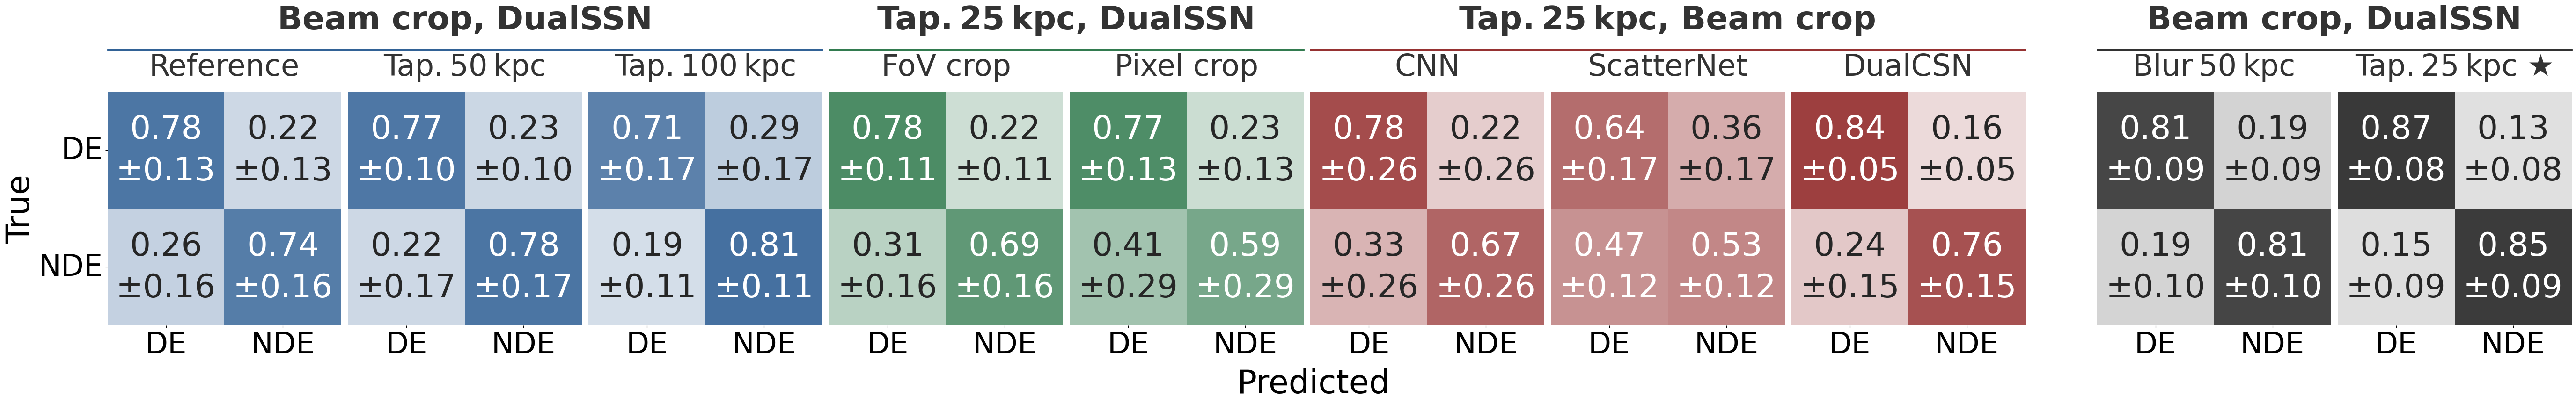

Saved → /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/confusion_matrices/cm_10panel_with_best.pdf


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# 10-panel + spacer confusion matrix comparison grid
# Varies one dimension at a time around the global best:
#   DualSSN · T25kpc · beam_crop  (shown once, in b&w, at the end)
#
# Group A (panels 0–2):  vary version     (DualSSN,  beam_crop)   — blue
# Group B (panels 3–4):  vary crop mode   (DualSSN,  T25kpc)      — green
# Group C (panels 5–7):  vary classifier  (T25kpc,   beam_crop)   — red
# [spacer]
# Group D (panels 8–9):  Blur50kpc + global best                  — b&w
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.gridspec as gridspec

# ── Constants ─────────────────────────────────────────────────────────────────
_NEUTRAL10     = '0.2'
_CLF_DISPLAY10 = {'ImageCNN': 'CNN', 'SimpleScatterNet': 'ScatterNet',
                  'DualCSN': 'DualCSN', 'DualSSN': 'DualSSN'}
_GLOBAL_MAX10  = ('DualSSN', 'T25kpc', 'beam_crop')
_SHORT_LABELS10 = ['DE', 'NDE']

import re as _re10
from matplotlib.colors import LinearSegmentedColormap as _LSC10
import seaborn as _sns10
from matplotlib.lines import Line2D as _Line2D10
from matplotlib.ticker import FixedLocator as _FL10
from sklearn.metrics import confusion_matrix as _cm10

def _vd10(v: str) -> str:
    """Version display helper."""
    N = '\u202f'
    if v == 'RAW':
        return 'Reference'
    m = re.match(r'^(T|Blur)(\d+)kpc$', v)
    if m:
        pfx, sc = m.group(1), m.group(2)
        return f'Tap.{N}{sc}{N}kpc' if pfx == 'T' else f'Blur{N}{sc}{N}kpc'
    return v

# ── Panel definitions (clf, version, crop) ────────────────────────────────────
_panels10 = [
    # Group A: vary version — fixed: DualSSN, beam_crop
    ('DualSSN', 'RAW',     'beam_crop'),
    ('DualSSN', 'T50kpc',  'beam_crop'),
    ('DualSSN', 'T100kpc', 'beam_crop'),
    # Group B: vary crop — fixed: DualSSN, T25kpc
    ('DualSSN', 'T25kpc',  'fov_crop'),
    ('DualSSN', 'T25kpc',  'pixel_crop'),
    # Group C: vary classifier — fixed: T25kpc, beam_crop
    ('ImageCNN',         'T25kpc', 'beam_crop'),
    ('SimpleScatterNet', 'T25kpc', 'beam_crop'),
    ('DualCSN',          'T25kpc', 'beam_crop'),
    # Group D: Blur comparison + global best — fixed: DualSSN, beam_crop
    ('DualSSN', 'Blur50kpc', 'beam_crop'),
    ('DualSSN', 'T25kpc',   'beam_crop'),   # global best
]

# Group definitions: (title, panel_idx_start, panel_idx_end)
_GROUPS10 = [
    ('Beam crop, DualSSN',   0, 2),   # A
    ('Tap.\u202f25\u202fkpc, DualSSN', 3, 4),   # B
    ('Tap.\u202f25\u202fkpc, Beam crop', 5, 7),  # C
    ('Beam crop, DualSSN',   8, 9),   # D (b&w)
]

# ── Colour maps ───────────────────────────────────────────────────────────────
_cmaps10 = [
    _LSC10.from_list('wA', ['white', '#1a4f8a']),   # A: blue
    _LSC10.from_list('wB', ['white', '#1a6b3a']),   # B: green
    _LSC10.from_list('wC', ['white', '#8a1a1a']),   # C: red
    _LSC10.from_list('wD', ['white', '#1a1a1a']),   # D: black & white
]

# ── Panel subtitle: the varying dimension only ────────────────────────────────
_CROP_LABEL10 = {'beam_crop': 'Beam crop', 'fov_crop': 'FoV crop',
                 'pixel_crop': 'Pixel crop'}

def _panel_label10(clf, ver, crop, group_idx):
    if group_idx == 0:   # A: varying version
        return _vd10(ver)
    elif group_idx == 1: # B: varying crop
        return _CROP_LABEL10.get(crop, crop)
    elif group_idx == 2: # C: varying classifier
        return _CLF_DISPLAY10.get(clf, clf)
    else:                # D: label the version; mark global best with a star
        label = _vd10(ver)
        if (clf, ver, crop) == _GLOBAL_MAX10:
            label += ' ★'
        return label

def _panel_group10(idx):
    for g, (_, i0, i1) in enumerate(_GROUPS10):
        if i0 <= idx <= i1:
            return g
    return 0

# ── Helper: average CM over all folds/experiments (unchanged logic) ───────────
def _avg_cm10(clf, version, crop):
    """Return (avg_cm, std_cm, acc_mean, acc_std) or (None, None, nan, nan)."""
    cfg_ = RunConfig(
        classifier=clf, version=version, crop_mode=crop,
        folds=list(range(10)), num_experiments=3,
    )
    met_ = load_run(cfg_, verbose=False)
    largest_ = max(sz for sizes in cfg_.dataset_sizes.values() for sz in sizes)

    cms_, accs_ = [], []
    for fold_ in cfg_.folds:
        subset_ = max(cfg_.dataset_sizes[fold_])
        if subset_ != largest_:
            continue
        for exp_ in range(cfg_.num_experiments):
            k_ = f'{subset_}_{fold_}_{exp_}_{cfg_.lr}_{cfg_.reg}'
            accs_.extend(met_.get(f'accuracy_{k_}', []))

            tl_list_ = met_.get(f'all_true_labels_{k_}', [])
            pl_list_ = met_.get(f'all_pred_labels_{k_}', [])
            if not tl_list_ or not pl_list_:
                continue

            tl_dict_ = tl_list_[0] if isinstance(tl_list_, list) else tl_list_
            pl_dict_ = pl_list_[0] if isinstance(pl_list_, list) else pl_list_

            _key = next(iter(tl_dict_), None)
            if _key is None:
                continue

            y_true_ = tl_dict_[_key]
            y_pred_ = pl_dict_.get(_key, [])
            if not y_true_ or not y_pred_:
                continue

            cm_ = _cm10(
                y_true_, y_pred_,
                normalize='true',
                labels=list(range(len(cfg_.galaxy_classes))),
            )
            if cm_.shape[0] == len(cfg_.galaxy_classes):
                cms_.append(cm_)

    if not cms_:
        return None, None, float('nan'), float('nan')

    arr_ = np.array(cms_)
    aav_ = np.array([v for v in accs_ if np.isfinite(v)])
    return (
        arr_.mean(0), arr_.std(0),
        aav_.mean() if aav_.size else float('nan'),
        aav_.std()  if aav_.size else float('nan'),
    )

# ── Load all panels ───────────────────────────────────────────────────────────
print('Loading 10 confusion matrices...')
_pdata10 = []
for _clf10, _ver10, _crop10 in _panels10:
    print(f'  {_clf10:20s} / {_ver10:10s} / {_crop10}', end=' ... ')
    _res10 = _avg_cm10(_clf10, _ver10, _crop10)
    _pdata10.append(_res10)
    _avgcm10, _, _am10, _ = _res10
    print('N/A' if _avgcm10 is None else f'Acc={_am10:.3f}')
print('Done.\n')

# ── Figure: use GridSpec with a narrow spacer column ─────────────────────────
# 10 CM panels + 1 spacer = 11 columns total
# Spacer sits between panel index 7 (C) and 8 (D)
_n_panels = 10
_spacer_col = 8          # GridSpec column index of the spacer
_panel_cols = list(range(8)) + [9, 10]   # GridSpec columns for the 10 panels

_fig10 = plt.figure(figsize=(_n_panels * 5.5 + 1.0, 12.0))
_gs10  = gridspec.GridSpec(
    1, 11,
    figure=_fig10,
    width_ratios=[1]*8 + [0.25] + [1]*2,   # spacer at col 8 is narrow
    wspace=0.03,
)
_fig10.subplots_adjust(top=0.60, bottom=0.10, left=0.04, right=0.98)

# Create axes: 10 CM panels + 1 invisible spacer
_axes10 = [_fig10.add_subplot(_gs10[0, c]) for c in _panel_cols]
_spacer_ax = _fig10.add_subplot(_gs10[0, _spacer_col])
_spacer_ax.set_visible(False)   # purely structural; invisible

# ── Draw each panel ───────────────────────────────────────────────────────────
for _idx10, (_ax10, (_clf, _ver, _crop), (_avg, _std, _am, _as)) in enumerate(
        zip(_axes10, _panels10, _pdata10)):

    _grp = _panel_group10(_idx10)
    _lw  = 5.0 if (_clf, _ver, _crop) == _GLOBAL_MAX10 else 2.5

    if _avg is not None:
        _ann = np.empty(_avg.shape, dtype=object)
        for _i in range(_avg.shape[0]):
            for _j in range(_avg.shape[1]):
                _ann[_i, _j] = f'{_avg[_i, _j]:.2f}\n±{_std[_i, _j]:.2f}'

        _sns10.heatmap(
            _avg, annot=_ann, fmt='', cmap=_cmaps10[_grp],
            xticklabels=_SHORT_LABELS10,
            yticklabels=_SHORT_LABELS10 if _idx10 == 0 else False,
            annot_kws={'fontsize': 50, 'linespacing': 1.4},
            cbar=False, ax=_ax10,
            vmin=0, vmax=1,
        )
    else:
        _ax10.text(0.5, 0.5, 'N/A', ha='center', va='center',
                   transform=_ax10.transAxes, fontsize=50)

    _ax10.set_aspect('equal')

    for _sp in _ax10.spines.values():
        _sp.set_edgecolor(_NEUTRAL10)
        _sp.set_linewidth(_lw)

    _ax10.annotate(
        _panel_label10(_clf, _ver, _crop, _grp),
        xy=(0.5, 1.0), xycoords='axes fraction',
        xytext=(0, 16), textcoords='offset points',
        ha='center', va='bottom', fontsize=46, color=_NEUTRAL10,
        annotation_clip=False,
    )

    _n10 = len(_SHORT_LABELS10)
    _ax10.xaxis.set_major_locator(_FL10(np.arange(_n10) + 0.5))
    _ax10.set_xticklabels(_SHORT_LABELS10, fontsize=46, rotation=0)
    if _idx10 == 0:
        _ax10.yaxis.set_major_locator(_FL10(np.arange(_n10) + 0.5))
        _ax10.set_yticklabels(_SHORT_LABELS10, fontsize=46, rotation=0)
        _ax10.set_ylabel('True', fontsize=50)
    else:
        _ax10.set_ylabel('')

_fig10.supxlabel('Predicted', fontsize=50, y=0.01)

# ── Group separator labels and underlines ─────────────────────────────────────
_fig10.canvas.draw()

def _ax_cx10(panel_idx):
    """Figure-fraction x centre of panel by its panel index (0–9)."""
    p = _axes10[panel_idx].get_position()
    return p.x0 + p.width / 2

_y_top10 = max(_ax.get_position().y1 for _ax in _axes10) + 0.10

for _gi10, (_grp_lbl, _i0, _i1) in enumerate(_GROUPS10):
    _cx = (_ax_cx10(_i0) + _ax_cx10(_i1)) / 2
    _fig10.text(
        _cx, _y_top10, _grp_lbl,
        ha='center', va='bottom',
        fontsize=50, fontweight='bold', color=_NEUTRAL10,
        transform=_fig10.transFigure,
    )
    _fig10.add_artist(_Line2D10(
        [_axes10[_i0].get_position().x0, _axes10[_i1].get_position().x1],
        [_y_top10 - 0.025, _y_top10 - 0.025],
        transform=_fig10.transFigure,
        color=_cmaps10[_gi10](1.0), linewidth=2.0, clip_on=False,
    ))

# ── Save ──────────────────────────────────────────────────────────────────────
try:
    _out_dir10 = os.path.join(OUTPUT_DIR, 'confusion_matrices')
except NameError:
    _out_dir10 = os.path.join(
        os.path.expanduser('~'), 'scratch', 'data', 'PSZ2',
        'beam_crop', 'confusion_matrices',
    )
os.makedirs(_out_dir10, exist_ok=True)
_save10 = os.path.join(_out_dir10, 'cm_10panel_with_best.pdf')
_fig10.savefig(_save10, bbox_inches='tight')
plt.show()
print(f'Saved → {_save10}')

### Example predictions: DualSSN · T25kpc · Beam crop

Test samples (aug): 888,  runs pooled: 30
Scattering2D(L=12) did NOT consume torch RNG
✓ Loading data from cache: /users/mbredber/p2_DCRECLASS/outputs/scratch/.cache/images/cache_cls50_51_verT25kpc_cropbeam_crop_blurcircular_pct30-99_aug_nobal_str_f9_699ad7687c290370.pt
✓ perm_test validated — all 888 labels aligned
Runs with all 4 quadrants populated: 23 / 30
Selected run indices: [4, 5, 8]
Unique slugs used: 12 — {'PSZ2G205.90+73.76', 'PSZ2G195.60+44.06', 'PSZ2G066.41+27.03', 'PSZ2G114.31+64.89', 'PSZ2G186.37+37.26', 'PSZ2G065.45+78.10', 'PSZ2G181.06+48.47', 'PSZ2G166.09+43.38', 'PSZ2G126.20-33.17', 'PSZ2G048.75+53.18', 'PSZ2G050.46+67.54', 'PSZ2G056.14+28.06'}


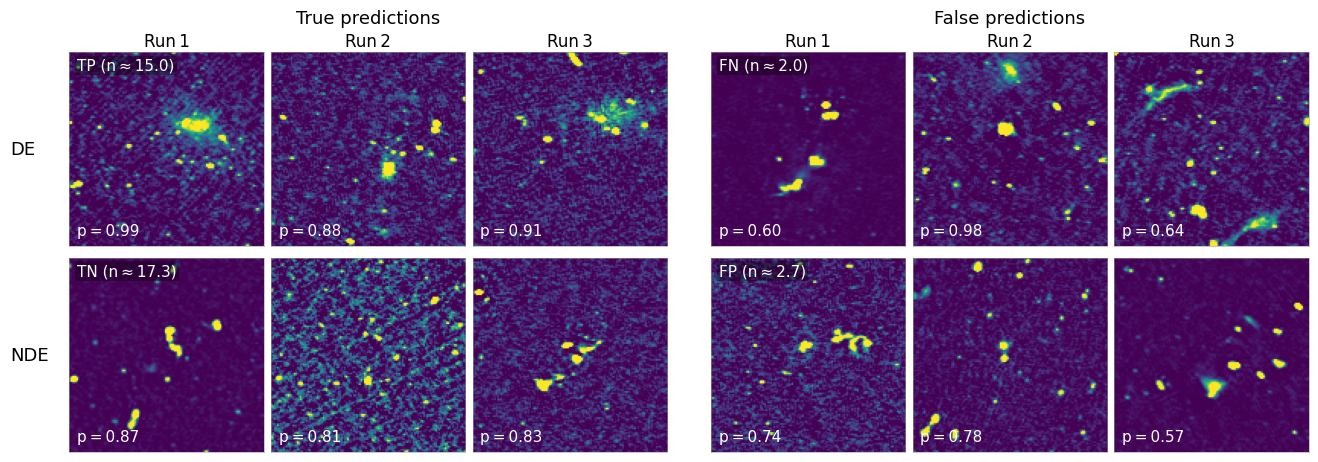

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/example_predictions_DualSSN_T25kpc_beam_crop.pdf


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Example predictions figure: DualSSN · T25kpc · beam_crop
#
# Layout (2 rows × 6 cols):
#   Row 0 (DE):  TP [col 0-2] | FN [col 3-5]
#   Row 1 (NDE): TN [col 0-2] | FP [col 3-5]
#
# Each column = one run (fold × experiment pair), selected randomly from the
# runs that have at least one example in all four quadrants.
# p= inside each image = per-cluster mean p(predicted class) for that run.
# ══════════════════════════════════════════════════════════════════════════════

import torch          as _torch
import random         as _random
from astropy.io import fits as _fits_io
from pathlib    import Path  as _Path
from matplotlib.gridspec import GridSpec as _GridSpec
from dcreclass.data.loaders import load_galaxies as _load_galaxies

# ── 1. Load predictions from all folds × experiments ─────────────────────────
_EX_CFG = RunConfig(
    classifier='DualSSN', version='T25kpc', crop_mode='beam_crop',
    folds=list(range(10)), num_experiments=3,
)
_ex_metrics = load_run(_EX_CFG, verbose=False)
_ex_subset  = max(sz for sizes in _EX_CFG.dataset_sizes.values() for sz in sizes)

_all_y_true  = None
_all_y_probs = []   # list of 30 arrays, each shape [888, 2]

for _fold in range(10):
    for _exp in range(_EX_CFG.num_experiments):
        _k      = f'{_ex_subset}_{_fold}_{_exp}_{_EX_CFG.lr}_{_EX_CFG.reg}'
        _tl_lst = _ex_metrics.get(f'all_true_labels_{_k}', [])
        _pp_lst = _ex_metrics.get(f'all_pred_probs_{_k}',  [])
        if not _tl_lst or not _pp_lst:
            continue
        _tl_d = _tl_lst[0] if isinstance(_tl_lst, list) else _tl_lst
        _pp_d = _pp_lst[0] if isinstance(_pp_lst, list) else _pp_lst
        _key  = next(iter(_tl_d), None)
        if _key is None:
            continue
        _yt = np.array(_tl_d[_key])
        _yp = np.array(_pp_d.get(_key, []))
        if _yt.size == 0 or _yp.size == 0:
            continue
        if _all_y_true is None:
            _all_y_true = _yt
        _all_y_probs.append(_yp)

assert _all_y_true is not None, 'No valid pkl entries found for DualSSN T25kpc beam_crop'
_n_test_aug = len(_all_y_true)
print(f'Test samples (aug): {_n_test_aug},  runs pooled: {len(_all_y_probs)}')

# ── 2. Reproduce perm_test from the training script ───────────────────────────
_random.seed(42); np.random.seed(42); _torch.manual_seed(42)

try:
    from kymatio.torch import Scattering2D as _Scat2D
    _rng_pre  = _torch.get_rng_state()
    _scat_tmp = _Scat2D(J=2, L=12, shape=(128, 128), max_order=2)
    _rng_post = _torch.get_rng_state()
    _scat_used_rng = not _torch.equal(_rng_pre, _rng_post)
    print(f'Scattering2D(L=12) {"consumed" if _scat_used_rng else "did NOT consume"} torch RNG')
    del _scat_tmp
except Exception as _e:
    print(f'Scattering2D unavailable ({_e}); perm_test reconstruction may differ')

_tst_out = _load_galaxies(
    galaxy_classes=[50, 51], versions=['T25kpc'], fold=9,
    crop_size=(512, 512), downsample_size=(128, 128), sample_size=1000000,
    REMOVEOUTLIERS=False, BALANCE=False, AUGMENT=True, STRETCH=True,
    percentile_lo=30, percentile_hi=99, NORMALISE=True, NORMALISETOPM=False,
    USE_GLOBAL_NORMALISATION=False, global_norm_mode='none',
    PRINTFILENAMES=True, USE_CACHE=True, DEBUG=False,
    crop_mode='beam_crop', blur_method='circular',
    cache_dir='/users/mbredber/p2_DCRECLASS/outputs/scratch/.cache/images',
    train=False,
)
_, _, _, _eval_lbl_t, _, _eval_fns = _tst_out

_eval_labels_raw = (_eval_lbl_t.numpy()
                    if hasattr(_eval_lbl_t, 'numpy') else np.array(_eval_lbl_t))
_cls_to_idx      = {cls: i for i, cls in enumerate(_EX_CFG.galaxy_classes)}
_eval_labels_arr = np.array([_cls_to_idx[int(l)] for l in _eval_labels_raw])

assert len(_eval_fns) == _n_test_aug, (
    f'Cache size mismatch: got {len(_eval_fns)}, expected {_n_test_aug}')

_perm_test   = _torch.randperm(_n_test_aug)
_perm_np     = _perm_test.numpy()
_fns_perm    = [_eval_fns[j] for j in _perm_np]
_labels_perm = _eval_labels_arr[_perm_np]

_n_mismatch = int(np.sum(_labels_perm != _all_y_true))
if _n_mismatch == 0:
    print(f'✓ perm_test validated — all {_n_test_aug} labels aligned')
else:
    print(f'⚠ perm_test mismatch: {_n_mismatch}/{_n_test_aug} labels differ')

# ── 3. Per-run quadrant classification ────────────────────────────────────────
# True label per cluster slug
_cl_true = {}
for _i in range(_n_test_aug):
    _cl_true[_fns_perm[_i]] = int(_labels_perm[_i])

# For each of the 30 runs, classify every cluster and collect quadrant examples
_all_run_quadrants = []   # list of dicts: {'TP':[(slug,conf),...], ...}
for _run_probs in _all_y_probs:
    _run_prob_DE = _run_probs[:, 0]
    # aggregate augmentations per cluster
    _run_cl = {}
    for _i in range(_n_test_aug):
        _run_cl.setdefault(_fns_perm[_i], []).append(float(_run_prob_DE[_i]))
    _rq = {'TP': [], 'FN': [], 'TN': [], 'FP': []}
    for _sl, _plist in _run_cl.items():
        _mp  = float(np.mean(_plist))
        _tl  = _cl_true[_sl]
        if   _tl == 0 and _mp >= 0.5: _rq['TP'].append((_sl, _mp))           # conf = p(DE)
        elif _tl == 0 and _mp <  0.5: _rq['FN'].append((_sl, 1 - _mp))       # conf = p(NDE)
        elif _tl == 1 and _mp <  0.5: _rq['TN'].append((_sl, 1 - _mp))       # conf = p(NDE)
        else:                          _rq['FP'].append((_sl, _mp))            # conf = p(DE)
    _all_run_quadrants.append(_rq)

# ── 4. Select 3 runs that have all 4 quadrants populated ─────────────────────
_eligible = [_ri for _ri, _rq in enumerate(_all_run_quadrants)
             if all(len(_rq[_q]) > 0 for _q in ('TP', 'FN', 'TN', 'FP'))]
print(f'Runs with all 4 quadrants populated: {len(_eligible)} / {len(_all_run_quadrants)}')

np.random.seed(7)
_sel_runs = sorted(np.random.choice(_eligible, size=min(3, len(_eligible)), replace=False).tolist())
print(f'Selected run indices: {_sel_runs}')

# Pick examples quadrant-by-quadrant, avoiding slug repeats across all 12 slots
_used_slugs = set()
_examples   = [{} for _ in _sel_runs]

for _q in ('TP', 'FN', 'TN', 'FP'):
    for _run_idx, _ri in enumerate(_sel_runs):
        _sorted = sorted(_all_run_quadrants[_ri][_q], key=lambda x: -x[1])
        _unused = [x for x in _sorted if x[0] not in _used_slugs]
        _best   = _unused[0] if _unused else (_sorted[0] if _sorted else (None, 0.0))
        _examples[_run_idx][_q] = _best
        if _best[0] is not None:
            _used_slugs.add(_best[0])

print(f'Unique slugs used: {len(_used_slugs)} — {_used_slugs}')

# ── 5. Average quadrant counts across all 30 runs ────────────────────────────
_avg_q = {
    _q: np.mean([len(_all_run_quadrants[_ri][_q])
                 for _ri in range(len(_all_run_quadrants))])
    for _q in ('TP', 'FN', 'TN', 'FP')
}

# ── 6. Load FITS images and plot ──────────────────────────────────────────────
_FITS_DIR = _Path('/users/mbredber/scratch/data/PSZ2/beam_crop/circular/fits_files')

def _load_fits_arr(slug):
    _p   = _FITS_DIR / f'{slug}_T25kpc_fmt_128x128_circular.fits'
    _arr = np.squeeze(_fits_io.getdata(str(_p))).astype(np.float32)
    if _arr.ndim == 3: _arr = _arr.mean(0)
    _vlo = np.nanpercentile(_arr, 30)
    _vhi = np.nanpercentile(_arr, 99)
    return _arr, _vlo, _vhi

# Layout: row 0 = [TP col0 col1 col2 | FN col3 col4 col5]
#         row 1 = [TN col0 col1 col2 | FP col3 col4 col5]
# col index within group = run index (0, 1, 2)
_layout = [
    [('TP', 0), ('TP', 1), ('TP', 2), ('FN', 0), ('FN', 1), ('FN', 2)],
    [('TN', 0), ('TN', 1), ('TN', 2), ('FP', 0), ('FP', 1), ('FP', 2)],
]

fig = plt.figure(figsize=(14, 5.0))
# Spacer column (index 3) provides the gap between True/False blocks;
# wspace controls spacing between individual images (kept very tight).
gs  = _GridSpec(2, 7, figure=fig,
                width_ratios=[1, 1, 1, 0.18, 1, 1, 1],
                hspace=0.06, wspace=0.003,
                left=0.09, right=0.98, top=0.84, bottom=0.04)

_gc = [0, 1, 2, 4, 5, 6]
axes = np.array([[fig.add_subplot(gs[r, _gc[c]]) for c in range(6)]
                 for r in range(2)])

for _r, _row in enumerate(_layout):
    for _c, (_q, _ri) in enumerate(_row):
        _ax         = axes[_r, _c]
        _slug, _conf = _examples[_ri][_q]
        if _slug is not None:
            try:
                _arr, _vlo, _vhi = _load_fits_arr(_slug)
                _ax.imshow(_arr, cmap='viridis', origin='lower', vmin=_vlo, vmax=_vhi)
                _ax.text(0.04, 0.04, f'p\u202f=\u202f{_conf:.2f}',
                         transform=_ax.transAxes, fontsize=11,
                         color='white', va='bottom', ha='left')
            except Exception as _exc:
                _ax.text(0.5, 0.5, str(_exc)[:30], transform=_ax.transAxes,
                         fontsize=5, ha='center', va='center', color='red')
        else:
            _ax.imshow(np.zeros((128, 128)), cmap='viridis', origin='lower')

        _ax.set_xticks([]); _ax.set_yticks([])
        for _sp in _ax.spines.values():
            _sp.set_linewidth(0.4); _sp.set_color('0.6')

        # Quadrant label on top of first run's image in each group
        if _ri == 0:
            _ax.text(0.04, 0.97, f'{_q} (n\u202f\u2248\u202f{_avg_q[_q]:.1f})',
                     transform=_ax.transAxes, fontsize=11,
                     color='white', va='top', ha='left',
                     bbox=dict(boxstyle='square,pad=0.15',
                               fc='black', alpha=0.35, ec='none'))

# Column headers: Run 1 / Run 2 / Run 3 (repeated for each half)
for _c in range(6):
    axes[0, _c].set_title(f'Run\u202f{_c % 3 + 1}', fontsize=12, pad=4)

# DE / NDE row labels
fig.canvas.draw()
for _r, _lbl in enumerate(['DE', 'NDE']):
    _pos = axes[_r, 0].get_position()
    fig.text(0.05, (_pos.y0 + _pos.y1) / 2, _lbl,
             fontsize=13, ha='left', va='center')

# Block titles: "True predictions" (left) and "False predictions" (right)
_left_x  = (axes[0, 0].get_position().x0 + axes[0, 2].get_position().x1) / 2
_right_x = (axes[0, 3].get_position().x0 + axes[0, 5].get_position().x1) / 2
_title_y = axes[0, 0].get_position().y1 + 0.05
fig.text(_left_x,  _title_y, 'True predictions',  fontsize=13, ha='center', va='bottom')
fig.text(_right_x, _title_y, 'False predictions', fontsize=13, ha='center', va='bottom')

_save_path = os.path.join(OUTPUT_DIR, 'example_predictions_DualSSN_T25kpc_beam_crop.pdf')
plt.savefig(_save_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {_save_path}')


## 3. Classification results tables

LaTeX-ready summary tables (T1–T5) for all classifier × version × crop-mode combinations,
plus a **combined marginal statistics table** that pools results across each dimension in turn.

- **T1** — Classifier comparison (RAW, `beam_crop`, all metrics)
- **T2** — 25 kpc deep-dive (DualSSN, all versions × crop modes)
- **T3** — Version overview (all classifiers, `beam_crop`, accuracy)
- **T4** — Reference across crop modes (RAW, all classifiers)
- **T5** — Stacking results (DualSSN, input combinations)
- **Marginal** — pooled mean ± std across classifier / version / image type / scale / crop mode

In [17]:
GLOBAL_FOLDS           = list(range(10))
GLOBAL_NUM_EXPERIMENTS = 3


# ── shared helpers ────────────────────────────────────────────────────────────

def _collect_metrics(row: dict) -> dict:
    """Load a run and return {metric: (mean, std, n)} for each metric.
    Only uses latest-tier data (skips keys marked as old in _old_keys)."""
    _cfg = RunConfig(
        classifier      = row['classifier'],
        version         = row['version'],
        crop_mode       = row['crop_mode'],
        folds           = row.get('folds', GLOBAL_FOLDS),
        num_experiments = row.get('num_experiments', GLOBAL_NUM_EXPERIMENTS),
    )
    with _warnings.catch_warnings():
        _warnings.simplefilter('ignore')
        _m = load_run(_cfg, verbose=False)

    _old_keys = _m.get('_old_keys', set())

    import re as _re_cm
    _acc_key_pat = _re_cm.compile(r'^accuracy_(\d+)_(\d+)_\d+_')
    _fold_to_subsets = defaultdict(set)
    for _k in _m:
        _km = _acc_key_pat.match(_k)
        if _km:
            _fold_to_subsets[int(_km.group(2))].add(int(_km.group(1)))

    _last = defaultdict(list)
    for _fold in _cfg.folds:
        _available = _fold_to_subsets.get(_fold, set()) | set(_cfg.dataset_sizes.get(_fold, []))
        if not _available:
            continue
        _subset = max(_available)
        for _exp in range(_cfg.num_experiments):
            _k = f'{_subset}_{_fold}_{_exp}_{_cfg.lr}_{_cfg.reg}'
            if _k in _old_keys:
                continue
            for _met in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
                _last[_met].extend(_m.get(f'{_met}_{_k}', []))

    out = {}
    for _met in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
        _v = np.array(_last[_met], dtype=float)
        _v = _v[np.isfinite(_v)]
        out[_met] = (_v.mean(), _v.std(), int(_v.size)) if _v.size else (float('nan'), float('nan'), 0)
    return out


def _print_metric_table(rows_data, include_auc=True, caption='', label='tab:results',
                        transpose=False, makecell_col_headers=None):
    """Readable + LaTeX for a flat metric table (T1, T2, T5).

    transpose=False (default): rows = classifiers/configs, cols = metrics.
    transpose=True  (classifier comparison): rows = metrics, cols = classifiers.
    makecell_col_headers: optional list of LaTeX strings used verbatim as column headers
                          (for T5 multi-line headers via \\makecell).
    Uncertainties are always shown.
    """
    _metrics = ['accuracy', 'precision', 'recall', 'f1_score'] + (['auc'] if include_auc else [])
    _mhdrs   = ['Accuracy', 'Precision', 'Recall', 'F1'] + (['AUC'] if include_auc else [])

    def _fmt_latex(mean, std, is_best):
        s = f'{mean:.2f} \\pm {std:.2f}'
        return f'$\\mathbf{{{s}}}$' if is_best else f'${s}$'

    if not transpose:
        # ── rows = configs, cols = metrics ──────────────────────────────────
        _cw = 18
        _hdr = f"{'':25}" + ''.join(f'{h:^{_cw}}' for h in _mhdrs) + '  (n)'
        print(_hdr)
        print('-' * len(_hdr))
        for _lbl, _stats in rows_data:
            _line = f'{_lbl:<25}'
            for _m in _metrics:
                _mean, _std, _ = _stats[_m]
                _line += f'{_mean:.3f} ± {_std:.3f}{"":4}'
            print(_line + f'  {_stats[_metrics[0]][2]}')
        print()

        # bold per-row: for each row, find max mean across all metric columns
        _col_spec = 'l' + 'c' * len(_metrics)
        _latex_hdrs = (
            ['Classifier']
            + ['$F_1$' if h == 'F1' else h for h in _mhdrs]
        )
        _tex = [
            r'\begin{table}', r'\centering',
            f'\\caption{{{caption}}}',
            f'\\begin{{tabular}}{{{_col_spec}}}',
            r'\hline',
            ' & '.join(_latex_hdrs) + r' \\',
            r'\hline',
        ]
        for _lbl, _stats in rows_data:
            _row_means = [_stats[_m][0] for _m in _metrics]
            _row_best = max((v for v in _row_means if np.isfinite(v)), default=float('nan'))
            _cells = [_lbl]
            for _m in _metrics:
                _mean, _std, _ = _stats[_m]
                _cells.append(_fmt_latex(_mean, _std, np.isfinite(_mean) and abs(_mean - _row_best) < 1e-9))
            _tex.append(' & '.join(_cells) + r' \\')
        _tex += [r'\hline', r'\end{tabular}', f'\\label{{{label}}}', r'\end{table}']
        print('\n'.join(_tex))

    else:
        # ── rows = metrics, cols = classifiers ───────────────────────────────
        _clf_labels = [lbl for lbl, _ in rows_data]
        _cw = 18
        _hdr = f"{'Metric':25}" + ''.join(f'{c:^{_cw}}' for c in _clf_labels)
        print(_hdr)
        print('-' * len(_hdr))
        for _m, _mh in zip(_metrics, _mhdrs):
            _line = f'{_mh:<25}'
            _row_means = [_stats[_m][0] for _, _stats in rows_data]
            _row_best = max((v for v in _row_means if np.isfinite(v)), default=float('nan'))
            for _, _stats in rows_data:
                _mean, _std, _ = _stats[_m]
                marker = '*' if (np.isfinite(_mean) and abs(_mean - _row_best) < 1e-9) else ' '
                _line += f'{_mean:.3f} ± {_std:.3f}{marker}{"":3}'
            print(_line)
        print()

        # bold per-row: for each metric row, find max mean across all classifiers
        _col_spec = 'l' + 'c' * len(_clf_labels)
        if makecell_col_headers is not None:
            _latex_hdrs = ['Metric'] + list(makecell_col_headers)
        else:
            _latex_hdrs = ['Metric'] + list(_clf_labels)
        _tex = [
            r'\begin{table}', r'\centering',
            f'\\caption{{{caption}}}',
            f'\\begin{{tabular}}{{{_col_spec}}}',
            r'\hline',
            ' & '.join(_latex_hdrs) + r' \\',
            r'\hline',
        ]
        for _m, _mh in zip(_metrics, _mhdrs):
            _mh_latex = r'$F_1$' if _mh == 'F1' else _mh
            _row_means = [_stats[_m][0] for _, _stats in rows_data]
            _row_best = max((v for v in _row_means if np.isfinite(v)), default=float('nan'))
            _cells = [_mh_latex]
            for _, _stats in rows_data:
                _mean, _std, _ = _stats[_m]
                _cells.append(_fmt_latex(_mean, _std, np.isfinite(_mean) and abs(_mean - _row_best) < 1e-9))
            _tex.append(' & '.join(_cells) + r' \\')
        _tex += [r'\hline', r'\end{tabular}', f'\\label{{{label}}}', r'\end{table}']
        print('\n'.join(_tex))


def _collect_for_matrix(row_dicts, col_dicts, verbose=True):
    """
    Build a row×col grid of stats dicts by merging each (row_dict, col_dict) pair.
    Returns list[row] of list[col] of stats_dict.
    """
    grid = []
    for ri, row_d in enumerate(row_dicts):
        row_stats = []
        for ci, col_d in enumerate(col_dicts):
            merged = {**row_d, **col_d}
            try:
                stats = _collect_metrics(merged)
                if verbose:
                    n = stats['accuracy'][2]
                    print(f'  row{ri} col{ci}  n={n}', end='\r')
            except Exception as _exc:
                if verbose:
                    print(f'  row{ri} col{ci}  ERROR: {_exc}')
                stats = {m: (float('nan'), float('nan'), 0)
                         for m in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']}
            row_stats.append(stats)
        grid.append(row_stats)
    return grid


def _print_matrix_table(row_labels, grid, col_groups, caption, label,
                        row_header='Classifier'):
    """
    Readable + LaTeX for a matrix-style table (T3).
    Bold per row. When all col_groups have exactly 1 leaf, emits a simple single header row.
    """
    leaves = [(sub, ci, m) for _, items in col_groups for sub, ci, m in items]
    n_lv = len(leaves)
    rlw = 22
    cw  = 17

    # ── readable ────────────────────────────────────────────────────────────
    grp_line = ' ' * rlw
    for grp, items in col_groups:
        w = len(items) * (cw + 1) - 1
        grp_line += f' {grp:^{w}}'
    print(grp_line)

    sub_line = ' ' * rlw
    for sub, _, _ in leaves:
        sub_line += f' {sub:^{cw}}'
    print(sub_line)
    print('-' * (rlw + n_lv * (cw + 1)))

    for row_lbl, row_stats in zip(row_labels, grid):
        _row_vals = [row_stats[ci][m][0] for _, ci, m in leaves]
        _row_best = max((v for v in _row_vals if np.isfinite(v)), default=float('nan'))
        line = f'{row_lbl:<{rlw}}'
        for _, ci, m in leaves:
            mean, std, _ = row_stats[ci][m]
            marker = '*' if (np.isfinite(mean) and abs(mean - _row_best) < 1e-9) else ' '
            cell = f'{mean:.3f} ± {std:.3f}{marker}'
            line += f' {cell:<{cw}}'
        print(line)
    print()

    # ── LaTeX ────────────────────────────────────────────────────────────────
    col_spec = 'l' + 'c' * n_lv
    _all_single = all(len(items) == 1 for _, items in col_groups)
    tex = [
        r'\begin{table}', r'\centering',
        f'\\caption{{{caption}}}',
        f'\\begin{{tabular}}{{{col_spec}}}',
        r'\hline',
    ]

    if _all_single:
        # Simple single header row: group names only
        hdr_row = [row_header] + [grp for grp, _ in col_groups]
        tex.append(' & '.join(hdr_row) + r' \\')
        tex.append(r'\hline')
    else:
        # Top row: group \multicolumn headers
        top = [row_header]
        for grp, items in col_groups:
            top.append(f'\\multicolumn{{{len(items)}}}{{c}}{{{grp}}}')
        tex.append(' & '.join(top) + r' \\')

        # cmidrule separators
        offset = 2
        rules = []
        for _, items in col_groups:
            n = len(items)
            rules.append(f'\\cmidrule(lr){{{offset}-{offset + n - 1}}}')
            offset += n
        tex.append(' '.join(rules))

        # Sub-label row
        sub_row = [''] + [sub for sub, _, _ in leaves]
        tex.append(' & '.join(sub_row) + r' \\')
        tex.append(r'\hline')

    for row_lbl, row_stats in zip(row_labels, grid):
        _row_vals = [row_stats[ci][m][0] for _, ci, m in leaves]
        _row_best = max((v for v in _row_vals if np.isfinite(v)), default=float('nan'))
        cells = [row_lbl]
        for _, ci, m in leaves:
            mean, std, _ = row_stats[ci][m]
            is_best = np.isfinite(mean) and abs(mean - _row_best) < 1e-9
            cells.append(f'$\\mathbf{{{mean:.2f} \\pm {std:.2f}}}$' if is_best
                         else f'${mean:.2f} \\pm {std:.2f}$')
        tex.append(' & '.join(cells) + r' \\')

    tex += [r'\hline', r'\end{tabular}', f'\\label{{{label}}}', r'\end{table}']
    print('\n'.join(tex))


def _print_grouped_metric_table(groups, grid, col_labels, caption, label,
                                col_header='Setting'):
    """
    Readable + LaTeX for grouped metric table (T4).

    groups     : list of (group_prefix, [(row_label, crop_mode_idx, metric_key), ...])
    grid       : list[crop_mode] of list[clf] of stats_dict
    col_labels : display names for classifiers (columns)
    """
    n_cols = len(col_labels)
    rlw = 20
    cw  = 17

    def _fmt_latex(mean, std, is_best):
        s = f'{mean:.2f} \\pm {std:.2f}'
        return f'$\\mathbf{{{s}}}$' if is_best else f'${s}$'

    # ── readable ────────────────────────────────────────────────────────────
    _hdr = f"{'':20}" + ''.join(f'{c:^{cw}}' for c in col_labels)
    print(_hdr)
    print('-' * (rlw + n_cols * cw))
    for grp_name, rows in groups:
        print(f'{grp_name}:')
        for row_label, cm_idx, met_key in rows:
            _row_means = [grid[cm_idx][ci][met_key][0] for ci in range(n_cols)]
            _row_best = max((v for v in _row_means if np.isfinite(v)), default=float('nan'))
            line = f'  {row_label:<{rlw - 2}}'
            for ci in range(n_cols):
                mean, std, _ = grid[cm_idx][ci][met_key]
                marker = '*' if (np.isfinite(mean) and abs(mean - _row_best) < 1e-9) else ' '
                cell = f'{mean:.3f} ± {std:.3f}{marker}'
                line += f'{cell:<{cw}}'
            print(line)
        print()

    # ── LaTeX ────────────────────────────────────────────────────────────────
    col_spec = 'l' + 'c' * n_cols
    tex = [
        r'\begin{table}', r'\centering',
        r'\small',
        r'\setlength{\tabcolsep}{4pt}',
        f'\\caption{{{caption}}}',
        f'\\begin{{tabular}}{{{col_spec}}}',
        r'\hline',
        col_header + ' & ' + ' & '.join(col_labels) + r' \\',
        r'\hline',
    ]

    for gi, (grp_name, rows) in enumerate(groups):
        for row_label, cm_idx, met_key in rows:
            _row_means = [grid[cm_idx][ci][met_key][0] for ci in range(n_cols)]
            _row_best = max((v for v in _row_means if np.isfinite(v)), default=float('nan'))
            cells = [row_label]
            for ci in range(n_cols):
                mean, std, _ = grid[cm_idx][ci][met_key]
                is_best = np.isfinite(mean) and abs(mean - _row_best) < 1e-9
                cells.append(_fmt_latex(mean, std, is_best))
            tex.append(' & '.join(cells) + r' \\')
        if gi < len(groups) - 1:
            tex.append(r'\hline')

    tex += [r'\hline', r'\end{tabular}', f'\\label{{{label}}}', r'\end{table}']
    print('\n'.join(tex))


# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 1  Classifier comparison  (RAW, beam_crop, all 5 metrics)
#          Metrics as rows, classifiers as columns.
# ═══════════════════════════════════════════════════════════════════════════════
T1_ROWS = [
    dict(label='CNN',        classifier='ImageCNN',         version='RAW', crop_mode='beam_crop'),
    dict(label='ScatterNet', classifier='SimpleScatterNet', version='RAW', crop_mode='beam_crop'),
    dict(label='DualCSN',    classifier='DualCSN',          version='RAW', crop_mode='beam_crop'),
    dict(label='DualSSN',    classifier='DualSSN',          version='RAW', crop_mode='beam_crop'),
]
T1_CAPTION = (
    r'Classification performance of all classifiers on RAW images (beam-crop), '
    r'averaged over 30 runs ($10\ \text{folds} \times 3\ \text{experiments}$).'
)
T1_LABEL = 'tab:classifiers_raw_beamcrop'

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 2  T25kpc deep-dive  (DualSSN, 3 versions × 3 crop modes, all 5 metrics)
#          Single classifier → rows = configs, cols = metrics (no transpose).
# ═══════════════════════════════════════════════════════════════════════════════
T2_ROWS = [
    dict(label=r'Tap / beam\_crop',   classifier='DualSSN', version='T25kpc',    crop_mode='beam_crop'),
    dict(label=r'Tap / fov\_crop',    classifier='DualSSN', version='T25kpc',    crop_mode='fov_crop'),
    dict(label=r'Tap / pixel\_crop',  classifier='DualSSN', version='T25kpc',    crop_mode='pixel_crop'),
    dict(label=r'Blur / beam\_crop',  classifier='DualSSN', version='Blur25kpc', crop_mode='beam_crop'),
    dict(label=r'Blur / fov\_crop',   classifier='DualSSN', version='Blur25kpc', crop_mode='fov_crop'),
    dict(label=r'Blur / pixel\_crop', classifier='DualSSN', version='Blur25kpc', crop_mode='pixel_crop'),
    dict(label=r'Sub / beam\_crop',   classifier='DualSSN', version='T25kpcSUB', crop_mode='beam_crop'),
    dict(label=r'Sub / fov\_crop',    classifier='DualSSN', version='T25kpcSUB', crop_mode='fov_crop'),
    dict(label=r'Sub / pixel\_crop',  classifier='DualSSN', version='T25kpcSUB', crop_mode='pixel_crop'),
]
T2_CAPTION = (
    r'DualSSN performance across 25\,kpc image versions and crop modes, '
    r'averaged over 30 runs.'
)
T2_LABEL = 'tab:t25kpc_dualssn'

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 3  Version overview  (4 classifiers × 10 versions, beam_crop, Accuracy)
#          Classifiers as columns, versions as rows. Bold per row.
# ═══════════════════════════════════════════════════════════════════════════════
_T3_ROW_CONFIGS = [
    ('Reference',        dict(version='RAW')),
    (r'25\,kpc, Tap',    dict(version='T25kpc')),
    (r'25\,kpc, Blur',   dict(version='Blur25kpc')),
    (r'25\,kpc, Sub',    dict(version='T25kpcSUB')),
    (r'50\,kpc, Tap',    dict(version='T50kpc')),
    (r'50\,kpc, Blur',   dict(version='Blur50kpc')),
    (r'50\,kpc, Sub',    dict(version='T50kpcSUB')),
    (r'100\,kpc, Tap',   dict(version='T100kpc')),
    (r'100\,kpc, Blur',  dict(version='Blur100kpc')),
    (r'100\,kpc, Sub',   dict(version='T100kpcSUB')),
]
_T3_COL_DICTS = [
    dict(classifier='ImageCNN',         crop_mode='beam_crop'),
    dict(classifier='SimpleScatterNet', crop_mode='beam_crop'),
    dict(classifier='DualCSN',          crop_mode='beam_crop'),
    dict(classifier='DualSSN',          crop_mode='beam_crop'),
]
T3_COL_GROUPS = [
    ('CNN',        [('Acc', 0, 'accuracy')]),
    ('ScatterNet', [('Acc', 1, 'accuracy')]),
    ('DualCSN',    [('Acc', 2, 'accuracy')]),
    ('DualSSN',    [('Acc', 3, 'accuracy')]),
]
T3_CAPTION = (
    r'Classification accuracy across all image versions and classifiers (beam-crop). '
    r'Best per row in \textbf{bold}. '
    r'Tap = UV-taper, Blur = beam-convolved, Sub = taper with beam subtracted.'
)
T3_LABEL = 'tab:version_overview'

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 4  Ref. across crop modes  (RAW, all classifiers, Acc+F1+AUC × 3 modes)
#          Crop modes as row groups, metrics as sub-rows, classifiers as columns.
# ═══════════════════════════════════════════════════════════════════════════════
_T4_ROW_CONFIGS = [
    dict(version='RAW', crop_mode='beam_crop'),
    dict(version='RAW', crop_mode='fov_crop'),
    dict(version='RAW', crop_mode='pixel_crop'),
]
_T4_COL_DICTS = [
    dict(classifier='ImageCNN'),
    dict(classifier='SimpleScatterNet'),
    dict(classifier='DualCSN'),
    dict(classifier='DualSSN'),
]
T4_ROW_GROUPS = [
    ('Beam', [('Beam Acc', 0, 'accuracy'), ('Beam $F_1$', 0, 'f1_score'), ('Beam AUC', 0, 'auc')]),
    ('FoV',  [('FoV Acc',  1, 'accuracy'), ('FoV $F_1$',  1, 'f1_score'), ('FoV AUC',  1, 'auc')]),
    ('Pix',  [('Pix Acc',  2, 'accuracy'), ('Pix $F_1$',  2, 'f1_score'), ('Pix AUC',  2, 'auc')]),
]
T4_COL_LABELS = ['CNN', 'ScatterNet', 'DualCSN', 'DualSSN']
T4_CAPTION = (
    r'Performance of all classifiers on RAW images across crop modes. '
    r'Best per row in \textbf{bold}.'
)
T4_LABEL = 'tab:crop_modes_raw'

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 5  Stacking results  (DualSSN, 4 input combinations, beam_crop, all 5 metrics)
#          Metrics as rows, input combinations as columns.
# ═══════════════════════════════════════════════════════════════════════════════
T5_ROWS = [
    dict(label=r'Ref.\ + Blur 25\,kpc',  classifier='DualSSN', version='RAW+Blur25kpc',                      crop_mode='beam_crop'),
    dict(label=r'Ref.\ + Blur 50\,kpc',  classifier='DualSSN', version='RAW+Blur50kpc',                      crop_mode='beam_crop'),
    dict(label=r'Ref.\ + Blur 100\,kpc', classifier='DualSSN', version='RAW+Blur100kpc',                     crop_mode='beam_crop'),
    dict(label='All',                     classifier='DualSSN', version='RAW+Blur25kpc+Blur50kpc+Blur100kpc', crop_mode='beam_crop'),
]
T5_COL_HEADERS = [
    r'\makecell{Ref.\ + Blur\\ 25\,kpc}',
    r'\makecell{Ref.\ + Blur\\ 50\,kpc}',
    r'\makecell{Ref.\ + Blur\\ 100\,kpc}',
    r'All',
]
T5_CAPTION = (
    r'DualSSN stacking performance across input combinations (beam cropping), '
    r'averaged over 30 runs ($10\,\text{folds} \times 3\,\text{experiments}$).'
)
T5_LABEL = 'tab:stacking_dualssn'


# ═══════════════════════════════════════════════════════════════════════════════
# RUN
# ═══════════════════════════════════════════════════════════════════════════════

print('─── TABLE 4: Ref. across crop modes (RAW, all classifiers) ──────────────')
print('Loading 3×4 = 12 runs…')
_t4_grid = _collect_for_matrix(_T4_ROW_CONFIGS, _T4_COL_DICTS, verbose=True)
print('done' + ' ' * 40)
print()
_print_grouped_metric_table(T4_ROW_GROUPS, _t4_grid, T4_COL_LABELS,
                            caption=T4_CAPTION, label=T4_LABEL)

print()
print('─── TABLE 1: Ref. with beam_crop (all classifiers, all metrics) ─────────')
_t1_data = []
for _row in T1_ROWS:
    print(f'  {_row["label"]:<25}', end='', flush=True)
    try:
        _t1_data.append((_row['label'], _collect_metrics(_row)))
        print('ok')
    except Exception as _e:
        print(f'ERROR: {_e}')
print()
_print_metric_table(_t1_data, include_auc=True, caption=T1_CAPTION, label=T1_LABEL,
                    transpose=True)

print()
print('─── TABLE 2: 25 kpc deep-dive (DualSSN, versions × crop modes) ──────────')
_t2_data = []
for _row in T2_ROWS:
    print(f'  {_row["label"]:<30}', end='', flush=True)
    try:
        _t2_data.append((_row['label'], _collect_metrics(_row)))
        print('ok')
    except Exception as _e:
        print(f'ERROR: {_e}')
print()
_print_metric_table(_t2_data, include_auc=True, caption=T2_CAPTION, label=T2_LABEL)

print()
print('─── TABLE 3: Version overview (all classifiers, beam_crop, Acc) ─────────')
print('Loading 10×4 = 40 runs…')
_t3_row_labels = [lbl for lbl, _ in _T3_ROW_CONFIGS]
_t3_row_dicts  = [d   for _, d  in _T3_ROW_CONFIGS]
_t3_grid = _collect_for_matrix(_t3_row_dicts, _T3_COL_DICTS, verbose=True)
print('done' + ' ' * 40)
print()
_print_matrix_table(_t3_row_labels, _t3_grid, T3_COL_GROUPS,
                    caption=T3_CAPTION, label=T3_LABEL, row_header='Version')

print()
print('─── TABLE 5: Stacking (DualSSN, beam_crop, all metrics) ─────────────────')
_t5_data = []
for _row in T5_ROWS:
    print(f'  {_row["label"]:<30}', end='', flush=True)
    try:
        _t5_data.append((_row['label'], _collect_metrics(_row)))
        print('ok')
    except Exception as _e:
        print(f'ERROR: {_e}')
print()
_print_metric_table(_t5_data, include_auc=True, caption=T5_CAPTION, label=T5_LABEL,
                    transpose=True, makecell_col_headers=T5_COL_HEADERS)

─── TABLE 4: Ref. across crop modes (RAW, all classifiers) ──────────────
Loading 3×4 = 12 runs…


done                                        

                           CNN          ScatterNet         DualCSN          DualSSN     
----------------------------------------------------------------------------------------
Beam:
  Beam Acc          0.670 ± 0.058    0.624 ± 0.032    0.637 ± 0.078    0.757 ± 0.056*   
  Beam $F_1$        0.662 ± 0.130    0.578 ± 0.119    0.658 ± 0.126    0.745 ± 0.052*   
  Beam AUC          0.744 ± 0.069    0.674 ± 0.029    0.736 ± 0.088    0.854 ± 0.047*   

FoV:
  FoV Acc           0.618 ± 0.065    0.603 ± 0.035    0.655 ± 0.066    0.735 ± 0.056*   
  FoV $F_1$         0.598 ± 0.163    0.562 ± 0.113    0.670 ± 0.030    0.720 ± 0.069*   
  FoV AUC           0.692 ± 0.097    0.634 ± 0.036    0.723 ± 0.072    0.817 ± 0.064*   

Pix:
  Pix Acc           0.651 ± 0.142    0.669 ± 0.085    0.774 ± 0.079    0.819 ± 0.030*   
  Pix $F_1$         0.540 ± 0.185    0.585 ± 0.043    0.683 ± 0.063    0.722 ± 0.036*   
  Pix AUC           0.744 ± 0.118    0.731 ± 0

### Marginal statistics table

Pools results across each dimension in turn (metrics: Acc, Recall, F1, AUC; bold = best per column within each section):

| Section | Rows | Pooled over | Configs / row |
|---------|------|-------------|---------------|
| Per classifier | CNN, ScatterNet, DualCSN, DualSSN | 10 versions × 3 crops | 30 |
| Per version | Reference, 25 kpc Tap/Blur/Sub, … (10 rows) | 4 classifiers × 3 crops | 12 |
| Per image type | Tap, Blur, Sub | 4 classifiers × 3 scales × 3 crops | 36 |
| Per scale | 25 kpc, 50 kpc, 100 kpc | 4 classifiers × 3 types × 3 crops | 36 |
| Per crop mode | beam\_crop, fov\_crop | 4 classifiers × 10 versions | 40 |

In [18]:
_MARGINAL_CACHE: dict = {}   # key: (classifier, version, crop_mode) → {metric: [float,...]}


def _collect_raw(row: dict) -> dict:
    """Same key-matching logic as _collect_metrics but returns {metric: [float,...]}."""
    _cfg = RunConfig(
        classifier      = row['classifier'],
        version         = row['version'],
        crop_mode       = row['crop_mode'],
        folds           = row.get('folds', GLOBAL_FOLDS),
        num_experiments = row.get('num_experiments', GLOBAL_NUM_EXPERIMENTS),
    )
    with _warnings.catch_warnings():
        _warnings.simplefilter('ignore')
        _m = load_run(_cfg, verbose=False)

    _old_keys = _m.get('_old_keys', set())

    import re as _re_cr
    _acc_key_pat = _re_cr.compile(r'^accuracy_(\d+)_(\d+)_\d+_')
    _fold_to_subsets = defaultdict(set)
    for _k in _m:
        _km = _acc_key_pat.match(_k)
        if _km:
            _fold_to_subsets[int(_km.group(2))].add(int(_km.group(1)))

    _last = defaultdict(list)
    for _fold in _cfg.folds:
        _available = _fold_to_subsets.get(_fold, set()) | set(_cfg.dataset_sizes.get(_fold, []))
        if not _available:
            continue
        _subset = max(_available)
        for _exp in range(_cfg.num_experiments):
            _k = f'{_subset}_{_fold}_{_exp}_{_cfg.lr}_{_cfg.reg}'
            if _k in _old_keys:
                continue
            for _met in ['accuracy', 'recall', 'f1_score', 'auc']:
                _last[_met].extend(_m.get(f'{_met}_{_k}', []))

    return {met: [v for v in _last[met] if np.isfinite(v)]
            for met in ['accuracy', 'recall', 'f1_score', 'auc']}


def _pool_metrics(rows: list) -> dict:
    """Pool raw values from multiple run-dicts. Returns {metric: (mean, std, n)}."""
    pooled = defaultdict(list)
    for row in rows:
        key = (row['classifier'], row['version'], row['crop_mode'])
        if key not in _MARGINAL_CACHE:
            try:
                _MARGINAL_CACHE[key] = _collect_raw(row)
            except Exception as _ex:
                print(f'  [warn] {key}: {_ex}')
                _MARGINAL_CACHE[key] = {m: [] for m in ['accuracy', 'recall', 'f1_score', 'auc']}
        for met, vals in _MARGINAL_CACHE[key].items():
            pooled[met].extend(vals)
    out = {}
    for met in ['accuracy', 'recall', 'f1_score', 'auc']:
        v = np.array(pooled[met], dtype=float)
        v = v[np.isfinite(v)]
        out[met] = (float(v.mean()), float(v.std()), int(v.size)) if v.size \
                   else (float('nan'), float('nan'), 0)
    return out


def _print_combined_marginal_table(sections, caption, label):
    """Print readable + LaTeX combined marginal statistics table."""
    _met_keys = ['accuracy', 'recall', 'f1_score', 'auc']
    _met_hdrs = ['Accuracy', 'Recall', 'F1', 'AUC']
    _cw  = 18
    _rlw = 22

    def _sec_best(rows):
        return {met: max((s[met][0] for _, s in rows if np.isfinite(s[met][0])),
                         default=float('nan'))
                for met in _met_keys}

    # ── Readable ──────────────────────────────────────────────────────────────
    _pad = ' ' * _rlw
    _hdr = _pad + ''.join(f'{h:^{_cw}}' for h in _met_hdrs) + '  (n)'
    for sec_name, rows in sections:
        print(f'\n── {sec_name} ' + '─' * max(2, 58 - len(sec_name)))
        print(_hdr)
        print('─' * (_rlw + len(_met_keys) * _cw))
        _best = _sec_best(rows)
        for row_lbl, stats in rows:
            n    = stats['accuracy'][2]
            line = f'  {row_lbl:<{_rlw - 2}}'
            for met in _met_keys:
                mean, std, _ = stats[met]
                marker = ('*' if (np.isfinite(mean) and np.isfinite(_best[met])
                                  and abs(mean - _best[met]) < 1e-9) else ' ')
                cell = f'{mean:.3f}±{std:.3f}{marker}'
                line += f'{cell:^{_cw}}'
            line += f'  ({n})'
            print(line)

    # ── LaTeX ─────────────────────────────────────────────────────────────────
    print()
    tex = [
        r'\begin{table}',
        r'\centering',
        r'\small',
        r'\setlength{\tabcolsep}{4pt}',
        f'\\caption{{{caption}}}',
        r'\begin{tabular}{lcccc}',
        r'\hline',
        r'Group & Accuracy & Recall & $F_1$ & AUC \\',
        r'\hline',
    ]
    for sec_name, rows in sections:
        tex.append(f'\\multicolumn{{5}}{{l}}{{\\textit{{{sec_name}}}}} \\\\')
        tex.append(r'\hline')
        _best = _sec_best(rows)
        for row_lbl, stats in rows:
            cells = [row_lbl]
            for met in _met_keys:
                mean, std, _ = stats[met]
                is_best = (np.isfinite(mean) and np.isfinite(_best[met])
                           and abs(mean - _best[met]) < 1e-9)
                s = f'{mean:.2f} \\pm {std:.2f}'
                cells.append(f'$\\mathbf{{{s}}}$' if is_best else f'${s}$')
            tex.append(' & '.join(cells) + r' \\')
        tex.append(r'\hline')
    tex += [r'\end{tabular}', f'\\label{{{label}}}', r'\end{table}']
    print('\n'.join(tex))


# ── Config ────────────────────────────────────────────────────────────────────
_MAR_CLFS  = [('CNN', 'ImageCNN'), ('ScatterNet', 'SimpleScatterNet'),
              ('DualCSN', 'DualCSN'), ('DualSSN', 'DualSSN')]
_MAR_VERS  = ['RAW', 'T25kpc', 'T50kpc', 'T100kpc',
              'Blur25kpc', 'Blur50kpc', 'Blur100kpc',
              'T25kpcSUB', 'T50kpcSUB', 'T100kpcSUB']
_MAR_CROPS_MAIN = ['beam_crop', 'fov_crop']          # used in M1–M4 pooling
_MAR_CROPS_ALL  = ['beam_crop', 'fov_crop']   # M5 rows
_TYPE_VERS = {
    'Tap':  ['T25kpc',    'T50kpc',    'T100kpc'],
    'Blur': ['Blur25kpc', 'Blur50kpc', 'Blur100kpc'],
    'Sub':  ['T25kpcSUB', 'T50kpcSUB', 'T100kpcSUB'],
}
_SCALE_VERS = {
    r'25\,kpc':  ['T25kpc',  'Blur25kpc',  'T25kpcSUB'],
    r'50\,kpc':  ['T50kpc',  'Blur50kpc',  'T50kpcSUB'],
    r'100\,kpc': ['T100kpc', 'Blur100kpc', 'T100kpcSUB'],
}
_VER_LABELS = [
    ('Reference',       'RAW'),
    (r'25\,kpc Tap',    'T25kpc'),
    (r'25\,kpc Blur',   'Blur25kpc'),
    (r'25\,kpc Sub',    'T25kpcSUB'),
    (r'50\,kpc Tap',    'T50kpc'),
    (r'50\,kpc Blur',   'Blur50kpc'),
    (r'50\,kpc Sub',    'T50kpcSUB'),
    (r'100\,kpc Tap',   'T100kpc'),
    (r'100\,kpc Blur',  'Blur100kpc'),
    (r'100\,kpc Sub',   'T100kpcSUB'),
]
_CROP_LABELS = {
    'beam_crop':  'Beam crop',
    'fov_crop':   'FoV crop',
}

_MAR_CAPTION = (
    r'Performance statistics (mean $\pm$ standard deviation) for accuracy, recall, '
    r'$F_1$, and AUC, pooled across all complementary dimensions. Each row reports '
    r'the mean performance when fixing one variable (classifier, image version, '
    r'smoothing method, physical scale, or crop mode) and averaging over all other '
    r'configurations. Tap: Gaussian \textit{uv}-taper applied in the visibility plane. '
    r'Blur: Gaussian convolution applied in the image plane to approximate '
    r'\textit{uv}-tapering. Sub: point-source-subtracted image at the corresponding '
    r'\textit{uv}-tapered scale. Beam: beam-normalised cropping. FoV: fixed '
    r'field-of-view cropping.'
    r' Best result within each section in \textbf{bold}.'
)
_MAR_LABEL = 'tab:marginal'

# ── Build sections (cached) ───────────────────────────────────────────────────
print('Building marginal statistics table…')

# M0: Best configuration — DualSSN · T25kpc · beam_crop
print('\nM0: Best configuration…', end=' ', flush=True)
_sec0 = [('', _pool_metrics([{'classifier': 'DualSSN', 'version': 'T25kpc',
                               'crop_mode': 'beam_crop'}]))]
print('ok')

# M1: Per classifier — pool over 10 versions × 2 crops
print('\nM1: Per classifier…')
_sec1 = []
for _lbl, _clf in _MAR_CLFS:
    print(f'  {_lbl}…', end=' ', flush=True)
    _rows = [{'classifier': _clf, 'version': _v, 'crop_mode': _c}
             for _v in _MAR_VERS for _c in _MAR_CROPS_MAIN]
    _sec1.append((_lbl, _pool_metrics(_rows)))
    print('ok')

# M2: Per version — pool over 4 classifiers × 2 crops
print('\nM2: Per version…')
_sec2 = []
for _lbl, _ver in _VER_LABELS:
    print(f'  {_lbl}…', end=' ', flush=True)
    _rows = [{'classifier': _clf, 'version': _ver, 'crop_mode': _c}
             for _, _clf in _MAR_CLFS for _c in _MAR_CROPS_MAIN]
    _sec2.append((_lbl, _pool_metrics(_rows)))
    print('ok')

# M3: Per smoothing method — pool over 4 clf × 3 scales × 2 crops
print('\nM3: Per smoothing method…')
_sec3 = []
for _type_lbl, _type_vers in _TYPE_VERS.items():
    print(f'  {_type_lbl}…', end=' ', flush=True)
    _rows = [{'classifier': _clf, 'version': _v, 'crop_mode': _c}
             for _, _clf in _MAR_CLFS for _v in _type_vers for _c in _MAR_CROPS_MAIN]
    _sec3.append((_type_lbl, _pool_metrics(_rows)))
    print('ok')

# M4: Per scale — pool over 4 clf × 3 types × 2 crops
print('\nM4: Per scale…')
_sec4 = []
for _scale_lbl, _scale_vers in _SCALE_VERS.items():
    print(f'  {_scale_lbl}…', end=' ', flush=True)
    _rows = [{'classifier': _clf, 'version': _v, 'crop_mode': _c}
             for _, _clf in _MAR_CLFS for _v in _scale_vers for _c in _MAR_CROPS_MAIN]
    _sec4.append((_scale_lbl, _pool_metrics(_rows)))
    print('ok')

# M5: Per crop mode — pool over 4 clf × 10 versions (all 3 crop modes shown)
print('\nM5: Per crop mode…')
_sec5 = []
for _crop in _MAR_CROPS_ALL:
    print(f'  {_crop}…', end=' ', flush=True)
    _rows = [{'classifier': _clf, 'version': _v, 'crop_mode': _crop}
             for _, _clf in _MAR_CLFS for _v in _MAR_VERS]
    _sec5.append((_CROP_LABELS[_crop], _pool_metrics(_rows)))
    print('ok')

print(f'\nCache size: {len(_MARGINAL_CACHE)} unique runs loaded')

_sections = [
    (r'Best configuration: DualSSN, Tap 25\,kpc, Beam', _sec0),
    ('Per classifier',       _sec1),
    ('Per version',          _sec2),
    ('Per smoothing method', _sec3),
    ('Per scale',            _sec4),
    ('Per crop mode',        _sec5),
]

_print_combined_marginal_table(_sections, _MAR_CAPTION, _MAR_LABEL)

Building marginal statistics table…

M0: Best configuration… ok

M1: Per classifier…
  CNN… ok
  ScatterNet… ok
  DualCSN… ok
  DualSSN… ok

M2: Per version…
  Reference… ok
  25\,kpc Tap… ok
  25\,kpc Blur… ok
  25\,kpc Sub… ok
  50\,kpc Tap… ok
  50\,kpc Blur… ok
  50\,kpc Sub… ok
  100\,kpc Tap… ok
  100\,kpc Blur… ok
  100\,kpc Sub… ok

M3: Per smoothing method…
  Tap… ok
  Blur… ok
  Sub… ok

M4: Per scale…
  25\,kpc… ok
  50\,kpc… ok
  100\,kpc… ok

M5: Per crop mode…
  beam_crop… ok
  fov_crop… ok

Cache size: 80 unique runs loaded

── Best configuration: DualSSN, Tap 25\,kpc, Beam ────────────
                           Accuracy           Recall              F1               AUC          (n)
──────────────────────────────────────────────────────────────────────────────────────────────
                         0.858±0.043*      0.866±0.084*      0.848±0.046*      0.934±0.040*     (30)

── Per classifier ────────────────────────────────────────────
                           Accu

### F1 scores — all configurations (TABLE 6)
F1 score for every classifier × image version × crop mode combination.
Rows: 10 versions (Reference + 25/50/100 kpc × Blur/Tap/Sub).
Columns: 4 classifiers × 3 crop modes (pixel crop unavailable at 50/100 kpc).

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TABLE 6  F1 / Accuracy / Recall / AUC — all versions × crop modes × classifiers
#          Rows: classifier × crop combos; cols: 10 image versions
#          pixel_crop unavailable at 50/100 kpc → "---".  Bold: best per column.
# ══════════════════════════════════════════════════════════════════════════════

_T6_VERSIONS = [
    (r'Reference',            'RAW'),
    (r'25\,kpc Blur',         'Blur25kpc'),
    (r'25\,kpc Tap.',         'T25kpc'),
    (r'25\,kpc Tap. + Sub.',  'T25kpcSUB'),
    (r'50\,kpc Blur',         'Blur50kpc'),
    (r'50\,kpc Tap.',         'T50kpc'),
    (r'50\,kpc Tap. + Sub.',  'T50kpcSUB'),
    (r'100\,kpc Blur',        'Blur100kpc'),
    (r'100\,kpc Tap.',        'T100kpc'),
    (r'100\,kpc Tap. + Sub.', 'T100kpcSUB'),
]
_T6_CLASSIFIERS = [
    ('CNN',        'ImageCNN'),
    ('ScatterNet', 'SimpleScatterNet'),
    ('DualCSN',    'DualCSN'),
    ('DualSSN',    'DualSSN'),
]
_T6_CROPS_ALL   = ['beam_crop', 'fov_crop', 'pixel_crop']
_T6_CROPS_AVAIL = {
    'RAW':        {'beam_crop', 'fov_crop', 'pixel_crop'},
    'Blur25kpc':  {'beam_crop', 'fov_crop', 'pixel_crop'},
    'T25kpc':     {'beam_crop', 'fov_crop', 'pixel_crop'},
    'T25kpcSUB':  {'beam_crop', 'fov_crop', 'pixel_crop'},
    'Blur50kpc':  {'beam_crop', 'fov_crop'},
    'T50kpc':     {'beam_crop', 'fov_crop'},
    'T50kpcSUB':  {'beam_crop', 'fov_crop'},
    'Blur100kpc': {'beam_crop', 'fov_crop'},
    'T100kpc':    {'beam_crop', 'fov_crop'},
    'T100kpcSUB': {'beam_crop', 'fov_crop'},
}
_T6_METRICS    = ['f1_score', 'accuracy', 'recall', 'auc']
_T6_CROP_SHORT = {'beam_crop': 'Beam', 'fov_crop': 'FoV', 'pixel_crop': 'Pix.'}

# ── Load ─────────────────────────────────────────────────────────────────────
print('Loading runs for F1/Accuracy/Recall/AUC tables (10 versions × 4 classifiers × ≤3 crops)…')
_t6_cache = {}   # (version, clf_key, crop, metric) → (mean, std)
for _, version in _T6_VERSIONS:
    avail = _T6_CROPS_AVAIL[version]
    for clf_label, clf_key in _T6_CLASSIFIERS:
        for crop in avail:
            _st = None
            try:
                _st = _collect_metrics(
                    dict(classifier=clf_key, version=version, crop_mode=crop))
            except Exception as _exc:
                print(f'  WARN {version}/{clf_label}/{crop}: {_exc}')
            for metric in _T6_METRICS:
                if _st is not None and metric in _st:
                    _t6_cache[(version, clf_key, crop, metric)] = (
                        _st[metric][0], _st[metric][1])
                else:
                    _t6_cache[(version, clf_key, crop, metric)] = (float('nan'), float('nan'))
            print(f'  {version:<14} {clf_label:<12} {crop}', end='\r')
print('done' + ' ' * 60)

# ── Format helpers ────────────────────────────────────────────────────────────
def _t6_cell(version, clf_key, crop, metric, col_max):
    if crop not in _T6_CROPS_AVAIL[version]:
        return '---'
    mean, std = _t6_cache.get((version, clf_key, crop, metric), (float('nan'), float('nan')))
    if not np.isfinite(mean):
        return '---'
    bold = np.isfinite(col_max) and abs(mean - col_max) < 1e-9
    if bold:
        return r'$\mathbf{' + f'{mean:.3f}' + r'} \pm ' + f'{std:.3f}$'
    return f'${mean:.3f} \\pm {std:.3f}$'

_T6_COLOR_DEFS = r"""\definecolor{cnncol}{RGB}{245,248,255}
\definecolor{scatcol}{RGB}{248,255,245}
\definecolor{dualcsncol}{RGB}{255,248,245}
\definecolor{dualssncol}{RGB}{250,245,255}
\definecolor{rowgray}{gray}{0.96}
\arrayrulecolor{gray!40}"""

def _t6_build_latex(metric, caption, label):
    # Best per column (version)
    col_max = {}
    for _, version in _T6_VERSIONS:
        avail = _T6_CROPS_AVAIL[version]
        all_means = [
            _t6_cache[(version, clf_key, crop, metric)][0]
            for _, clf_key in _T6_CLASSIFIERS
            for crop in _T6_CROPS_ALL
            if crop in avail
            and np.isfinite(_t6_cache.get((version, clf_key, crop, metric), (float('nan'),))[0])
        ]
        col_max[version] = max(all_means) if all_means else float('nan')

    n_ver = len(_T6_VERSIONS)
    col_spec = 'l ' + ' '.join(['c'] * n_ver)
    header_cols = '\n & '.join(v_label for v_label, _ in _T6_VERSIONS)

    lines = [
        _T6_COLOR_DEFS,
        r'\begin{table*}',
        r'\centering',
        rf'\caption{{{caption}}}',
        r'\rowcolors{2}{rowgray}{white}',
        r'\resizebox{\textwidth}{!}{%',
        rf'\begin{{tabular}}{{{col_spec}}}',
        r'\hline',
        f' & {header_cols} \\\\',
        r'\hline',
    ]

    for clf_label, clf_key in _T6_CLASSIFIERS:
        for crop in _T6_CROPS_ALL:
            row_label = f'{clf_label} {_T6_CROP_SHORT[crop]}'
            cells = [row_label] + [
                _t6_cell(version, clf_key, crop, metric, col_max[version])
                for _, version in _T6_VERSIONS
            ]
            lines.append(' & '.join(cells) + r' \\')

    lines += [
        r'\hline',
        r'\end{tabular}}',
        rf'\label{{{label}}}',
        r'\end{table*}',
    ]
    return '\n'.join(lines)

# ── Build & print all four tables ────────────────────────────────────────────
_t6_configs = [
    ('f1_score', 'F1 scores for all classifier--version--crop configurations (transposed view). Bold: best per column.',
     'tab:f1_all_configs_transposed',  'f1_table_all_configs.tex'),
    ('accuracy', 'Accuracy for all classifier--version--crop configurations (transposed view). Bold: best per column.',
     'tab:acc_all_configs',            'accuracy_table_all_configs.tex'),
    ('recall',   'Recall for all classifier--version--crop configurations (transposed view). Bold: best per column.',
     'tab:recall_all_configs',         'recall_table_all_configs.tex'),
    ('auc',      'AUC for all classifier--version--crop configurations (transposed view). Bold: best per column.',
     'tab:auc_all_configs',            'auc_table_all_configs.tex'),
]

for metric, caption, label, fname in _t6_configs:
    tex = _t6_build_latex(metric, caption, label)
    print(f'\n{"─"*60}')
    print(f'  {metric.upper()}')
    print(f'{"─"*60}')
    print(tex)
    _path = os.path.join(OUTPUT_DIR, fname)
    with open(_path, 'w') as _fh:
        _fh.write(tex + '\n')
    print(f'\nSaved to {_path}')


## 3b. Ensemble performance — top-N runs (TABLE 7)

Soft-voting ensemble on the best-performing configuration (DualSSN · T25kpc · beam\_crop).
All 30 runs (10 folds × 3 experiments) share the same fixed test set; runs are ranked by
individual test accuracy and their predicted probabilities are averaged.

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# TABLE 7  Soft-voting ensemble performance (DualSSN · T25kpc · beam_crop)
#          Top-1 / Top-5 / Top-30 runs ranked by individual test accuracy
# ══════════════════════════════════════════════════════════════════════════════

import re as _re_ens
from sklearn.metrics import roc_auc_score

_ens_cfg = RunConfig(
    classifier='DualSSN',
    version='T25kpc',
    crop_mode='beam_crop',
    folds=list(range(10)),
    num_experiments=3,
)
_ens_data = load_run(_ens_cfg, verbose=False)
_ens_old_keys = _ens_data.get('_old_keys', set())

# Discover subset sizes per fold (same logic as _collect_metrics)
_ens_acc_pat = _re_ens.compile(r'^accuracy_(\d+)_(\d+)_\d+_')
_ens_fold_subsets = defaultdict(set)
for _k in _ens_data:
    _km = _ens_acc_pat.match(_k)
    if _km:
        _ens_fold_subsets[int(_km.group(2))].add(int(_km.group(1)))

# Collect (accuracy, probs, true_labels) for each (fold, exp)
_runs = []
for _fold in _ens_cfg.folds:
    _available = _ens_fold_subsets.get(_fold, set())
    if not _available:
        continue
    _subset = max(_available)
    for _exp in range(_ens_cfg.num_experiments):
        _k = f'{_subset}_{_fold}_{_exp}_{_ens_cfg.lr}_{_ens_cfg.reg}'
        if _k in _ens_old_keys:
            continue
        _acc = _ens_data.get(f'accuracy_{_k}', [None])[0]
        _probs_entry  = _ens_data.get(f'all_pred_probs_{_k}',   [{}])[0]
        _labels_entry = _ens_data.get(f'all_true_labels_{_k}',  [{}])[0]
        if _acc is None or not _probs_entry or not _labels_entry:
            continue
        _probs  = np.array(next(iter(_probs_entry.values())))
        _labels = np.array(next(iter(_labels_entry.values())))
        _runs.append((_acc, _probs, _labels))

print(f'{len(_runs)} runs loaded, ranked by accuracy')
assert len(_runs) > 0, 'No runs found!'

# Sort descending by individual test accuracy
_runs.sort(key=lambda x: x[0], reverse=True)
_y_true = _runs[0][2]  # fixed test set is identical for all runs

# Ensemble metrics for top-N
_ens_rows = []
for _N, _label in [(1, 'Top-1'), (5, 'Top-5'), (30, 'Top-30')]:
    _N_actual  = min(_N, len(_runs))
    _top_probs = np.stack([r[1] for r in _runs[:_N_actual]], axis=0)  # (N, n_test, 2)
    _avg_probs = _top_probs.mean(axis=0)                               # (n_test, 2)
    _y_pred    = np.argmax(_avg_probs, axis=1)
    _mets      = recalculate_metrics_with_correct_positive_class(_y_true, _y_pred, pos_label=0)
    # _mets: (accuracy, recall, precision, f1)
    # AUC: score for positive class (index 0 = diffuse), consistent with pos_label=0
    _auc = roc_auc_score(_y_true, _avg_probs[:, 0])
    _ens_rows.append((_label, _mets[0], _mets[1], _mets[2], _mets[3], _auc))
    #                          acc       recall    prec      f1        auc

# Print summary
print(f"\n{'Ensemble':10s} {'Accuracy':>10s} {'Recall':>10s} {'Precision':>10s} {'F1':>10s} {'AUC':>10s}")
for _row in _ens_rows:
    print(f"{_row[0]:10s} {_row[1]:10.2f} {_row[2]:10.2f} {_row[3]:10.2f} {_row[4]:10.2f} {_row[5]:10.2f}")

# Build LaTeX table
def _bf_ens(v, vals):
    return r'\textbf{' + f'{v:.2f}' + '}' if v == max(vals) else f'{v:.2f}'

_ens_accs  = [r[1] for r in _ens_rows]
_ens_recs  = [r[2] for r in _ens_rows]
_ens_precs = [r[3] for r in _ens_rows]
_ens_f1s   = [r[4] for r in _ens_rows]
_ens_aucs  = [r[5] for r in _ens_rows]

_ens_body_rows = [
    f'    {r[0]} & {_bf_ens(r[1], _ens_accs)} & {_bf_ens(r[2], _ens_recs)} & '
    f'{_bf_ens(r[3], _ens_precs)} & {_bf_ens(r[4], _ens_f1s)} & {_bf_ens(r[5], _ens_aucs)} \\\\'
    for r in _ens_rows
]
_ens_tex = '\n'.join([
    r'\begin{table}[h]',
    r'  \centering',
    r'  \caption{Soft-voting ensemble performance on the fixed test set (DualSSN,',
    r'    T25kpc, beam crop). Runs are ranked by individual test accuracy;',
    r'    top-$N$ means the $N$ highest-accuracy runs are combined by averaging',
    r'    their predicted probabilities.}',
    r'  \label{tab:ensemble_top_n}',
    r'  \begin{tabular}{lccccc}',
    r'    \toprule',
    r'    Ensemble & Accuracy & Recall & Precision & F1 & AUC \\',
    r'    \midrule',
] + _ens_body_rows + [
    r'    \bottomrule',
    r'  \end{tabular}',
    r'\end{table}',
])

_ens_out = os.path.join(OUTPUT_DIR, 'ensemble_top_n.tex')
with open(_ens_out, 'w') as _f:
    _f.write(_ens_tex)
print(f'\nSaved: {_ens_out}')
print('\n' + _ens_tex)

30 runs loaded, ranked by accuracy

Ensemble     Accuracy     Recall  Precision         F1        AUC
Top-1            0.92       0.90       0.93       0.91       0.02
Top-5            0.94       0.91       0.95       0.93       0.01
Top-30           0.90       0.89       0.89       0.89       0.03

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/ensemble_top_n.tex

\begin{table}[h]
  \centering
  \caption{Soft-voting ensemble performance on the fixed test set (DualSSN,
    T25kpc, beam crop). Runs are ranked by individual test accuracy;
    top-$N$ means the $N$ highest-accuracy runs are combined by averaging
    their predicted probabilities.}
  \label{tab:ensemble_top_n}
  \begin{tabular}{lccccc}
    \toprule
    Ensemble & Accuracy & Recall & Precision & F1 & AUC \\
    \midrule
    Top-1 & 0.92 & 0.90 & 0.93 & 0.91 & 0.02 \\
    Top-5 & \textbf{0.94} & \textbf{0.91} & \textbf{0.95} & \textbf{0.93} & 0.01 \\
    Top-30 

## 4. Comparative ROC curves

Use `plot_comparative_roc` to overlay average ROC curves from different runs on one plot.
Each run is specified as a `(label, RunConfig)` pair. Vary any field between runs.

In [21]:
def _version_display(v: str) -> str:
    """Convert internal version string to display form: T25kpc → 'Tap. 25 kpc'."""
    import re
    NARROW = '\u202f'
    if v == 'RAW':
        return 'Reference'
    m = re.match(r'^(T|Blur)(\d+)kpc(SUB)?$', v)
    if m:
        prefix, scale, sub = m.group(1), m.group(2), m.group(3)
        if sub == 'SUB':
            return f'Sub.{NARROW}{scale}{NARROW}kpc'
        if prefix == 'T':
            return f'Tap.{NARROW}{scale}{NARROW}kpc'
        if prefix == 'Blur':
            return f'Blur{NARROW}{scale}{NARROW}kpc'
    return v


def _fixed_dims_text(run_configs: List[Tuple[str, 'RunConfig']]) -> str:
    """Return a string describing dimensions identical across all runs."""
    _CROP_DISPLAY = {
        'beam_crop':        'Beam crop',
        'beam_crop_no_sub': 'Beam crop (no sub)',
        'fov_crop':         'FoV crop',
        'cheat_crop':       'Cheat crop',
        'pixel_crop':       'Pixel crop',
    }
    _CLF_DISPLAY = {'ImageCNN': 'CNN', 'SimpleScatterNet': 'ScatterNet'}

    cfgs = [cfg for _, cfg in run_configs]
    if len(cfgs) == 0:
        return ''

    parts = []
    versions = {c.version for c in cfgs}
    if len(versions) == 1:
        parts.append(f'Version: {_version_display(next(iter(versions)))}')

    crops = {c.crop_mode for c in cfgs}
    if len(crops) == 1:
        raw = next(iter(crops))
        parts.append(f'Crop: {_CROP_DISPLAY.get(raw, raw)}')

    clfs = {c.classifier for c in cfgs}
    if len(clfs) == 1:
        raw = next(iter(clfs))
        parts.append(f'Classifier: {_CLF_DISPLAY.get(raw, raw)}')

    return '  |  '.join(parts)


def _fixed_dims_text_multiline(run_configs: List[Tuple[str, 'RunConfig']]) -> str:
    """Like _fixed_dims_text but puts each fixed dimension on its own line."""
    _CROP_DISPLAY = {
        'beam_crop':        'Beam crop',
        'beam_crop_no_sub': 'Beam crop (no sub)',
        'fov_crop':         'FoV crop',
        'cheat_crop':       'Cheat crop',
        'pixel_crop':       'Pixel crop',
    }
    _CLF_DISPLAY = {'ImageCNN': 'CNN', 'SimpleScatterNet': 'ScatterNet'}

    cfgs = [cfg for _, cfg in run_configs]
    if len(cfgs) == 0:
        return ''

    parts = []
    versions = {c.version for c in cfgs}
    if len(versions) == 1:
        parts.append(f'Version: {_version_display(next(iter(versions)))}')

    crops = {c.crop_mode for c in cfgs}
    if len(crops) == 1:
        raw = next(iter(crops))
        parts.append(f'Crop: {_CROP_DISPLAY.get(raw, raw)}')

    clfs = {c.classifier for c in cfgs}
    if len(clfs) == 1:
        raw = next(iter(clfs))
        parts.append(f'Classifier: {_CLF_DISPLAY.get(raw, raw)}')

    return '\n'.join(parts)


def plot_comparative_roc(
    run_configs: List[Tuple[str, RunConfig]],
    subset_size: Optional[int] = None,
    ax: Optional[plt.Axes] = None,
    figsize: Tuple[float, float] = (5.5, 5.5),
    colours: Optional[List[str]] = None,
    title: Optional[str] = None,
    line_styles: Optional[List[str]] = None,
    legend_by: str | List[str] = 'auto',
    # legend_by controls which RunConfig dimension(s) appear in the legend label.
    # 'auto'       → detect which dimension(s) vary across run_configs
    # 'crop'       → crop mode
    # 'version'    → processing version (e.g. Tap. 25 kpc)
    # 'classifier' → classifier name
    # list         → combine multiple, e.g. ['version', 'crop']
) -> plt.Figure:
    _CROP_DISPLAY = {
        'beam_crop':        'Beam crop',
        'beam_crop_no_sub': 'Beam crop (no sub)',
        'fov_crop':         'FoV crop',
        'cheat_crop':       'Cheat crop',
        'pixel_crop':       'Pixel crop',
    }
    _CLF_DISPLAY = {'ImageCNN': 'CNN', 'SimpleScatterNet': 'ScatterNet'}

    # ── Auto-detect which dimension(s) vary ───────────────────────────────────
    if legend_by == 'auto':
        cfgs_all = [cfg for _, cfg in run_configs]
        detected = []
        if len({c.crop_mode   for c in cfgs_all}) > 1: detected.append('crop')
        if len({c.version     for c in cfgs_all}) > 1: detected.append('version')
        if len({c.classifier  for c in cfgs_all}) > 1: detected.append('classifier')
        legend_by = detected if detected else ['crop']

    def _make_display_label(cfg: RunConfig) -> str:
        dims = legend_by if isinstance(legend_by, list) else [legend_by]
        parts = []
        for dim in dims:
            if dim == 'crop':
                parts.append(_CROP_DISPLAY.get(cfg.crop_mode, cfg.crop_mode))
            elif dim == 'version':
                parts.append(_version_display(cfg.version))
            elif dim == 'classifier':
                parts.append(_CLF_DISPLAY.get(cfg.classifier, cfg.classifier))
            else:
                raise ValueError(f'Unknown legend_by value: {dim!r}. '
                                 f'Choose from "crop", "version", "classifier".')
        return ' / '.join(parts)

    DEFAULT_COLOURS = ['steelblue', 'goldenrod', 'tomato',
                       'mediumpurple', 'darkcyan', 'coral', 'olivedrab']        
    if colours is None:
        colours = DEFAULT_COLOURS
    if line_styles is None:                    
        line_styles = ['-'] * len(run_configs)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    fpr_grid = np.linspace(0, 1, 1000)

    for cfg_idx, (label, cfg) in enumerate(run_configs):
        colour = colours[cfg_idx % len(colours)]
        line_style = line_styles[cfg_idx % len(line_styles)]
        display_label = _make_display_label(cfg)

        _all_sizes = sorted({sz for fs in cfg.dataset_sizes.values() for sz in fs})
        _ss = subset_size if subset_size is not None else _all_sizes[-1]

        print(f'\n[{label}] Subset size used: {_ss}  (all available: {_all_sizes})')

        min_class   = min(cfg.galaxy_classes)
        n_classes   = len(cfg.galaxy_classes)
        adj_classes = list(range(n_classes))
        roc_values  = {c: [] for c in adj_classes}

        fold_accuracies = []
        n_loaded  = 0
        n_skipped = 0

        for experiment, fold in itertools.product(range(cfg.num_experiments), cfg.folds):
            if _ss not in cfg.dataset_sizes.get(fold, []):
                print(f'  [fold={fold}, exp={experiment}] SKIP — size {_ss} not in dataset_sizes for this fold')
                n_skipped += 1
                continue

            path = cfg.find_pkl(fold, _ss, experiment, verbose=False)
            print(f'  [fold={fold}, exp={experiment}] Trying: {path}')

            if path is None:
                print(f'    -> NOT FOUND')
                n_skipped += 1
                continue

            try:
                with open(path, 'rb') as fh:
                    data = pickle.load(fh)
                print(f'    -> Loaded OK')
            except FileNotFoundError:
                print(f'    -> NOT FOUND')
                n_skipped += 1
                continue

            base = cfg.base_key(fold, _ss)
            print(f'    -> base_key: {base!r}')
            if base not in data.get('all_true_labels', {}):
                available = list(data.get('all_true_labels', {}).keys())
                if not available:
                    print(f'    -> WARN: all_true_labels is empty, skipping')
                    n_skipped += 1
                    continue
                base = available[0]
                print(f'    -> key not found, using available key: {base!r}')

            y_true  = data['all_true_labels'].get(base)
            y_probs = data['all_pred_probs'].get(base)

            if y_true is None or y_probs is None or len(y_true) == 0:
                print(f'    -> WARN: y_true or y_probs missing/empty for key {base!r}')
                print(f'       Available keys in all_true_labels: {list(data["all_true_labels"].keys())}')
                continue

            y_true  = np.asarray(y_true)
            y_probs = np.asarray(y_probs)

            if y_true.max() > n_classes - 1:
                tag_to_idx = {tag: i for i, tag in enumerate(sorted(cfg.galaxy_classes))}
                y_true = np.vectorize(tag_to_idx.get)(y_true)

            if np.unique(y_true).size < 2:
                print(f'    -> WARN: only one class present in y_true, skipping fold')
                continue

            y_pred = np.argmax(y_probs, axis=1) if y_probs.ndim == 2 else (y_probs.ravel() > 0.5).astype(int)
            fold_acc = np.mean(y_pred == y_true)
            fold_accuracies.append(fold_acc)
            print(f'    -> Accuracy: {fold_acc:.4f}')

            if n_classes == 2:
                scores = (y_probs[:, 1] if y_probs.ndim == 2 and y_probs.shape[1] > 1
                          else y_probs.ravel())
                fpr_, tpr_, _ = roc_curve(y_true, scores, pos_label=1)
                roc_values[1].append(np.interp(fpr_grid, fpr_, tpr_))
            else:
                y_bin = label_binarize(y_true, classes=adj_classes)
                for i, cls in enumerate(adj_classes):
                    fpr_, tpr_, _ = roc_curve(y_bin[:, i], y_probs[:, i])
                    roc_values[cls].append(np.interp(fpr_grid, fpr_, tpr_))

            n_loaded += 1

        print(f'\n[{label}] Summary: {n_loaded} folds loaded, {n_skipped} skipped/missing')

        if fold_accuracies:
            acc_arr = np.array(fold_accuracies)
            mean_acc = np.mean(acc_arr)
            p16_acc, p84_acc = np.percentile(acc_arr, [16, 84])
            print(f'[{label}] Accuracy: mean={mean_acc:.4f}, '
                  f'16th={p16_acc:.4f}, 84th={p84_acc:.4f}  (n={len(acc_arr)} folds)')

        if n_loaded == 0:
            print(f'  [{label}] No data found — check metrics_dir and config.')
            continue

        plot_classes = [1] if n_classes == 2 else adj_classes
        for cls in plot_classes:
            if not roc_values[cls]:
                continue
            tpr_arr  = np.array(roc_values[cls])
            mean_tpr = np.mean(tpr_arr, axis=0)
            p16_tpr, p84_tpr = np.percentile(tpr_arr, [16, 84], axis=0)

            mean_auc  = auc(fpr_grid, mean_tpr)
            auc_arr   = [auc(fpr_grid, tpr_arr[i]) for i in range(len(tpr_arr))]
            p16_auc, p84_auc = np.percentile(auc_arr, [16, 84])

            legend = f'{display_label}  (AUC={mean_auc:.2f})'

            ax.plot(fpr_grid, mean_tpr, color=colour,
                    linestyle=line_styles[cfg_idx % len(line_styles)],
                    linewidth=1.4, label=legend)
            ax.fill_between(fpr_grid,
                            np.clip(p16_tpr, 0, 1),
                            np.clip(p84_tpr, 0, 1),
                            color=colour, alpha=0.15)

    ax.plot([0, 1], [0, 1], color='black', linewidth=0.8, linestyle='--',
            label='_nolegend_')
    ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_xlabel('False Positive Rate', fontsize=16)
    ax.set_ylabel('True Positive Rate',  fontsize=16)
    ax.tick_params(axis='both', labelsize=16)

    RIGHT_EDGE = 1.02

    leg = ax.legend(loc='lower right', fontsize=16, framealpha=0.9,
                    bbox_to_anchor=(RIGHT_EDGE, 0.00), handlelength=1.5)

    fig.canvas.draw()

    leg_bb = leg.get_window_extent()
    ax_bb  = ax.get_window_extent()

    # Measure the legend's actual right edge and top in axes fraction
    leg_right_ax = (leg_bb.x1 - ax_bb.x0) / ax_bb.width   # ← use measured right edge
    leg_top_ax   = (leg_bb.y1 - ax_bb.y0) / ax_bb.height

    fixed_text = _fixed_dims_text_multiline(run_configs)
    if fixed_text:
        ax.annotate(
            fixed_text,
            xy=(leg_right_ax, leg_top_ax),   # ← measured, not RIGHT_EDGE
            xycoords='axes fraction',
            xytext=(0, 6),
            textcoords='offset points',
            ha='right', va='bottom',
            fontsize=16,
            color='0.3',
            style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='0.75', alpha=0.85),
        )

    fig.tight_layout()
    return fig

### Example: compare crop modes on RAW data

Edit the list below to vary any `RunConfig` field between runs.

In [22]:
def make_runs(
    crop_modes:  List[str],
    classifiers: List[str],
    version:     str = 'RAW',
    folds:       List[int] = list(range(10)),
    num_experiments: int = 3,
) -> List[Tuple[str, RunConfig]]:
    """Build runs_to_compare from all combinations of crop_mode × classifier."""
    _display = {'ImageCNN': 'CNN', 'SimpleScatterNet': 'ScatterNet'}
    return [
        (f'{crop}_{_display.get(clf, clf)}', RunConfig(
            crop_mode       = crop,
            classifier      = clf,
            version         = version,
            folds           = folds,
            num_experiments = num_experiments,
        ))
        for crop, clf in itertools.product(crop_modes, classifiers)
    ]


[Reference] Subset size used: 3000  (all available: [3000])
  [fold=0, exp=0] Trying: /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/DualSSN_beam_crop_circular_5e-05_0.1_30_99_0.1/DualSSN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f0_ss3000_e0.pkl
    -> Loaded OK
    -> base_key: 'DualSSN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_nl0.0_f0_ss3000'
    -> key not found, using available key: 'DualSSN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f0_ss3000'
    -> Accuracy: 0.8514
  [fold=1, exp=0] Trying: /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/DualSSN_beam_crop_circular_5e-05_0.1_30_99_0.1/DualSSN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f1_ss3000_e0.pkl
    -> Loaded OK
    -> base_key: 'DualSSN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_nl0.0_f1_ss3000'
    -> key not found, using available key: 'DualSSN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f1_ss3000'
    -> Accuracy: 0.8007
  [fold=2, exp=0] Trying: /users/

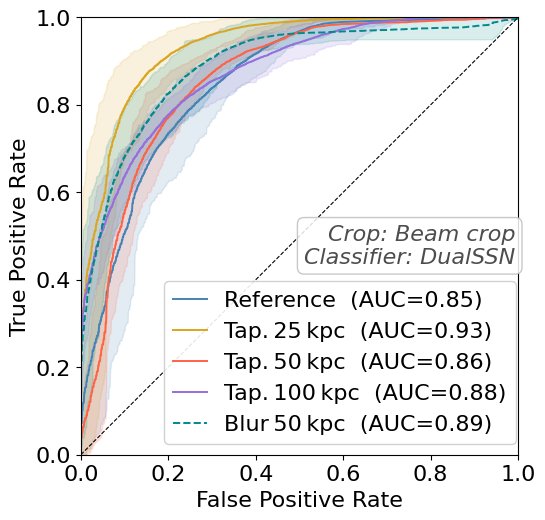

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/roc_comparison_beamcrop_DualSSN.pdf


In [23]:
# ── Define runs to compare ────────────────────────────────────────────────────
# Each entry: (label, RunConfig)  — only vary the fields you want to compare;
# everything else defaults to the script-04 defaults.

_ALL_VERSIONS = ['RAW', 'T25kpc', 'T50kpc', 'T100kpc', 'Blur50kpc']
#_ALL_CROPS = ['beam_crop', 'fov_crop', 'pixel_crop']
#_ALL_CLASSIFIERS = ['ImageCNN', 'SimpleScatterNet', 'DualCSN', 'DualSSN']

runs_to_compare = [
    (_version_display(v), RunConfig(
        crop_mode='beam_crop',
        classifier='DualSSN',
        version=v,
        folds=list(range(10)),
        num_experiments=3,
    ))
    for v in _ALL_VERSIONS
]

# ── Legend control ────────────────────────────────────────────────────────────
# 'auto' detects which dimension varies between runs (recommended).
# Override with 'crop' | 'version' | 'classifier' or a list thereof.
LEGEND_BY = 'version'


# ── Auto-build filename from fixed (shared) config fields ─────────────────────
def _roc_filename(runs):
    """Return a descriptive filename encoding the fixed dimensions of the runs."""
    cfgs = [cfg for _, cfg in runs]
    _crop_slug = {
        'beam_crop': 'beamcrop', 'beam_crop_no_sub': 'beamcrop_nosub',
        'fov_crop': 'fovcrop', 'pixel_crop': 'pixelcrop', 'cheat_crop': 'cheatchop',
    }
    parts = []
    versions   = {c.version    for c in cfgs}
    crops      = {c.crop_mode  for c in cfgs}
    clfs       = {c.classifier for c in cfgs}
    if len(versions) == 1:
        parts.append(next(iter(versions)))
    if len(crops) == 1:
        parts.append(_crop_slug.get(next(iter(crops)), next(iter(crops))))
    if len(clfs) == 1:
        parts.append(next(iter(clfs)))
    suffix = '_'.join(parts)
    return f'roc_comparison_{suffix}.pdf' if suffix else 'roc_comparison.pdf'


# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plot_comparative_roc(
    runs_to_compare,
    legend_by=LEGEND_BY,
    line_styles=['-', '-', '-', '-', '--'],   # Blur50kpc is 5th entry
)
_fname = os.path.join(OUTPUT_DIR, _roc_filename(runs_to_compare))
fig.savefig(_fname, bbox_inches='tight')
plt.show()
plt.close()
print('Saved:', _fname)

## 5. Accuracy comparison plots

Scatter + errorbar plots comparing classifier accuracy across image versions, physical scales, and crop modes. Each point shows mean ± std over 10 folds × 3 experiments. RadioUNet (Acc = 0.73) is included as a fixed reference point on all classifier-axis plots.

The first cell below defines version-string helpers and `extract_accuracy_data`, which powers the multi-scale scatter plots.

Subsections:
- **Scales 25/50/100 kpc** — all four classifiers; marker = smoothing version, colour = crop mode
- **DualSSN only** — single-panel version of the above
- **All scales incl. Reference** — adds the RAW group and a RadioUNet horizontal line
- **Reference errorbar** — classifiers on x-axis, RAW images only
- **25 kpc averaged** — pools Blur25kpc + T25kpc + T25kpcSUB (90 runs per point)
- **Stacking** — DualSSN trained on combined input versions (RAW + Blur X kpc)

In [24]:
# ── Version-string helpers ─────────────────────────────────────────────────────

def _scale_to_version(scale: int, kind: str) -> str:
    if scale == 0:
        return 'RAW'
    if kind == 'blur':
        return f'Blur{scale}kpc'
    if kind == 'tap':
        return f'T{scale}kpc'
    if kind == 'tap_sub':
        return f'T{scale}kpcSUB'
    raise ValueError(f"Unknown kind '{kind}'. Use 'blur', 'tap', or 'tap_sub'.")


def _scale_label(scale: int) -> str:
    NARROW = '\u202f'
    if scale == 0:
        return 'Reference'
    return f'{scale}{NARROW}kpc'


def _load_vals_from_cfg(cfg, metric, run=None):
    """Load metric values from a run dict, split by tier (latest / old / legacy).

    Parameters
    ----------
    cfg     : RunConfig or LegacyRunConfig
    metric  : metric name string
    run     : pre-loaded run dict (pass if already loaded to avoid double load)

    Returns
    -------
    vals_by_tier : dict with keys 'latest', 'old', 'legacy'
    n_loaded, n_failed : ints parsed from load_run stdout
    """
    if run is None:
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            run = load_run(cfg, verbose=False)
        captured = buf.getvalue()
    else:
        captured = ''

    n_loaded, n_failed = 0, 0
    for line in captured.splitlines():
        m = re.search(r'Loaded\s+(\d+)\s+pkl', line)
        if m:
            n_loaded += int(m.group(1))
        m = re.search(r'failed/missing\s+(\d+)', line)
        if m:
            n_failed += int(m.group(1))

    is_legacy    = isinstance(cfg, LegacyRunConfig)
    old_keys     = run.get('_old_keys', set())
    vals_by_tier = {'latest': [], 'old': [], 'legacy': []}

    for fold in cfg.folds:
        for exp in range(cfg.num_experiments):
            # Collect from all subset sizes present in run dict (ignore dataset_sizes)
            _suffix = f'_{fold}_{exp}_{cfg.lr}_{cfg.reg}'
            for _rk, _rv in run.items():
                if not _rk.startswith(f'{metric}_') or not _rk.endswith(_suffix):
                    continue
                new_vals = [v for v in _rv if np.isfinite(v)]
                if not new_vals:
                    continue
                k = _rk[len(f'{metric}_'):]
                if is_legacy:
                    vals_by_tier['legacy'].extend(new_vals)
                elif k in old_keys:
                    vals_by_tier['old'].extend(new_vals)
                else:
                    vals_by_tier['latest'].extend(new_vals)

    return vals_by_tier, n_loaded, n_failed

def extract_accuracy_data(
    base_cfg,
    scales:        List[int],
    scale_version: Optional[List[str]] = None,
    overlay_vary:  Optional[str] = None,
    overlay_values: Optional[list] = None,
    overlay_labels: Optional[List[str]] = None,
    metric:        str = 'accuracy',
    result_version_priority: Optional[List[str]] = None,
    classifiers:   Optional[List] = None,
    overlay_values_by_scale: Optional[dict] = None,
) -> dict:
    """
    Extract mean/std/n for a metric across multiple runs, grouped by scale and optionally by an overlay variable.

    Returns
    -------
    data : dict with keys (row_label, scale, overlay_value) →
               {'mean': float, 'std': float, 'n': int}
    """
    _priority = result_version_priority or ['latest', 'legacy', 'old']

    _blur_methods = scale_version or []
    if _blur_methods and len(_blur_methods) > 1:
        tracks = [
            ('tap',     None) if m == 'tapering'
            else ('tap_sub', None) if m == 'sub'
            else ('blur', m)
            for m in _blur_methods
        ]
    else:
        tracks = [('blur', _blur_methods[0] if _blur_methods else None)]

    _ov_vals = overlay_values if overlay_vary else [None]
    _ov_labs = (
        overlay_labels if overlay_labels is not None
        else ([_prettify(str(v)) for v in _ov_vals] if overlay_vary else [])
    )

    if classifiers:
        cfg_rows = []
        for entry in classifiers:
            if len(entry) == 3:
                cfg_rows.append((entry[0], entry[1], entry[2]))
            else:
                cfg_rows.append((entry[0], entry[1], None))
    else:
        cfg_rows = [('', base_cfg, None)]

    data = {}

    for row_label, row_cfg, row_fallback in cfg_rows:
        is_legacy_base = isinstance(row_cfg, LegacyRunConfig)

        for t_idx, (kind, method) in enumerate(tracks):
            for ov_idx, ov_val in enumerate(_ov_vals):

                if is_legacy_base and overlay_vary and ov_val is not None:
                    continue  # legacy base: skip multi-overlay rows

                for scale in scales:
                    if scale == 0 and t_idx > 0:
                        continue

                    # Per-scale overlay filter (mirrors _draw_bars)
                    if overlay_values_by_scale is not None and ov_val is not None:
                        _scale_ovs = overlay_values_by_scale.get(scale)
                        if _scale_ovs is not None and ov_val not in _scale_ovs:
                            continue

                    version = _scale_to_version(scale, kind)
                    cfg_kw  = {'version': version}
                    if method is not None:
                        cfg_kw['blur_method'] = method
                    if overlay_vary and ov_val is not None and not is_legacy_base:
                        cfg_kw[overlay_vary] = ov_val
                    cfg = dataclasses.replace(row_cfg, **cfg_kw)

                    vals_by_tier, _, _ = _load_vals_from_cfg(cfg, metric)

                    # Load legacy fallback if provided
                    if row_fallback is not None and 'legacy' in _priority:
                        if isinstance(row_fallback, dict):
                            _fb_base = row_fallback.get(ov_val)
                        else:
                            _fb_base = row_fallback
                        if _fb_base is not None:
                            fb_kw = {'version': version}
                            if method is not None:
                                fb_kw['blur_method'] = method
                            fb_cfg = dataclasses.replace(_fb_base, **fb_kw)
                            fb_vals, _, _ = _load_vals_from_cfg(fb_cfg, metric)
                            vals_by_tier['legacy'].extend(fb_vals['legacy'])

                    # Pick winning tier (same logic as _draw_bars)
                    available = [t for t in ('latest', 'old', 'legacy') if vals_by_tier[t]]
                    if _priority == ['highest']:
                        tier = max(available, key=lambda t: float(np.mean(vals_by_tier[t]))) if available else None
                    else:
                        tier = next((t for t in _priority if t in available), None)
                    if tier is None:
                        continue

                    arr  = np.array(vals_by_tier[tier], dtype=float)                   
                    ov_label     = _ov_labs[ov_idx] if _ov_labs else str(ov_val)
                    # Map kind → display label matching VERSION_DISPLAY in the plot
                    kind_display = {'blur': 'Blur', 'tap': 'Tap.', 'tap_sub': 'Sub.'}.get(kind, kind)
                    key  = (row_label, scale, ov_label, kind_display)
                    data[key] = {
                        'mean':      float(arr.mean()),
                        'std':       float(arr.std()),
                        'n':         int(arr.size),
                        'ov_val':    ov_val,      # raw value (e.g. 'beam_crop')
                        'ov_label':  ov_label,    # display label (e.g. 'Beam crop')
                        'version':   version,
                        'classifier': row_label,
                    }

    return data


def _prettify(label: str) -> str:
    _map = {
        'fov_crop':         'FoV crop',
        'beam_crop':        'Beam crop',
        'pixel_crop':       'Pixel crop',
        'circular':         'Blur',
        'circular_no_sub':  'Blur (no sub)',
        'tapering':         'Tap.',
        'sub':              'Sub.',
        'cheat':            'Cheat',
        'crop_mode':        'Crop mode',
        'blur_method':      'Blur method',
        'version':          'Version',
    }
    return _map.get(label, label)

### Accuracy scatter — scales 25/50/100 kpc
Marker = image version (Blur/Tap/Sub); colour = crop mode.

Saved to /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/accuracy_comparison.pdf


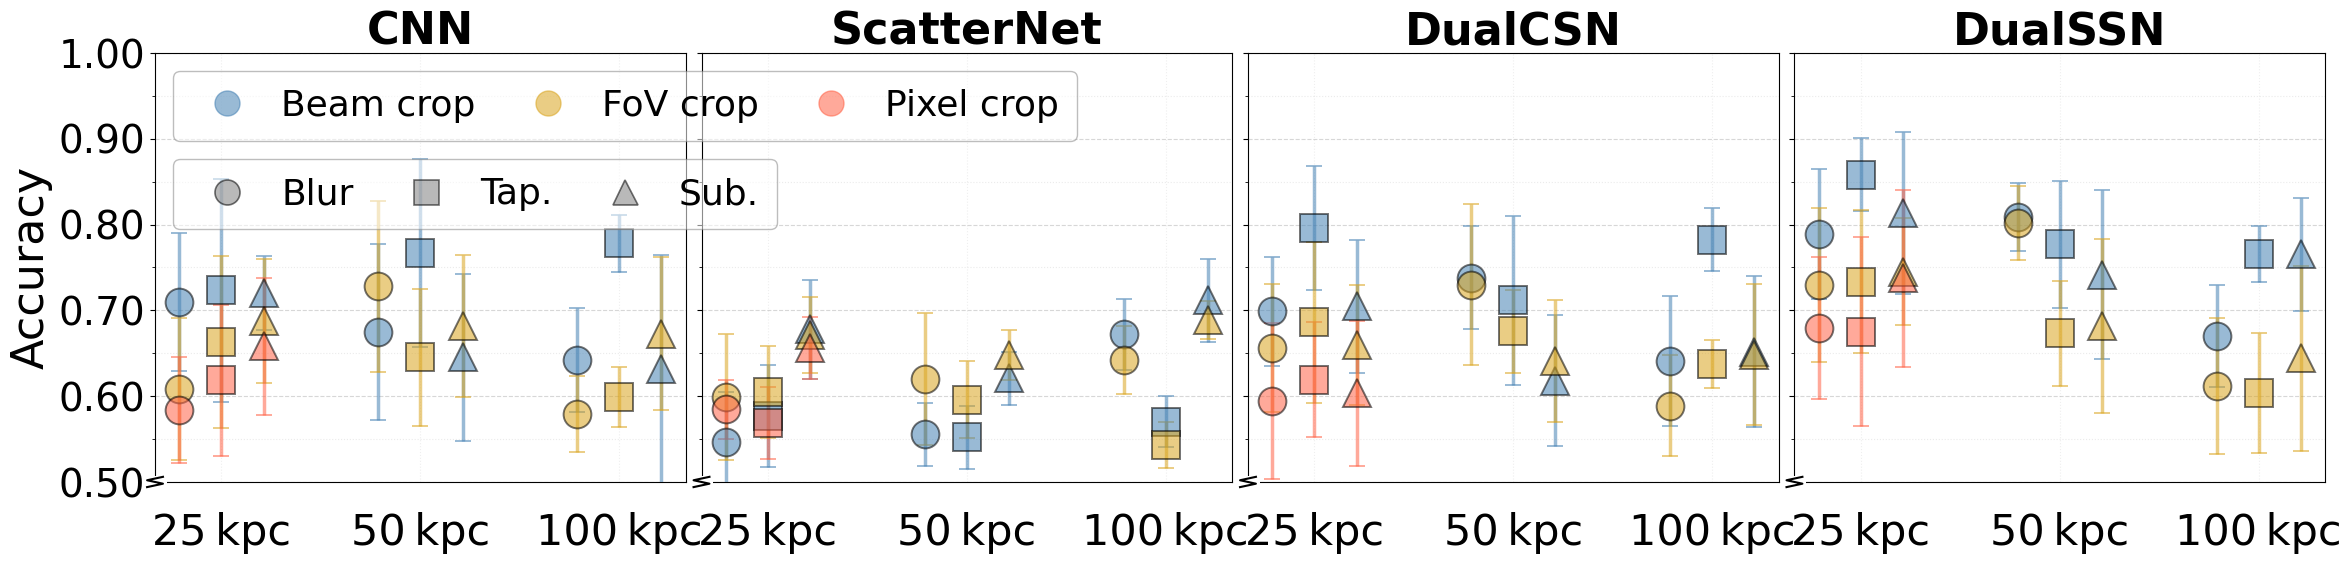

In [25]:
# ── Y-AXIS RANGE ──────────────────────────────────────────────────────────────
Y_MIN = 0.50
Y_MAX = 1.00

# ── OUTPUT ────────────────────────────────────────────────────────────────────
SAVE_PATH = os.path.join(OUTPUT_DIR, 'accuracy_comparison.pdf')

# ── CROP MODES AVAILABLE PER SCALE ────────────────────────────────────────────
# pixel_crop only ran at 25 kpc; 50 and 100 kpc have beam_crop + fov_crop only
OVERLAY_VALUES_BY_SCALE = {25:  ['beam_crop', 'fov_crop', 'pixel_crop'],
                            50:  ['beam_crop', 'fov_crop'],
                            100: ['beam_crop', 'fov_crop']}

# ── MARKER PER SMOOTHING VERSION ──────────────────────────────────────────────
VERSION_MARKERS = {
    'Blur': 'o',
    'Tap.': 's',
    'Sub.': '^',
}

# ── COLOUR PER CROP MODE ──────────────────────────────────────────────────────
CROP_COLOURS = {
    'Beam crop':  'steelblue',
    'FoV crop':   'goldenrod',
    'Pixel crop': 'tomato',
}
DEFAULT_COLOUR = 'grey'

# ── ZIGZAG BREAK ON Y-AXIS ────────────────────────────────────────────────────
def draw_yaxis_break(ax, y_break=0.0, width=0.015, height=0.012,
                     color='white', lcolor='black'):
    x0 = 0.0
    zx = [x0 - width, x0 + width, x0 - width, x0 + width]
    zy = [y_break - height, y_break - height/3,
          y_break + height/3, y_break + height]
    ax.add_patch(plt.matplotlib.patches.FancyBboxPatch(
        (x0 - width*1.5, y_break - height*1.2), width*3, height*2.4,
        boxstyle='square,pad=0', transform=ax.transAxes, clip_on=False,
        facecolor=color, edgecolor='none', zorder=4,
    ))
    ax.plot(zx, zy, transform=ax.transAxes, clip_on=False,
            color=lcolor, linewidth=1.5, zorder=5)

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
acc_data = extract_accuracy_data(
    base_cfg              = None,
    scales                = [25, 50, 100],
    scale_version         = ['circular', 'tapering', 'sub'],
    overlay_vary          = 'crop_mode',
    overlay_values        = ['beam_crop', 'fov_crop', 'pixel_crop'],
    metric                = 'accuracy',
    result_version_priority = ['latest'],
    overlay_values_by_scale = OVERLAY_VALUES_BY_SCALE,
    classifiers = [
        ('CNN',
            RunConfig(classifier='ImageCNN', folds=list(range(10)), num_experiments=3)),
        ('ScatterNet',
            RunConfig(classifier='SimpleScatterNet', folds=list(range(10)), num_experiments=3),
            {}),
        ('DualCSN',
            RunConfig(classifier='DualCSN', folds=list(range(10)), num_experiments=3),
            {'beam_crop': LegacyRunConfig(classifier='DualCSN', section='beam_cropping',
                                          folds=list(range(10)), num_experiments=3)}),
        ('DualSSN',
            RunConfig(classifier='DualSSN', folds=list(range(10)), num_experiments=3),
            {'beam_crop': LegacyRunConfig(classifier='DualSSN', section='beam_cropping',
                                          folds=list(range(10)), num_experiments=3)}),
    ],
)

# ── VERSION → X-INDEX ─────────────────────────────────────────────────────────
VERSION_DISPLAY = ['Blur', 'Tap.', 'Sub.']
_VER_IDX = {v: i for i, v in enumerate(VERSION_DISPLAY)}

def _version_to_idx(version_str):
    return _VER_IDX.get(version_str, 0)

# ── X-AXIS LAYOUT ─────────────────────────────────────────────────────────────
SCALES      = [25, 50, 100]
CLASSIFIERS = ['CNN', 'ScatterNet', 'DualCSN', 'DualSSN']
N_VER       = 3
GROUP_W     = 7.0
VER_STEP    = GROUP_W / N_VER   # 3.0
scale_x     = {s: i * 11.0 for i, s in enumerate(SCALES)}  # 0, 11.0, 22.0

# ── PLOT: 4 subplots, one per classifier ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(28, 6.5), sharey=True)

for ax, clf_label in zip(axes, CLASSIFIERS):
    for (key_clf, scale, ov_label, version), vals in acc_data.items():
        if key_clf != clf_label or scale not in scale_x:
            continue
        marker  = VERSION_MARKERS.get(version, 'o')
        colour  = CROP_COLOURS.get(ov_label, DEFAULT_COLOUR)
        ver_idx = _version_to_idx(version)
        x       = scale_x[scale] + VER_STEP * (ver_idx - (N_VER - 1) / 2)

        ax.errorbar(
            x, vals['mean'], yerr=vals['std'],
            fmt=marker, color=colour,
            markersize=20, markeredgewidth=1.4, markeredgecolor='black',
            ecolor=colour, elinewidth=2.5, capsize=6, alpha=0.55, zorder=3,
        )

    # ── Y-AXIS ────────────────────────────────────────────────────────────────
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.10))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis='y', labelsize=28)
    if ax is axes[0]:
        ax.set_ylabel('Accuracy', fontsize=32)
    draw_yaxis_break(ax, y_break=0.0)

    # ── X-AXIS: kpc labels ────────────────────────────────────────────────────
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.set_xticks([scale_x[s] for s in SCALES])
    ax.set_xticklabels([])

    NARROW = '\u202f'
    for s in SCALES:
        ax.text(scale_x[s], -0.07, f'{s}{NARROW}kpc',
                ha='center', va='top', fontsize=31,
                transform=trans, clip_on=False)

    # ── STYLE ─────────────────────────────────────────────────────────────────
    ax.set_title(clf_label, fontsize=32, fontweight='bold')
    ax.tick_params(axis='x', which='both', length=0)
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.5)
    ax.grid(axis='y', which='minor', linestyle=':', alpha=0.25)
    ax.grid(axis='x', linestyle=':', alpha=0.2)

# ── LEGENDS: crop mode (colours) + smoothing version (shapes) ─────────────────
# Both legends use fig.transFigure so their x-anchors are in the same coordinate
# system, guaranteeing left-edge alignment.
LEG_KW = dict(ncol=3, fontsize=26, framealpha=0.55, edgecolor='#888888',
              handletextpad=0.5, columnspacing=1.0, borderpad=0.5)

legend_crop = [
    Line2D([0], [0], marker='o', color=col, linestyle='None',
           markersize=18, alpha=0.55, label=name)
    for name, col in CROP_COLOURS.items()
]
legend_ver = [
    Line2D([0], [0], marker=mk, color='grey', linestyle='None',
           markersize=18, markeredgewidth=1.2, markeredgecolor='black', alpha=0.55, label=ver)
    for ver, mk in VERSION_MARKERS.items()
]

plt.subplots_adjust(wspace=0.03, bottom=0.22)

fig.canvas.draw()
renderer  = fig.canvas.get_renderer()
_ax0_pos  = axes[0].get_position()
_leg_x    = _ax0_pos.x0   # left edge of axes[0] in figure coords
_leg_y1   = _ax0_pos.y1   # top edge of axes[0] in figure coords

leg1 = axes[0].legend(handles=legend_crop, loc='upper left',
                      bbox_to_anchor=(_leg_x, _leg_y1),
                      bbox_transform=fig.transFigure, **LEG_KW)
leg1.remove()
fig.add_artist(leg1)

# Measure leg1 to position leg2 flush below it
fig.canvas.draw()
bb       = leg1.get_window_extent(renderer)
_leg_y2  = fig.transFigure.inverted().transform((0, bb.y0))[1]

leg2 = axes[0].legend(handles=legend_ver, loc='upper left',
                      bbox_to_anchor=(_leg_x, _leg_y2),
                      bbox_transform=fig.transFigure, **LEG_KW)
leg2.remove()
fig.add_artist(leg2)

fig.savefig(SAVE_PATH, bbox_inches='tight')
print(f'Saved to {SAVE_PATH}')
plt.show()

### Accuracy scatter — DualSSN only
Same as above but a single panel showing only DualSSN results.

Saved to /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/accuracy_comparison_dualssn.pdf


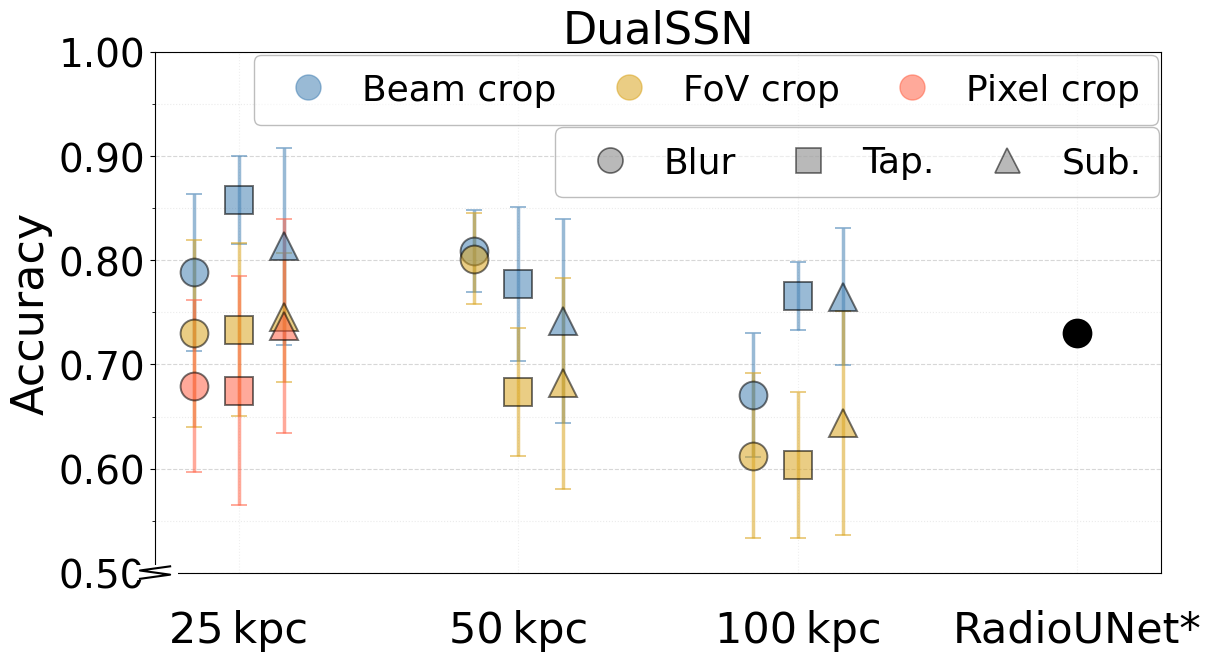

In [26]:
# ── Accuracy scatter — DualSSN only ──────────────────────────────────────────

RADIOUNET_VALUE_REF = 0.73
SAVE_PATH_DUALSSN = os.path.join(OUTPUT_DIR, 'accuracy_comparison_dualssn.pdf')

# Wider figure to accommodate RadioUNet* point and give more breathing room
fig_ds, ax_ds = plt.subplots(figsize=(12, 6.5), constrained_layout=True)

# Structured spacing (same philosophy as reference plot)
N_VER        = len(VERSION_MARKERS)
GROUP_WIDTH  = 2.4
STEP         = GROUP_WIDTH / N_VER

scale_x = {s: i * 5.0 for i, s in enumerate(SCALES)}

for (key_clf, scale, ov_label, version), vals in acc_data.items():
    if key_clf != 'DualSSN' or scale not in scale_x:
        continue
    marker  = VERSION_MARKERS.get(version, 'o')
    colour  = CROP_COLOURS.get(ov_label, DEFAULT_COLOUR)
    ver_idx = _version_to_idx(version)
    x       = scale_x[scale] + STEP * (ver_idx - (N_VER - 1) / 2)

    ax_ds.errorbar(
        x, vals['mean'], yerr=vals['std'],
        fmt=marker, color=colour,
        markersize=20, markeredgewidth=1.4, markeredgecolor='black',
        ecolor=colour, elinewidth=2.5, capsize=6, alpha=0.55, zorder=3,
    )
    

# ── RadioUNet* reference point ────────────────────────────────────────────────
# Placed one full group-spacing to the right of the last kpc scale tick.
# The spacing mirrors how reference_accuracy_scatter.pdf handles it (5.0 units).
_last_scale_x = scale_x[SCALES[-1]]
_radio_x_ds   = _last_scale_x + 5.0

ax_ds.errorbar(
    _radio_x_ds, RADIOUNET_VALUE_REF,
    fmt='o', color='black',
    markersize=20, markeredgewidth=1.4, markeredgecolor='black',
    linestyle='none', zorder=4, label='_nolegend_',
)

# ── Y-axis ────────────────────────────────────────────────────────────────────
ax_ds.set_ylim(Y_MIN, Y_MAX)
ax_ds.yaxis.set_major_locator(ticker.MultipleLocator(0.10))
ax_ds.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax_ds.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax_ds.tick_params(axis='y', labelsize=28)
ax_ds.set_ylabel('Accuracy', fontsize=32)
draw_yaxis_break(ax_ds, y_break=0.0)

# ── X-axis: kpc labels + RadioUNet* ───────────────────────────────────────────
trans_ds = blended_transform_factory(ax_ds.transData, ax_ds.transAxes)

# Regular kpc ticks (no tick marks; labels drawn manually below the axis)
_all_xticks  = [scale_x[s] for s in SCALES] + [_radio_x_ds]
ax_ds.set_xticks(_all_xticks)
ax_ds.set_xticklabels([])

NARROW = '\u202f'
for s in SCALES:
    ax_ds.text(scale_x[s], -0.07, f'{s}{NARROW}kpc',
               ha='center', va='top', fontsize=31,
               transform=trans_ds, clip_on=False)

# RadioUNet* label uses the same style and vertical position as the kpc labels
ax_ds.text(_radio_x_ds, -0.07, 'RadioUNet*',
           ha='center', va='top', fontsize=31,
           transform=trans_ds, clip_on=False)

# ── X-axis limits: include RadioUNet* with symmetric margin ───────────────────
_x_margin = 1.5
ax_ds.set_xlim(scale_x[SCALES[0]] - _x_margin, _radio_x_ds + _x_margin)

# ── Style ─────────────────────────────────────────────────────────────────────
ax_ds.set_title('DualSSN', fontsize=32)
ax_ds.tick_params(axis='x', which='both', length=0)
ax_ds.grid(axis='y', which='major', linestyle='--', alpha=0.5)
ax_ds.grid(axis='y', which='minor', linestyle=':', alpha=0.25)
ax_ds.grid(axis='x', linestyle=':', alpha=0.2)

# ── Legends ───────────────────────────────────────────────────────────────────
LEG_KW_DS = dict(ncol=3, fontsize=26, framealpha=0.55, edgecolor='#888888',
                 handletextpad=0.5, columnspacing=1.0, borderpad=0.5)

legend_crop_ds = [
    Line2D([0], [0], marker='o', color=col, linestyle='None',
           markersize=18, alpha=0.55, label=name)
    for name, col in CROP_COLOURS.items()
]
legend_ver_ds = [
    Line2D([0], [0], marker=mk, color='grey', linestyle='None',
           markersize=18, markeredgewidth=1.2, markeredgecolor='black',
           alpha=0.55, label=ver)
    for ver, mk in VERSION_MARKERS.items()
]


dx = 0.08   # move right
dy = 0.03   # move up

leg1_ds = ax_ds.legend(handles=legend_crop_ds, loc='upper left',
                       bbox_to_anchor=(dx, 1 + dy),
                       bbox_transform=ax_ds.transAxes,
                       **LEG_KW_DS)

ax_ds.add_artist(leg1_ds)

fig_ds.canvas.draw()
renderer_ds = fig_ds.canvas.get_renderer()
bb_ds    = leg1_ds.get_window_extent(renderer_ds)
bb_ax_ds = bb_ds.transformed(ax_ds.transAxes.inverted())

leg2_ds = ax_ds.legend(handles=legend_ver_ds, loc='upper left',
                       bbox_to_anchor=(dx+0.3, bb_ax_ds.y0 + dy),
                       bbox_transform=ax_ds.transAxes,
                       **LEG_KW_DS)

fig_ds.savefig(SAVE_PATH_DUALSSN, bbox_inches='tight')
print(f'Saved to {SAVE_PATH_DUALSSN}')
plt.show()

### Accuracy scatter — all scales including Reference
Same as above but adds the RAW (Reference, scale = 0) group on the left.

### Reference accuracy — errorbar style
Scatter + errorbar plot for RAW (Reference) images: classifiers on the x-axis, crop mode as colour, RadioUNet as a black reference point on the right.

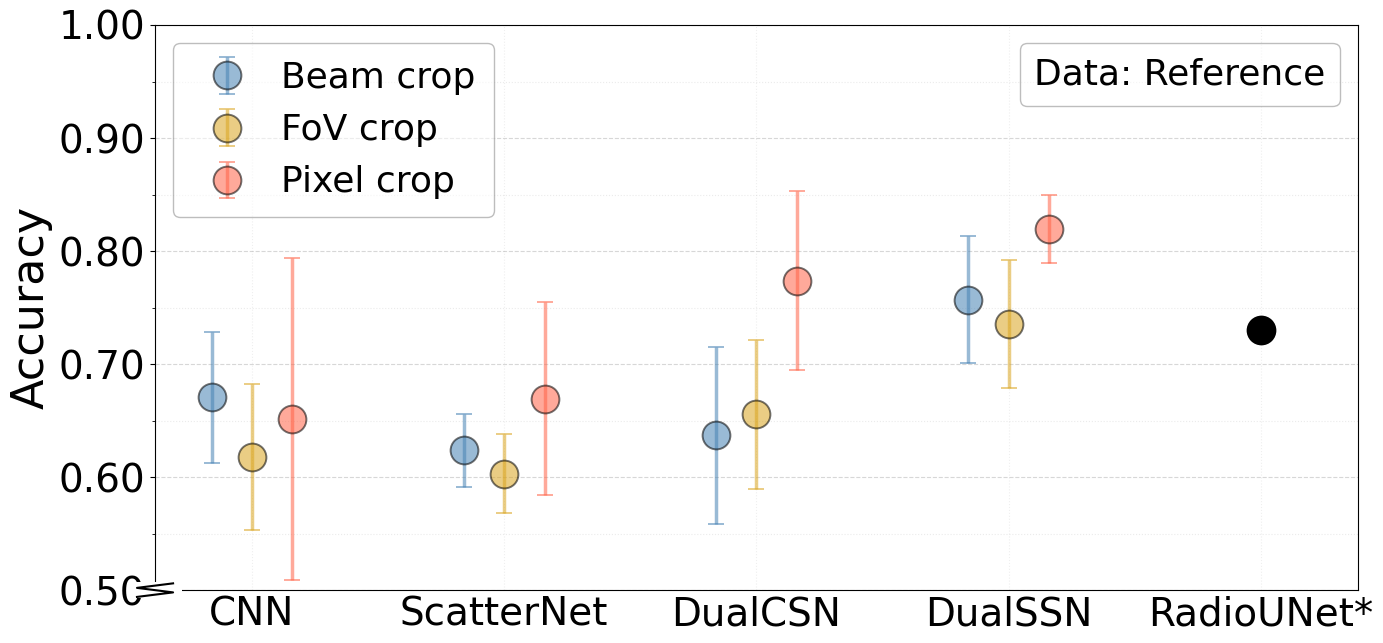

Saved to /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/reference_accuracy_scatter.pdf


In [27]:
# ── Reference (RAW) accuracy — scatter/errorbar style ─────────────────────────
# X-axis: classifier   Colour: crop mode
# Analogous to accuracy_comparison.pdf (same marker/font/break style).

RADIOUNET_VALUE_REF = 0.73
RESULT_VERSION_PRIORITY = ['latest']


_ref2_clfs = [
    ('CNN',
     RunConfig(classifier='ImageCNN',         folds=list(range(10)), num_experiments=3),
     {'beam_crop': LegacyRunConfig(classifier='CNN',    section='beam_cropping')}),
    ('ScatterNet',
     RunConfig(classifier='SimpleScatterNet', folds=list(range(10)), num_experiments=3),
     {}),
    ('DualCSN',
     RunConfig(classifier='DualCSN',          folds=list(range(10)), num_experiments=3),
     {'beam_crop': LegacyRunConfig(classifier='DualCSN', section='beam_cropping')}),
    ('DualSSN',
     RunConfig(classifier='DualSSN',          folds=list(range(10)), num_experiments=3),
     {'beam_crop': LegacyRunConfig(classifier='DualSSN', section='beam_cropping')}),
]

_ref2_crops   = ['beam_crop',  'fov_crop',  'pixel_crop']
_ref2_labels  = ['Beam crop',  'FoV crop',  'Pixel crop']
_ref2_colours = ['steelblue',  'goldenrod', 'tomato']

# X-axis: classifiers at integer positions; crops offset within each group
_ref2_n_sub   = len(_ref2_crops)
_ref2_group_w = 2.4
_ref2_step    = _ref2_group_w / _ref2_n_sub
_ref2_clf_x   = {lbl: i * 5.0 for i, (lbl, *_) in enumerate(_ref2_clfs)}

fig_ref2, ax_ref2 = plt.subplots(figsize=(14, 6.5))

for clf_label, base_cfg, fallbacks in _ref2_clfs:
    for ci, (crop, crop_lbl, colour) in enumerate(
            zip(_ref2_crops, _ref2_labels, _ref2_colours)):

        _cfg_v = dataclasses.replace(base_cfg, version='RAW', crop_mode=crop)
        _vbt, _, _ = _load_vals_from_cfg(_cfg_v, 'accuracy')

        if fallbacks and crop in fallbacks:
            _fb_vbt, _, _ = _load_vals_from_cfg(
                dataclasses.replace(fallbacks[crop], version='RAW'), 'accuracy')
            _vbt['legacy'].extend(_fb_vbt['legacy'])

        _avail = [t for t in ('latest', 'old', 'legacy') if _vbt[t]]
        _tier  = next((t for t in RESULT_VERSION_PRIORITY if t in _avail), None)
        if _tier is None:
            continue
        _arr = np.array(_vbt[_tier], dtype=float)
        _arr = _arr[np.isfinite(_arr)]

        _off = _ref2_step * (ci - (_ref2_n_sub - 1) / 2)
        ax_ref2.errorbar(
            _ref2_clf_x[clf_label] + _off, _arr.mean(), yerr=_arr.std(),
            fmt='o', color=colour,
            markersize=20, markeredgewidth=1.4, markeredgecolor='black',
            ecolor=colour, elinewidth=2.5, capsize=6, alpha=0.55, zorder=3,
            label=crop_lbl if clf_label == _ref2_clfs[0][0] else '_nolegend_',
        )

# ── X-axis tick positions (needed before RadioUNet placement) ──────────────────
_ref2_xticks = [_ref2_clf_x[lbl] for lbl, *_ in _ref2_clfs]

# ── RadioUNet as a separate "classifier" (black dot, excluded from legend) ─────
_radio_x = _ref2_xticks[-1] + 5.0

ax_ref2.errorbar(
    _radio_x, RADIOUNET_VALUE_REF,
    fmt='o', color='black',
    markersize=20, markeredgewidth=1.4, markeredgecolor='black',
    linestyle='none',
    zorder=4,
    label='_nolegend_'
)

# ── Y-axis ─────────────────────────────────────────────────────────────────────
ax_ref2.set_ylim(Y_MIN, Y_MAX)
ax_ref2.yaxis.set_major_locator(ticker.MultipleLocator(0.10))
ax_ref2.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax_ref2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax_ref2.tick_params(axis='y', labelsize=28)
ax_ref2.set_ylabel('Accuracy', fontsize=32)
draw_yaxis_break(ax_ref2, y_break=0.0)

# ── X-axis ─────────────────────────────────────────────────────────────────────
_ref2_xticks      = _ref2_xticks + [_radio_x]
_ref2_xticklabels = [lbl for lbl, *_ in _ref2_clfs] + ['RadioUNet*']
ax_ref2.set_xticks(_ref2_xticks)
ax_ref2.set_xticklabels(_ref2_xticklabels, fontsize=28)
ax_ref2.tick_params(axis='x', which='both', length=0)

# ── Grid / style ───────────────────────────────────────────────────────────────
ax_ref2.grid(axis='y', which='major', linestyle='--', alpha=0.5)
ax_ref2.grid(axis='y', which='minor', linestyle=':', alpha=0.25)
ax_ref2.grid(axis='x', linestyle=':', alpha=0.2)

_x_margin = _ref2_group_w * 0.8
ax_ref2.set_xlim(_ref2_xticks[0] - _x_margin, _radio_x + _x_margin)

# ── Legends ────────────────────────────────────────────────────────────────────
_h2, _l2 = ax_ref2.get_legend_handles_labels()

# Crop-mode legend (top left) — kept alive with add_artist
_leg_crops = ax_ref2.legend(_h2, _l2, fontsize=26, framealpha=0.55,
                            edgecolor='#888888', loc='upper left',
                            handletextpad=0.5, borderpad=0.5)
ax_ref2.add_artist(_leg_crops)

# Dataset label legend (top right) — invisible handle, text only
ax_ref2.legend(
    [plt.Line2D([0], [0], linestyle='none')],
    ['Data: Reference'],
    fontsize=26, framealpha=0.55, edgecolor='#888888',
    loc='upper right', handlelength=0, handletextpad=0
)

fig_ref2.tight_layout()
_fname_ref2 = os.path.join(OUTPUT_DIR, 'reference_accuracy_scatter.pdf')
fig_ref2.savefig(_fname_ref2, bbox_inches='tight')
plt.show()
print(f'Saved to {_fname_ref2}')

### 25 kpc accuracy — smoothing versions averaged, errorbar style
Like the Reference errorbar plot but for 25 kpc; each point pools Blur25kpc + T25kpc + T25kpcSUB (90 runs = 3 × 30).

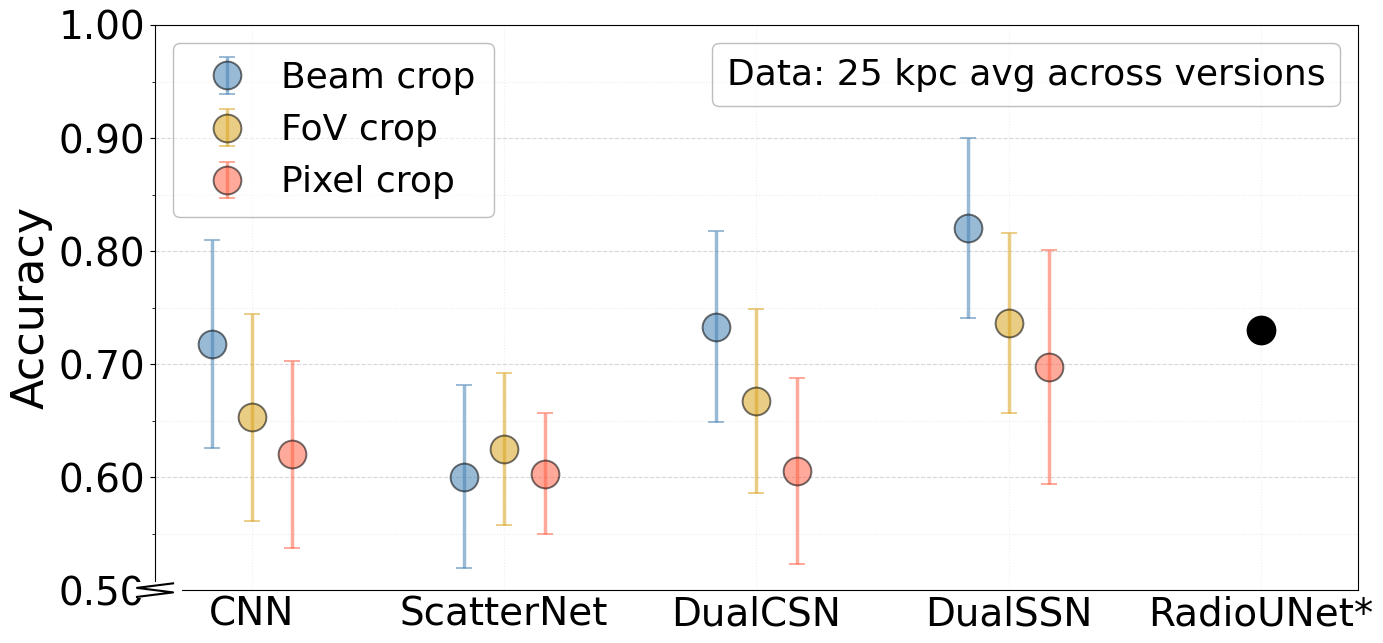

Saved to /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/25kpc_accuracy_avg_scatter.pdf


In [28]:
# ── 25 kpc accuracy — all smoothing versions averaged — errorbar style ─────────
# X-axis: classifier   Colour: crop mode
# Each point pools Blur25kpc + T25kpc + T25kpcSUB → 90 runs per point.

RESULT_VERSION_PRIORITY = ['latest']

_25k_versions = ['Blur25kpc', 'T25kpc', 'T25kpcSUB']

_25k_clfs = [
    ('CNN',
     RunConfig(classifier='ImageCNN',         folds=list(range(10)), num_experiments=3),
     {}),
    ('ScatterNet',
     RunConfig(classifier='SimpleScatterNet', folds=list(range(10)), num_experiments=3),
     {}),
    ('DualCSN',
     RunConfig(classifier='DualCSN',          folds=list(range(10)), num_experiments=3),
     {}),
    ('DualSSN',
     RunConfig(classifier='DualSSN',          folds=list(range(10)), num_experiments=3),
     {}),
]

_25k_crops   = ['beam_crop', 'fov_crop', 'pixel_crop']
_25k_labels  = ['Beam crop', 'FoV crop', 'Pixel crop']
_25k_colours = ['steelblue', 'goldenrod', 'tomato']

_25k_n_sub   = len(_25k_crops)
_25k_group_w = 2.4
_25k_step    = _25k_group_w / _25k_n_sub
_25k_clf_x   = {lbl: i * 5.0 for i, (lbl, *_) in enumerate(_25k_clfs)}

fig_25k, ax_25k = plt.subplots(figsize=(14, 6.5))

for clf_label, base_cfg, _ in _25k_clfs:
    for ci, (crop, crop_lbl, colour) in enumerate(
            zip(_25k_crops, _25k_labels, _25k_colours)):

        _all_vals = []
        for ver in _25k_versions:
            _cfg_v = dataclasses.replace(base_cfg, version=ver, crop_mode=crop)
            _vbt, _, _ = _load_vals_from_cfg(_cfg_v, 'accuracy')
            _avail = [t for t in ('latest', 'old', 'legacy') if _vbt[t]]
            _tier  = next((t for t in RESULT_VERSION_PRIORITY if t in _avail), None)
            if _tier is not None:
                _all_vals.extend(_vbt[_tier])

        if not _all_vals:
            continue

        _arr = np.array(_all_vals, dtype=float)
        _arr = _arr[np.isfinite(_arr)]

        _off = _25k_step * (ci - (_25k_n_sub - 1) / 2)
        ax_25k.errorbar(
            _25k_clf_x[clf_label] + _off, _arr.mean(), yerr=_arr.std(),
            fmt='o', color=colour,
            markersize=20, markeredgewidth=1.4, markeredgecolor='black',
            ecolor=colour, elinewidth=2.5, capsize=6, alpha=0.55, zorder=3,
            label=crop_lbl if clf_label == _25k_clfs[0][0] else '_nolegend_',
        )

# ── X-axis tick positions (needed before RadioUNet placement) ─────────────────
_25k_xticks = [_25k_clf_x[lbl] for lbl, *_ in _25k_clfs]

# ── RadioUNet as a separate "classifier" (black dot, excluded from legend) ─────
_25k_radio_x = _25k_xticks[-1] + 5.0
ax_25k.errorbar(
    _25k_radio_x, RADIOUNET_VALUE_REF,
    fmt='o', color='black',
    markersize=20, markeredgewidth=1.4, markeredgecolor='black',
    linestyle='none', zorder=4, label='_nolegend_',
)

# ── Y-axis ─────────────────────────────────────────────────────────────────────
ax_25k.set_ylim(Y_MIN, Y_MAX)
ax_25k.yaxis.set_major_locator(ticker.MultipleLocator(0.10))
ax_25k.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax_25k.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax_25k.tick_params(axis='y', labelsize=28)
ax_25k.set_ylabel('Accuracy', fontsize=32)
draw_yaxis_break(ax_25k, y_break=0.0)

# ── X-axis ─────────────────────────────────────────────────────────────────────
_25k_xticks      = _25k_xticks + [_25k_radio_x]
_25k_xticklabels = [lbl for lbl, *_ in _25k_clfs] + ['RadioUNet*']
ax_25k.set_xticks(_25k_xticks)
ax_25k.set_xticklabels(_25k_xticklabels, fontsize=28)
ax_25k.tick_params(axis='x', which='both', length=0)

_x_margin = _25k_group_w * 0.8
ax_25k.set_xlim(_25k_xticks[0] - _x_margin, _25k_radio_x + _x_margin)

# ── Grid / style ──────────────────────────────────────────────────────────────
ax_25k.grid(axis='y', which='major', linestyle='--', alpha=0.5)
ax_25k.grid(axis='y', which='minor', linestyle=':', alpha=0.25)
ax_25k.grid(axis='x', linestyle=':', alpha=0.2)

# ── Legends ────────────────────────────────────────────────────────────────────
_h25k, _l25k = ax_25k.get_legend_handles_labels()

_leg_crops_25k = ax_25k.legend(_h25k, _l25k, fontsize=26, framealpha=0.55,
                               edgecolor='#888888', loc='upper left',
                               handletextpad=0.5, borderpad=0.5)
ax_25k.add_artist(_leg_crops_25k)

ax_25k.legend(
    [plt.Line2D([0], [0], linestyle='none')],
    ['Data: 25 kpc avg across versions'],
    fontsize=26, framealpha=0.55, edgecolor='#888888',
    loc='upper right', handlelength=0, handletextpad=0,
)

fig_25k.tight_layout()
_fname_25k = os.path.join(OUTPUT_DIR, '25kpc_accuracy_avg_scatter.pdf')
fig_25k.savefig(_fname_25k, bbox_inches='tight')
plt.show()
print(f'Saved to {_fname_25k}')

### Stacking results — DualSSN
DualSSN trained on two or more image versions simultaneously (e.g. RAW + Blur 25 kpc). X-axis shows the input combination; same errorbar style as the plots above.

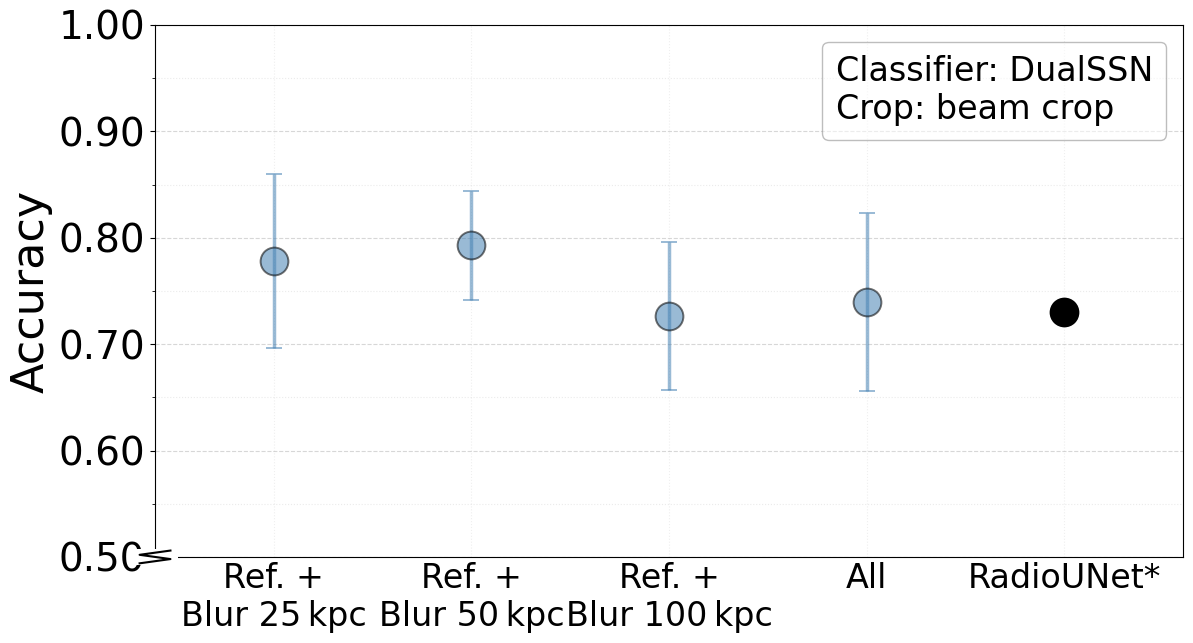

Saved to /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/accuracy_stacking_scatter.pdf


In [29]:
# ── Stacking results (DualSSN) — scatter/errorbar style ──────────────────────
# X-axis: stacking combination   Single colour: beam_crop only
# Each point: mean ± std over 10 folds × 3 experiments (30 runs).

DISTINGUISH_RESULT_VERSIONS = True
RESULT_VERSION_PRIORITY     = ['latest']

_stk_cols = [
    ('Ref. +\nBlur 25\u202fkpc',  'RAW+Blur25kpc'),
    ('Ref. +\nBlur 50\u202fkpc',  'RAW+Blur50kpc'),
    ('Ref. +\nBlur 100\u202fkpc', 'RAW+Blur100kpc'),
    ('All',                        'RAW+Blur25kpc+Blur50kpc+Blur100kpc'),
]
_stk_colour = 'steelblue'

fig_stk, ax_stk = plt.subplots(figsize=(12, 6.5))

for xi, (lbl, ver) in enumerate(_stk_cols):
    _cfg_v = RunConfig(
        classifier      = 'DualSSN',
        version         = ver,
        crop_mode       = 'beam_crop',
        folds           = list(range(10)),
        num_experiments = 3,
    )
    _vbt, _, _ = _load_vals_from_cfg(_cfg_v, 'accuracy')
    _avail = [t for t in ('latest', 'old', 'legacy') if _vbt[t]]
    _tier  = next((t for t in RESULT_VERSION_PRIORITY if t in _avail), None)
    if _tier is None:
        continue
    _arr = np.array(_vbt[_tier], dtype=float)
    _arr = _arr[np.isfinite(_arr)]

    ax_stk.errorbar(
        xi * 5.0, _arr.mean(), yerr=_arr.std(),
        fmt='o', color=_stk_colour,
        markersize=20, markeredgewidth=1.4, markeredgecolor='black',
        ecolor=_stk_colour, elinewidth=2.5, capsize=6, alpha=0.55, zorder=3,
        label='_nolegend_',
    )

# ── X-axis tick positions (needed before RadioUNet placement) ─────────────────
_stk_xticks = [i * 5.0 for i in range(len(_stk_cols))]

# ── RadioUNet as a separate point (black dot, excluded from legend) ────────────
_stk_radio_x = _stk_xticks[-1] + 5.0
ax_stk.errorbar(
    _stk_radio_x, RADIOUNET_VALUE_REF,
    fmt='o', color='black',
    markersize=20, markeredgewidth=1.4, markeredgecolor='black',
    linestyle='none', zorder=4, label='_nolegend_',
)

# ── Y-axis ────────────────────────────────────────────────────────────────────
ax_stk.set_ylim(Y_MIN, Y_MAX)
ax_stk.yaxis.set_major_locator(ticker.MultipleLocator(0.10))
ax_stk.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax_stk.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax_stk.tick_params(axis='y', labelsize=28)
ax_stk.set_ylabel('Accuracy', fontsize=32)
draw_yaxis_break(ax_stk, y_break=0.0)

# ── X-axis ────────────────────────────────────────────────────────────────────
_stk_xticks      = _stk_xticks + [_stk_radio_x]
_stk_xticklabels = [lbl for lbl, _ in _stk_cols] + ['RadioUNet*']
ax_stk.set_xticks(_stk_xticks)
ax_stk.set_xticklabels(_stk_xticklabels, fontsize=24)
ax_stk.tick_params(axis='x', which='both', length=0)

_stk_margin = 3.0
ax_stk.set_xlim(_stk_xticks[0] - _stk_margin, _stk_radio_x + _stk_margin)

# ── Grid / style ──────────────────────────────────────────────────────────────
ax_stk.grid(axis='y', which='major', linestyle='--', alpha=0.5)
ax_stk.grid(axis='y', which='minor', linestyle=':', alpha=0.25)
ax_stk.grid(axis='x', linestyle=':', alpha=0.2)

# ── Dataset label (top right) ─────────────────────────────────────────────────
ax_stk.legend(
    [plt.Line2D([0], [0], linestyle='none')],
    ['Classifier: DualSSN\nCrop: beam crop'],
    fontsize=24, framealpha=0.55, edgecolor='#888888',
    loc='upper right', handlelength=0, handletextpad=0,
)

fig_stk.tight_layout()
_fname_stk = os.path.join(OUTPUT_DIR, 'accuracy_stacking_scatter.pdf')
fig_stk.savefig(_fname_stk, bbox_inches='tight')
plt.show()
print(f'Saved to {_fname_stk}')

## 6. Learning curve
Accuracy vs training-set size for a single classifier / version / crop mode. Uses `load_run` auto-discovery, so any subset sizes present on disk are included. Edit the `LC_*` constants at the top of the cell to change the run.

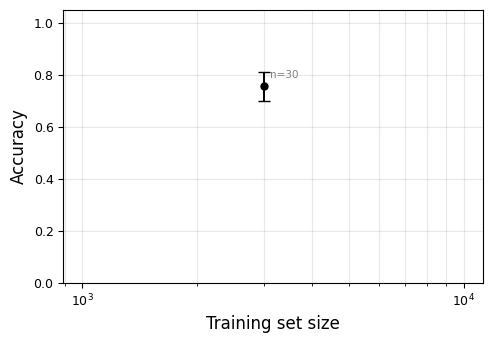

DualSSN  |  RAW  |  beam_crop
Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/learning_curve.pdf

    SS    mean     std     n
  3000  0.7570  0.0564    30


In [30]:
# ── Learning curve ────────────────────────────────────────────────────────────

LC_CLASSIFIER      = 'DualSSN'
LC_VERSION         = 'RAW'
LC_CROP_MODE       = 'beam_crop'
LC_FOLDS           = list(range(10))
LC_NUM_EXPERIMENTS = 3

_lc_cfg = RunConfig(
    classifier      = LC_CLASSIFIER,
    version         = LC_VERSION,
    crop_mode       = LC_CROP_MODE,
    folds           = LC_FOLDS,
    num_experiments = LC_NUM_EXPERIMENTS,
)
with _ctx.redirect_stdout(_io.StringIO()):
    _lc_run = load_run(_lc_cfg, verbose=False)
_old_keys = _lc_run.get('_old_keys', set())

# Discover all subset sizes present in the run dict
_all_ss = sorted({int(_m.group(1))
                  for _k in _lc_run
                  for _m in [_re.match(r'accuracy_(\d+)_\d+_\d+_', _k)]
                  if _m})

# Collect per-ss accuracy values (latest tier only)
_lc_vals = _dd(list)
for _ss in _all_ss:
    for _fold in LC_FOLDS:
        for _exp in range(LC_NUM_EXPERIMENTS):
            _k = f'{_ss}_{_fold}_{_exp}_{_lc_cfg.lr}_{_lc_cfg.reg}'
            if _k in _old_keys:
                continue
            _lc_vals[_ss].extend([v for v in _lc_run.get(f'accuracy_{_k}', [])
                                   if np.isfinite(v)])

_ss_sorted = [s for s in _all_ss if _lc_vals[s]]
_means = [np.mean(_lc_vals[s]) for s in _ss_sorted]
_stds  = [np.std( _lc_vals[s]) for s in _ss_sorted]
_ns    = [len(   _lc_vals[s]) for s in _ss_sorted]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_lc, ax_lc = plt.subplots(figsize=(5, 3.5))
ax_lc.errorbar(_ss_sorted, _means, yerr=_stds,
               fmt='o-', capsize=4, linewidth=1.4, markersize=5,
               color='black', ecolor='black', capthick=1)
ax_lc.set_xscale('log')
ax_lc.set_xlabel('Training set size', fontsize=12)
ax_lc.set_ylabel('Accuracy', fontsize=12)
ax_lc.set_ylim(0, 1.05)
ax_lc.grid(True, which='both', alpha=0.3)
for _ss, _m, _n in zip(_ss_sorted, _means, _ns):
    ax_lc.annotate(f'n={_n}', (_ss, _m), textcoords='offset points',
                   xytext=(4, 6), fontsize=7.5, color='grey')
fig_lc.tight_layout()
_fname = os.path.join(OUTPUT_DIR, 'learning_curve.pdf')
fig_lc.savefig(_fname, bbox_inches='tight')
plt.show()
plt.close()
print(f'{LC_CLASSIFIER}  |  {LC_VERSION}  |  {LC_CROP_MODE}')
print('Saved:', _fname)
print(f'\n{"SS":>6}  {"mean":>6}  {"std":>6}  {"n":>4}')
for _ss, _m, _s, _n in zip(_ss_sorted, _means, _stds, _ns):
    print(f'{_ss:>6}  {_m:.4f}  {_s:.4f}  {_n:>4}')

## 7. Noise robustness sweep
Accuracy mean ± std as a function of injected Gaussian noise level. Edit the `NS_*` constants at the top of the cell to change the classifier / version / crop mode.

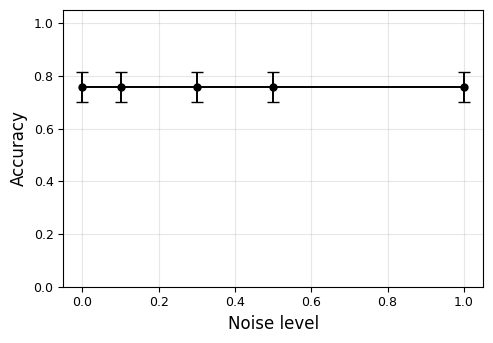

DualSSN | RAW | beam_crop | noise robustness
Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/noise_sweep.pdf

    NL    mean     std     n
  0.00  0.7570  0.0564    30
  0.10  0.7570  0.0564    30
  0.30  0.7570  0.0564    30
  0.50  0.7570  0.0564    30
  1.00  0.7570  0.0564    30


In [31]:
# ── Noise robustness sweep ────────────────────────────────────────────────────

NOISE_LEVELS = [0.0, 0.1, 0.3, 0.5, 1.0]

NS_CLASSIFIER      = 'DualSSN'
NS_VERSION         = 'RAW'
NS_CROP_MODE       = 'beam_crop'
NS_FOLDS           = list(range(10))
NS_NUM_EXPERIMENTS = 3

# Build one RunConfig per noise level (same everything else)
_ns_cfgs = [
    RunConfig(
        classifier      = NS_CLASSIFIER,
        version         = NS_VERSION,
        crop_mode       = NS_CROP_MODE,
        folds           = NS_FOLDS,
        num_experiments = NS_NUM_EXPERIMENTS,
        noise_level     = nl,
    )
    for nl in NOISE_LEVELS
]

# Load all runs (suppress verbose output)
_ns_runs = []
for _cfg in _ns_cfgs:
    with _ctx.redirect_stdout(_io.StringIO()):
        _ns_runs.append(load_run(_cfg, verbose=False))

# Aggregate accuracy values per noise level.
# Key format in _old_keys is '{ss}_{fold}_{exp}_{lr}_{reg}' (no metric prefix).
# Skip any key that came from old fallback files — those lack noise-level info
# and would produce misleading results for nl > 0.
_ns_means, _ns_stds, _ns_n = [], [], []
for _cfg, _run in zip(_ns_cfgs, _ns_runs):
    _old_keys = _run.get('_old_keys', set())
    vals = []
    for fold in NS_FOLDS:
        for ss in _cfg.dataset_sizes[fold]:
            for exp in range(NS_NUM_EXPERIMENTS):
                _k = f'{ss}_{fold}_{exp}_{_cfg.lr}_{_cfg.reg}'
                if _k in _old_keys:
                    continue
                vals.extend([v for v in _run.get(f'accuracy_{_k}', []) if np.isfinite(v)])
    _ns_means.append(np.mean(vals) if vals else np.nan)
    _ns_stds.append(np.std(vals)  if vals else np.nan)
    _ns_n.append(len(vals))

# ── Plot ──────────────────────────────────────────────────────────────────────
_has_data = [not np.isnan(m) for m in _ns_means]
if not any(_has_data):
    print('No new-format data found for any noise level.')
    print('Run script 04 with noise_level > 0 to populate this plot.')
else:
    _x  = [nl for nl, ok in zip(NOISE_LEVELS, _has_data) if ok]
    _ym = [m  for m,  ok in zip(_ns_means,    _has_data) if ok]
    _ye = [s  for s,  ok in zip(_ns_stds,     _has_data) if ok]

    fig_ns, ax_ns = plt.subplots(figsize=(5, 3.5))
    ax_ns.errorbar(_x, _ym, yerr=_ye,
                   fmt='o-', capsize=4, linewidth=1.4, markersize=5,
                   color='black', ecolor='black', capthick=1)
    ax_ns.set_xlabel('Noise level', fontsize=12)
    ax_ns.set_ylabel('Accuracy', fontsize=12)
    ax_ns.set_ylim(0, 1.05)
    ax_ns.grid(True, alpha=0.3)
    fig_ns.tight_layout()
    _fname = os.path.join(OUTPUT_DIR, 'noise_sweep.pdf')
    fig_ns.savefig(_fname, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'{NS_CLASSIFIER} | {NS_VERSION} | {NS_CROP_MODE} | noise robustness')
    print('Saved:', _fname)

print(f'\n{"NL":>6}  {"mean":>6}  {"std":>6}  {"n":>4}')
for _nl, _m, _s, _n in zip(NOISE_LEVELS, _ns_means, _ns_stds, _ns_n):
    _mstr = f'{_m:.4f}' if np.isfinite(_m) else '   —  '
    _sstr = f'{_s:.4f}' if np.isfinite(_s) else '   —  '
    print(f'{_nl:>6.2f}  {_mstr}  {_sstr}  {_n:>4}')